# Code to reproduce figures

## Fig. 1
Example responsiveness simulation

In [ ]:
# Imports

from brian2 import *
from brian2 import seed as brian_seed
import numpy as np
import matplotlib.pyplot as plt
import time

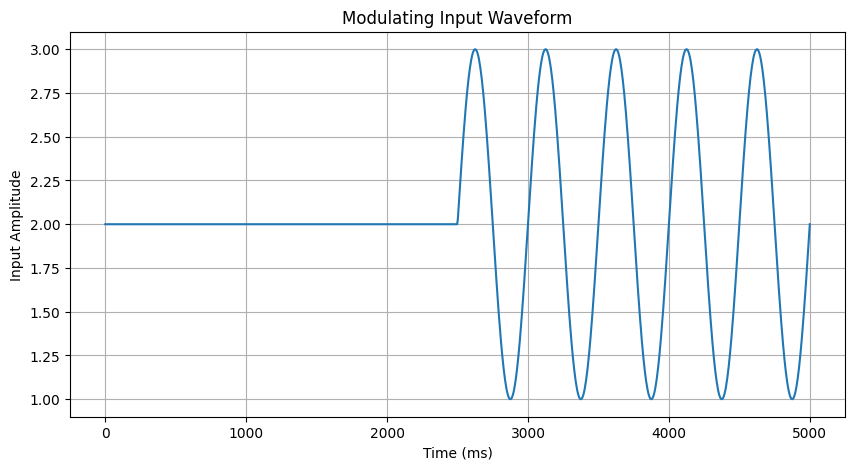

In [3]:
# define modulating afferent input waveform

def modulating_input(t, A=5, period=500, offset=0, t0=0, tf=5000):
    """
    Generate an oscillatory input waveform that is active between t0 and tf.

    Parameters:
    - A: Amplitude of the oscillation.
    - period: Period of the oscillation (in ms).
    - t0: Start time of the oscillation (in ms).
    - tf: End time of the oscillation (in ms).

    Returns:
    - The waveform value(s) at time t.
    """
    H = lambda x: np.heaviside(x, 1)  # Heaviside step function
    waveform = (A * np.sin(1/period * 2 * np.pi * t)) * H(t - t0) * H(tf - t) + offset

    if np.any(waveform < 0):
        raise ValueError("The generated waveform contains negative values, which are not allowed for the external drive.")
    
    return waveform

def plot_modulating_input(t, A, period, offset, t0, tf):
    """
    Plot the afferent input waveform.

    Parameters:
    - 
    """
    try:
        modulating_waveform = modulating_input(t, A, period, offset, t0, tf)
        plt.figure(figsize=(10, 5))
        plt.plot(t, modulating_waveform)
        plt.title('Modulating Input Waveform')
        plt.xlabel('Time (ms)')
        plt.ylabel('Input Amplitude')
        plt.grid()
        plt.show()
    except ValueError as e:
        print(f"Error: {e}")

# example plot with A=5, period=500, t0=0, tf=5000
t = np.linspace(0, 5000, 1000)  # Time from 0 to 100 ms
t0 = 2500  # Start time (ms)
tf = 5000 # End time (ms)
A = 1.0  # Amplitude (Hz)
period = 500 # ms
offset = 2.0  # Hz
plot_modulating_input(t, A, period, offset, t0, tf)

In [4]:
# Function to run oscillatory impulse simulations

def run_impulse_simulation_figure(b_val, rate, EL_inh, EL_exc, A=1, period=500, oscillation_onset=2000, show_plots=True, seed=12):
    # Reset the scope for each simulation
    start_scope()

    # Set random seed for reproducibility (both NumPy and Brian2)
    np.random.seed(seed)
    brian_seed(seed)

    # define fixed parameters and equations for AdEx network
    DT = 0.1  # time step
    defaultclock.dt = DT * ms
    N1 = 2000  # inhibitory neurons
    N2 = 8000  # excitatory neurons 
    TotTime = 5000  # Simulation duration (ms)
    duration = TotTime * ms
    C = 200 * pF
    gL = 10 * nS
    tauw = 500 * ms
    a = 0.0 * nS
    I = 0. * nA
    Ee = 0 * mV
    Ei = -80 * mV

    # Define afferent impulse parameters
    per = period
    DT_aff = 0.1
    N_afferent = N2

    eqs = """
    dvm/dt=(gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)-GsynE*(vm-Ee)-GsynI*(vm-Ei)+I-w)/C : volt (unless refractory)
    dw/dt=(a*(vm-EL)-w)/tauw : amp
    dGsynI/dt = -GsynI/TsynI : siemens
    dGsynE/dt = -GsynE/TsynE : siemens
    TsynI:second
    TsynE:second
    Vr:volt
    b:amp
    DeltaT:volt
    Vcut:volt
    VT:volt
    EL:volt
    """

    # --- Define neuron populations
    G_inh = NeuronGroup(N1, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')
    G_inh.vm = -60 * mV
    G_inh.w = a * (G_inh.vm - G_inh.EL)
    G_inh.Vr = -65 * mV
    G_inh.GsynI = 0.0 * nS
    G_inh.GsynE = 0.0 * nS
    G_inh.TsynI = 5.0 * ms
    G_inh.TsynE = 5.0 * ms
    G_inh.b = 0 * pA
    G_inh.DeltaT = 0.5 * mV
    G_inh.VT = -50. * mV
    G_inh.Vcut = G_inh.VT + 5 * G_inh.DeltaT
    G_inh.EL = float(EL_inh) * mV

    G_exc = NeuronGroup(N2, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')
    G_exc.vm = -60 * mV
    G_exc.w = a * (G_exc.vm - G_exc.EL)
    G_exc.Vr = -65 * mV
    G_exc.GsynI = 0.0 * nS
    G_exc.GsynE = 0.0 * nS
    G_exc.TsynI = 5.0 * ms
    G_exc.TsynE = 5.0 * ms
    G_exc.b = float(b_val) * pA
    G_exc.DeltaT = 2 * mV
    G_exc.VT = -50. * mV
    G_exc.Vcut = G_exc.VT + 5 * G_exc.DeltaT
    G_exc.EL = float(EL_exc) * mV

    # # External drive
    # P_ed = PoissonGroup(N2, rates=float(rate) * Hz)

    # Network connections
    Qi = 5.0 * nS
    Qe = 1.5 * nS
    Qe_ext = 1.5 * nS
    prbC = 0.05

    S_12 = Synapses(G_inh, G_exc, on_pre='GsynI_post+=Qi'); S_12.connect('i!=j', p=prbC)
    S_11 = Synapses(G_inh, G_inh, on_pre='GsynI_post+=Qi'); S_11.connect('i!=j', p=prbC)
    S_21 = Synapses(G_exc, G_inh, on_pre='GsynE_post+=Qe'); S_21.connect('i!=j', p=prbC)
    S_22 = Synapses(G_exc, G_exc, on_pre='GsynE_post+=Qe'); S_22.connect('i!=j', p=prbC)
    # S_ed_in = Synapses(P_ed, G_inh, on_pre='GsynE_post+=Qe_ext'); S_ed_in.connect(p=prbC)
    # S_ed_ex = Synapses(P_ed, G_exc, on_pre='GsynE_post+=Qe_ext'); S_ed_ex.connect(p=prbC)

    # Oscillatory impulse --------------------------------------------------------------------------------
    time_array_aff = np.arange(0, TotTime, DT_aff)
    onset = oscillation_onset # 2000 ms by default (allows baseline to stabilise)
    afferent_input = modulating_input(time_array_aff, A, per, rate, onset, TotTime) * Hz

    rate_array = TimedArray(afferent_input, dt=DT * ms)
    G_aff = PoissonGroup(N_afferent, rates='rate_array(t)')
    S_aff_ex = Synapses(G_aff, G_exc, on_pre='GsynE_post+=Qe_ext'); S_aff_ex.connect(p=prbC)
    S_aff_in = Synapses(G_aff, G_inh, on_pre='GsynE_post+=Qe_ext'); S_aff_in.connect(p=prbC)

    # Recording tools -----------------------------------------------------------------------------------
    M1G_inh = SpikeMonitor(G_inh)
    FRG_inh = PopulationRateMonitor(G_inh)
    M1G_exc = SpikeMonitor(G_exc)
    FRG_exc = PopulationRateMonitor(G_exc)

    # Run simulation
    run(duration)

    # Bin firing rates -----------------------------------------------------------------------------------
    def bin_array(array, BIN, time_array):
        N0 = int(BIN / (time_array[1] - time_array[0]))
        N1 = int((time_array[-1] - time_array[0]) / BIN)
        return array[:N0 * N1].reshape((N1, N0)).mean(axis=1)
    

    BIN = 5 # ms (changed from 5)
    time_array = np.asarray(FRG_exc.t / ms) # changed from: time_array = np.array(arange(int(TotTime / DT))) * DT

    LfrG_exc = np.array(FRG_exc.rate / Hz)
    TimBinned, popRateG_exc = bin_array(time_array, BIN, time_array), bin_array(LfrG_exc, BIN, time_array)
    LfrG_inh = np.array(FRG_inh.rate / Hz)
    TimBinned, popRateG_inh = bin_array(time_array, BIN, time_array), bin_array(LfrG_inh, BIN, time_array)

    # --- Measure baseline activity ---------------------------------------------------
    
    # start with the firing rate data for the excitatory and inhibitory populations
    exc_rates = popRateG_exc.shape
    inh_rates = popRateG_inh.shape

    # Calculate the baseline firing rates between t=1000 ms and the onset of the impulse (t=oscillation_onset)
    # Return an error if this "baseline period" is less than 500 ms, i.e. if oscillation_onset < 1500 ms
    if oscillation_onset < 1500:
        raise ValueError("Baseline period too short. Ensure oscillation_onset >= 1500 ms.")

    baseline_start = 1000
    baseline_end = oscillation_onset
    baseline_start_idx = int(baseline_start / BIN)
    baseline_end_idx = int(baseline_end / BIN)
    baseline_exc_rates = popRateG_exc[baseline_start_idx:baseline_end_idx]
    baseline_inh_rates = popRateG_inh[baseline_start_idx:baseline_end_idx]
    # Calculate the average firing rates during the baseline period (baseline firing rates)
    average_exc_rate = np.mean(baseline_exc_rates)
    average_inh_rate = np.mean(baseline_inh_rates)
    # Calculate the standard deviations of the firing rates during the baseline period
    std_exc_rate = np.std(baseline_exc_rates)
    std_inh_rate = np.std(baseline_inh_rates)

    # --- Sinusoid fitting helper -------------------------------------------------------------------
    def fit_sinusoid(time_ms, rate_hz, period_ms):
        # Ensure everything is dimensionless
        t = np.asarray(time_ms) * 1.0
        r = np.asarray(rate_hz) * 1.0
        mask = np.isfinite(r)
        t = t[mask]
        r = r[mask]
        omega = 2 * np.pi / period_ms
        X = np.column_stack([np.cos(omega * t), np.sin(omega * t), np.ones_like(t)])
        coeffs, _, _, _ = np.linalg.lstsq(X, r, rcond=None)
        A_cos, A_sin, offset = coeffs
        amp = np.sqrt(A_cos**2 + A_sin**2)
        phase = np.arctan2(-A_sin, A_cos)  # radians
        return amp, phase, offset

    # Exclude transient (initial 3 s)
    transient_cutoff = 3000  # ms (fit based on last two seconds)
    valid_indices = TimBinned >= transient_cutoff
    TimBinned_no_transient = TimBinned[valid_indices]
    popRateG_exc_no_transient = popRateG_exc[valid_indices]
    popRateG_inh_no_transient = popRateG_inh[valid_indices]

    # --- Fit sinusoids to population rates after transient ----------------------
    amp_exc, phase_exc_raw, offset_exc = fit_sinusoid(TimBinned_no_transient, popRateG_exc_no_transient, period)
    amp_inh, phase_inh_raw, offset_inh = fit_sinusoid(TimBinned_no_transient, popRateG_inh_no_transient, period)

    # --- Normalise evoked amplitudes by standard deviation of the baseline firing rates
    # Produces a "signal-to-noise" measure representing the number of standard deviations above baseline noise of the evoked amplitudes

    if std_exc_rate > 0:
        amp_exc_norm = amp_exc / std_exc_rate
    else:
        amp_exc_norm = np.nan
    if std_inh_rate > 0:
        amp_inh_norm = amp_inh / std_inh_rate
    else:
        amp_inh_norm = np.nan

    # --- Fit afferent waveform (for phase reference only) -----------------------
    afferent_binned = bin_array(afferent_input, BIN, time_array)
    afferent_binned_no_transient = np.asarray(afferent_binned[valid_indices]) * 1.0
    amp_aff, phase_aff_raw, offset_aff = fit_sinusoid(TimBinned_no_transient, afferent_binned_no_transient, period)

    # --- Compute relative phases and convert to degrees -------------------------
    phase_exc = np.degrees(np.angle(np.exp(1j * (phase_exc_raw - phase_aff_raw))))  # degrees
    phase_inh = np.degrees(np.angle(np.exp(1j * (phase_inh_raw - phase_aff_raw))))  # degrees

    # --- Construct fitted curves ------------------------------------------------
    omega = 2 * np.pi / period
    fitted_exc = offset_exc + amp_exc * np.cos(omega * TimBinned_no_transient + phase_exc_raw)
    fitted_inh = offset_inh + amp_inh * np.cos(omega * TimBinned_no_transient + phase_inh_raw)

    # --- Plot results -----------------------------------------------------------
    if show_plots:

        # --- FIRING RATES ---
        plt.figure(figsize=(8, 6))

        # Afferent input (blue dashed, lighter + subtle)
        plt.plot(TimBinned, afferent_binned,
                color='blue', linestyle='--',
                linewidth=2.0, alpha=1.0)
        
        # Firing rates
        plt.plot(TimBinned, popRateG_exc, color='green', linewidth=1.5)
        plt.plot(TimBinned, popRateG_inh, color='red', linewidth=1.5)

        # Fitted sinusoids (lighter + thinner contrast)
        plt.plot(TimBinned_no_transient, fitted_exc,
                color='black', linewidth=2, alpha=0.9)
        plt.plot(TimBinned_no_transient, fitted_inh,
                color='black', linewidth=2, alpha=0.9)
        
        plt.xlabel('Time (ms)', fontsize=20)
        plt.ylabel('Firing rate (Hz)', fontsize=20, labelpad=15)

        plt.tick_params(axis="both", which="major", labelsize=18)
        plt.tick_params(axis="both", which="minor", labelsize=18)

        # plt.grid(True, linestyle="--", color="darkgray", linewidth=1)

        plt.tight_layout()
        plt.subplots_adjust(left=0.12)
        plt.show()

        # --- RASTER (match Vm style) ---
        plt.figure(figsize=(8, 6))

        plt.scatter(M1G_exc.t[::10]/ms, M1G_exc.i[::10],
                    s=2, color='green', alpha=0.6)
        plt.scatter(M1G_inh.t[::10]/ms, M1G_inh.i[::10] + N2,
                    s=2, color='red', alpha=0.6)

        plt.xlabel('Time (ms)', fontsize=20)
        plt.ylabel('Neuron index', fontsize=20, labelpad=15)

        plt.tick_params(axis="both", which="major", labelsize=18)
        plt.tick_params(axis="both", which="minor", labelsize=18)

        # plt.grid(True, linestyle="--", color="darkgray", linewidth=1)
        plt.tight_layout()
        plt.subplots_adjust(left=0.12)
        plt.show()

    # --- Return outputs ---------------------------------------------------------
    return {
        "b_val": b_val,
        "rate": rate,
        "EL_inh": EL_inh,
        "EL_exc": EL_exc,
        "A": A,
        "period": per,
        "amp_exc": amp_exc,
        "phase_exc_deg": phase_exc,
        "offset_exc": offset_exc,
        "amp_inh": amp_inh,
        "phase_inh_deg": phase_inh,
        "offset_inh": offset_inh,
        "amp_exc_norm": amp_exc_norm,
        "amp_inh_norm": amp_inh_norm
    }

WARNING    't' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value array([   0.        ,    5.00500501,   10.01001001, ..., 4989.98998999,
       4994.99499499, 5000.        ], shape=(1000,)). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


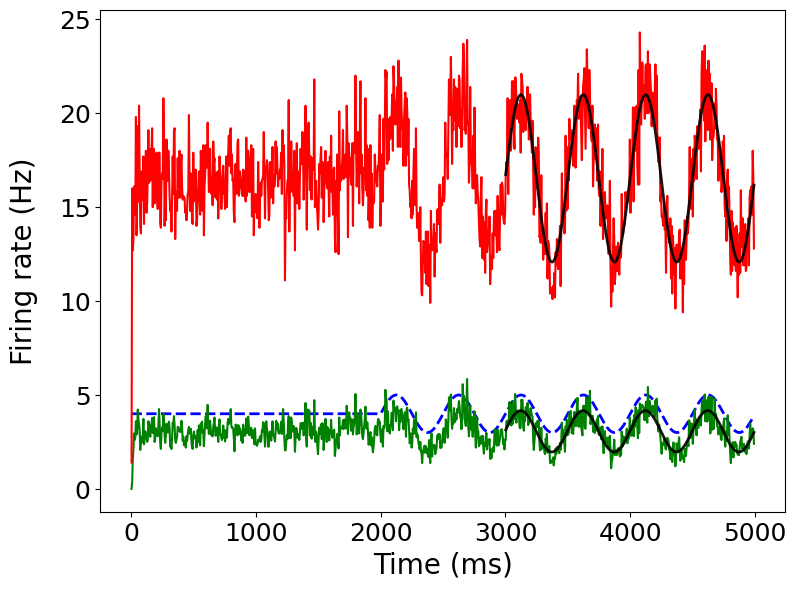

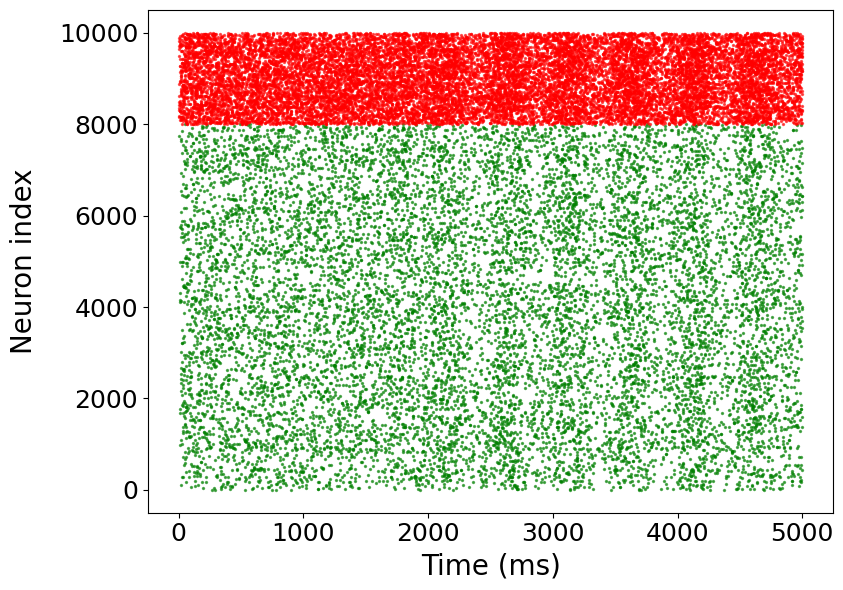

{'b_val': 0,
 'rate': 4,
 'EL_inh': -60,
 'EL_exc': -70,
 'A': 1,
 'period': 500,
 'amp_exc': np.float64(1.0999467399168572),
 'phase_exc_deg': np.float64(2.3627974916507375),
 'offset_exc': np.float64(3.065501536725846),
 'amp_inh': np.float64(4.45424256673369),
 'phase_inh_deg': np.float64(0.7999350695458418),
 'offset_inh': np.float64(16.530123958546486),
 'amp_exc_norm': np.float64(1.9672857454663208),
 'amp_inh_norm': np.float64(2.589583564963157)}

In [9]:
run_impulse_simulation_figure(b_val=0, rate=4, EL_inh=-60, EL_exc=-70, A=1, period=500, oscillation_onset=2000, show_plots=True, seed=12)

## Fig. 2
MF linear stability/SNN frequency-response curves

### Fig. 2a - eigenvalue calculations

Tranfer function

In [11]:
# Di Volo 2019 config (effective threshold)
PRS = [-0.0498, 0.00506, -0.025, 0.0014, -0.00041, 0.0105, -0.036, 0.0074, 0.0012, -0.0407]
PFS = [-0.0514, 0.004, -0.0083, 0.0002, -0.0005, 0.0014, -0.0146, 0.0045, 0.0028, -0.0153]

In [17]:
# Transfer function

from scipy.special import erf

def TF(P,fexc,finh,adapt,EL_val):

    fe = fexc*(1.-gei)*pconnec*Ntot;
    fi = finh*gei*pconnec*Ntot;
    El = EL_val*1.e-3;
    
    muGi = Qi_tf*Ti*fi;
    muGe = Qe_tf*Te*fe;
    muG = Gl+muGe+muGi;
    muV = (muGe*Ee_tf+muGi*Ei_tf+Gl*El-adapt)/muG;
    
    muGn = muG/Gl;
    Tm = Cm/muG;
    
    Ue =  Qe_tf/muG*(Ee_tf-muV);
    Ui = Qi_tf/muG*(Ei_tf-muV);
    
    sV = np.sqrt(fe*(Ue*Te)*(Ue*Te)/2./(Te+Tm)+fi*(Ui*Ti)*(Ui*Ti)/2./(Ti+Tm));
    
    fe= fe+1e-9;
    fi=fi+1e-9;
    Tv = ( fe*(Ue*Te)*(Ue*Te) + fi*(Qi_tf*Ui)*(Qi_tf*Ui)) /( fe*(Ue*Te)*(Ue*Te)/(Te+Tm) + fi*(Qi_tf*Ui)*(Qi_tf*Ui)/(Ti+Tm) );
    TvN = Tv*Gl/Cm;
    
    muV0=-60e-3;
    DmuV0 = 10e-3;
    sV0 =4e-3;
    DsV0= 6e-3;
    TvN0=0.5;
    DTvN0 = 1.;
    vthr=P[0]+P[1]*(muV-muV0)/DmuV0+P[2]*(sV-sV0)/DsV0+P[3]*(TvN-TvN0)/DTvN0+P[4]*((muV-muV0)/DmuV0)*((muV-muV0)/DmuV0)+P[5]*((sV-sV0)/DsV0)*((sV-sV0)/DsV0)+P[6]*((TvN-TvN0)/DTvN0)*((TvN-TvN0)/DTvN0)+P[7]*(muV-muV0)/DmuV0*(sV-sV0)/DsV0+P[8]*(muV-muV0)/DmuV0*(TvN-TvN0)/DTvN0+P[9]*(sV-sV0)/DsV0*(TvN-TvN0)/DTvN0;
    
    frout=.5/TvN*Gl/Cm*(1-erf((vthr-muV)/np.sqrt(2)/sV));
    
    return frout,[muV,sV,Tv];

Gl=10*1.e-9;
Cm=200*1.e-12;

Qe_tf=1.5*1.e-9; # Define so as not to conflict with Qe in the main script
Qi_tf=5.*1.e-9; # Define so as not to conflict with Qi in the main script
Ti=5*1.e-3;
Te=5*1.e-3;
Ee_tf=0; # Define so as not to conflict with Ee in the main script
Ei_tf=-80*1.e-3; # Define so as not to conflict with Ei in the main script
pconnec=0.05;
gei=0.2;
Ntot=10000;
T=0.015

bRS=60*1.e-12;
twRS=.5;

Qee=Qe_tf
Qei=Qe_tf
Qii=Qi_tf
Qie=Qi_tf

In [18]:
# Run mean-field simulation (first order, static T)

def run_mf(PRS, PFS, fe0, fi0, w0, b, ext_drive, EL_exc, EL_inh, twRS=0.5, tfinal=5, dt=0.0001, T=0.010, show_plot=True):

    #############################################################################################################################################
    # Run mean field simulation
    #############################################################################################################################################
    
    t = np.linspace(0, tfinal, int(tfinal/dt))

    # External drive
    external_input= ext_drive

    # Initialise state variables
    fecont = fe0
    ficont = fi0
    w = w0

    bRS = b*1.e-12 # convert from pA to A

    LSw=[]
    LSfe=[]
    LSfi=[]

    for i in range(len(t)):
        
        fecontold=fecont
        fecont+=dt/T*(TF(PRS, fecont+external_input,ficont,w,EL_exc)[0]-fecont)
        w+=dt*( -w/twRS+(bRS)*fecontold)
        ficont+=dt/T*(TF(PFS,fecontold+external_input,ficont,0.,EL_inh)[0]-ficont)

        LSfe.append(float(fecont))
        LSfi.append(float(ficont))
        LSw.append(float(w))

    if show_plot:
        plt.figure(figsize=(10, 5))
        plt.plot(t, LSfe, label='Mean field firing rate (exc)')
        plt.plot(t, LSfi, label='Mean field firing rate (inh)')
        plt.xlabel('Time (s)')
        plt.ylabel('Frequency (Hz)')
        plt.title(f'Mean Field simulation\nb={b} pA, drive rate ={ext_drive} Hz, EL_exc={EL_exc} mV, EL_inh={EL_inh} mV')
        plt.legend()
        plt.show()

    return LSfe, LSfi, LSw

In [19]:
# Run mean-field simulation (first order, dynamic T)

def run_mf_dynamic_T(PRS, PFS, fe0, fi0, w0, b, ext_drive, EL_exc, EL_inh, twRS=0.5, tfinal=5, dt=0.001, T_init=0.010, show_plot=True):

    #############################################################################################################################################
    # Run mean field simulation
    #############################################################################################################################################
    
    t = np.linspace(0, tfinal, int(tfinal/dt))

    # External drive
    external_input= ext_drive

    # Initialise state variables
    fecont = fe0
    ficont = fi0
    w = w0
    T = T_init

    bRS = b*1.e-12 # convert from pA to A

    LSw=[]
    LSfe=[]
    LSfi=[]
    LST=[]

    for i in range(len(t)):
        
        fecontold=fecont
        Fe, [_,_,Tv] = TF(PRS, fecont+external_input,ficont,w,EL_exc)
        Fi = TF(PFS,fecontold+external_input,ficont,0.,EL_inh)[0]
        fecont+=dt/T*(Fe-fecont)
        w+=dt*( -w/twRS+(bRS)*fecontold)
        ficont+=dt/T*(Fi-ficont)

        T = Tv  # Dynamically update T to current Tv

        LSfe.append(float(fecont))
        LSfi.append(float(ficont))
        LSw.append(float(w))
        LST.append(float(T))

    if show_plot:
        plt.figure(figsize=(10, 5))
        plt.plot(t, LSfe, label='Mean field firing rate (exc)')
        plt.plot(t, LSfi, label='Mean field firing rate (inh)')
        plt.xlabel('Time (s)')
        plt.ylabel('Frequency (Hz)')
        plt.title(f'Mean Field simulation\nb={b} pA, drive rate ={ext_drive} Hz, EL_exc={EL_exc} mV, EL_inh={EL_inh} mV')
        plt.legend()
        plt.show()

        # Plot of T values
        plt.figure(figsize=(10, 5))
        plt.plot(t, np.array(LST)*1000)  # Convert T to ms
        plt.xlabel('Time (s)')
        plt.ylabel('T (ms)')
        plt.title('T Values')
        plt.grid()
        plt.show()

    return LSfe, LSfi, LSw, LST

In [20]:
import numpy.linalg as la

def analyze_fixed_point_vectors(fe0, fi0, w0, external_input, EL_exc, EL_inh, T_field,
                                twRS_val, b_pA, PRS, PFS):
    """
    2-D fixed–point analysis: compute 2×2 Jacobian, eigenvalues, eigenvectors,
    and return individual partial derivatives.

    Returns dict with:
        Jacobian, eigenvalues, eigenvectors, periods, frequencies, stability,
        dfedot_dfe, dfedot_dfi, dfidot_dfe, dfidot_dfi.
    """

    bRS = b_pA * 1e-12

    # --- F3D (only use first two components for 2D Jacobian) ---
    def F3D(fe, fi, w, external_input, EL_exc, EL_inh, T, twRS, bRS):
        fe_in = fe + external_input
        fr_e = TF(PRS, fe_in, fi, w, EL_exc)[0]
        fr_i = TF(PFS, fe_in, fi, 0.0, EL_inh)[0]
        fe_dot = (fr_e - fe) / T
        fi_dot = (fr_i - fi) / T
        return np.array([fe_dot, fi_dot], dtype=float)

    # --- Numerical Jacobian for 2-D ---
    def numerical_jacobian_2d(func, fe0, fi0, args=(), eps_rel=1e-6, eps_abs=1e-9):
        x0 = np.array([fe0, fi0], dtype=float)
        steps = np.maximum(eps_abs, eps_rel * np.maximum(1.0, np.abs(x0)))
        J = np.zeros((2,2))
        for j in range(2):
            dx = np.zeros(2)
            dx[j] = steps[j]
            fp = func(*(x0 + dx), *args)
            fm = func(*(x0 - dx), *args)
            J[:, j] = (fp - fm) / (2 * dx[j])
        return J

    # compute 2×2 Jacobian at (fe0, fi0) with w0 held constant
    J = numerical_jacobian_2d(
        lambda fe, fi, ext, ElE, ElI, T, w_const: 
            F3D(fe, fi, w_const, ext, ElE, ElI, T, twRS_val, bRS),
        fe0, fi0,
        args=(external_input, EL_exc, EL_inh, T_field, w0)
    )

    # Extract partial derivatives
    dfedot_dfe = J[0, 0]
    dfedot_dfi = J[0, 1]
    dfidot_dfe = J[1, 0]
    dfidot_dfi = J[1, 1]

    # eigenvalues and eigenvectors
    eig_vals, eig_vecs = la.eig(J)

    periods, frequencies = [], []
    for lam in eig_vals:
        if abs(lam.imag) > 1e-12:
            periods.append(2*np.pi/abs(lam.imag))
            frequencies.append(abs(lam.imag)/(2*np.pi))

    # Stability tag
    def classify(eigs):
        reals = np.real(eigs)
        if np.all(reals < 0): return "all stable (Re<0)"
        if np.any(reals > 0): return "unstable (some Re>0)"
        return "marginal"

    return {
        "Jacobian": J,
        "Eigenvalues": eig_vals,
        "Eigenvectors": eig_vecs,
        "Periods": periods,
        "Frequencies": frequencies,
        "Stability": classify(eig_vals),
        "dfedot_dfe": dfedot_dfe,
        "dfedot_dfi": dfedot_dfi,
        "dfidot_dfe": dfidot_dfe,
        "dfidot_dfi": dfidot_dfi
    }

Eigenvalue calculations and plot for Column 1 ($\nu_\text{drive}=2 \text{ Hz, } b=0 \text{ pA}$)

In [252]:
import pandas as pd

# ---------------------------------------------
# RUN SIMULATIONS AND STORE RESULTS
# ---------------------------------------------

rate_val = 2 # Hz
b_val = 0 # pA


# Extend ΔEL range implicitly via EL_inh
EL_exc = -70
EL_inh_range = np.arange(-85, -54.5, 0.5) # Equivalent to delta_EL range of -15 mV to 15 mV

# Storage structure
eigen_data_r2b0_dense = {
    "EL_inh": [],
    "delta_EL": [],
    "Re_lambda1": [],
    "Im_lambda1": [],
    "Re_lambda2": [],
    "Im_lambda2": [],
    "fe_stationary": [],
    "fi_stationary": [],
    "w_stationary": [],
    "T_stationary": [],
    "dfedot_dfe": [],
    "dfedot_dfi": [],
    "dfidot_dfe": [],
    "dfidot_dfi": [],
    "eigenvector1_real": [],
    "eigenvector1_imag": [],
    "eigenvector2_real": [],
    "eigenvector2_imag": [],
    "eigenfrequency": []
}

print("Running simulations...\n")

for EL_inh in EL_inh_range:

    delta_EL = EL_exc - EL_inh
    print(f"Running simulation for EL_inh = {EL_inh} mV  (ΔEL = {delta_EL})")

    # Run mean-field simulation
    results = run_mf_dynamic_T(
        PRS, PFS, 5, 10, 600e-12, b_val, rate_val, EL_exc, EL_inh,
        twRS=0.5, tfinal=5, dt=0.001, T_init=0.010, show_plot=False
    )

    # Compute stationary values
    fe_stat = np.mean(results[0][-1000:])
    fi_stat = np.mean(results[1][-1000:])
    w_stat  = np.mean(results[2][-1000:])
    T_stat  = np.mean(results[3][-1000:])

    # Compute eigenvalues
    result = analyze_fixed_point_vectors(
        fe_stat, fi_stat, w_stat, rate_val, EL_exc, EL_inh, T_stat, 
        0.5, b_val, PRS, PFS
    )
    
    # Eigenvalues
    eigs = result["Eigenvalues"]

    # Eigenvectors
    eigvecs = result["Eigenvectors"]

    # Partial derivatives
    eigen_data_r2b0_dense["dfedot_dfe"].append(result["dfedot_dfe"])
    eigen_data_r2b0_dense["dfedot_dfi"].append(result["dfedot_dfi"])
    eigen_data_r2b0_dense["dfidot_dfe"].append(result["dfidot_dfe"])
    eigen_data_r2b0_dense["dfidot_dfi"].append(result["dfidot_dfi"])

    # Eigenfrequency
    imag_parts = np.abs(np.imag(eigs))
    idx = np.argmax(imag_parts)

    if imag_parts[idx] > 1e-12:
        omega = np.abs(np.imag(eigs[idx])) / (2 * np.pi)  # Hz
    else:
        omega = 0.0

    # Store data
    eigen_data_r2b0_dense["EL_inh"].append(EL_inh)
    eigen_data_r2b0_dense["delta_EL"].append(delta_EL)
    eigen_data_r2b0_dense["Re_lambda1"].append(eigs[0].real)
    eigen_data_r2b0_dense["Im_lambda1"].append(eigs[0].imag)
    eigen_data_r2b0_dense["Re_lambda2"].append(eigs[1].real)
    eigen_data_r2b0_dense["Im_lambda2"].append(eigs[1].imag)
    eigen_data_r2b0_dense["fe_stationary"].append(fe_stat)
    eigen_data_r2b0_dense["fi_stationary"].append(fi_stat)
    eigen_data_r2b0_dense["w_stationary"].append(w_stat)
    eigen_data_r2b0_dense["T_stationary"].append(T_stat)
    eigen_data_r2b0_dense["eigenvector1_real"].append(eigvecs[:,0].real)
    eigen_data_r2b0_dense["eigenvector1_imag"].append(eigvecs[:,0].imag)
    eigen_data_r2b0_dense["eigenvector2_real"].append(eigvecs[:,1].real)
    eigen_data_r2b0_dense["eigenvector2_imag"].append(eigvecs[:,1].imag)
    eigen_data_r2b0_dense["eigenfrequency"].append(omega)

print("\nFinished simulations.")

# Convert to DataFrame for plotting later
eigen_df_r2b0_dense = pd.DataFrame(eigen_data_r2b0_dense)
eigen_df_r2b0_dense.head()

# Save results to pkl file
with open(f"../data/eigen_df_r2b0_dense.pkl", "wb") as f:
    pickle.dump(eigen_df_r2b0_dense, f)

Running simulations...

Running simulation for EL_inh = -85.0 mV  (ΔEL = 15.0)
Running simulation for EL_inh = -84.5 mV  (ΔEL = 14.5)
Running simulation for EL_inh = -84.0 mV  (ΔEL = 14.0)
Running simulation for EL_inh = -83.5 mV  (ΔEL = 13.5)
Running simulation for EL_inh = -83.0 mV  (ΔEL = 13.0)
Running simulation for EL_inh = -82.5 mV  (ΔEL = 12.5)
Running simulation for EL_inh = -82.0 mV  (ΔEL = 12.0)
Running simulation for EL_inh = -81.5 mV  (ΔEL = 11.5)
Running simulation for EL_inh = -81.0 mV  (ΔEL = 11.0)
Running simulation for EL_inh = -80.5 mV  (ΔEL = 10.5)
Running simulation for EL_inh = -80.0 mV  (ΔEL = 10.0)
Running simulation for EL_inh = -79.5 mV  (ΔEL = 9.5)
Running simulation for EL_inh = -79.0 mV  (ΔEL = 9.0)
Running simulation for EL_inh = -78.5 mV  (ΔEL = 8.5)
Running simulation for EL_inh = -78.0 mV  (ΔEL = 8.0)
Running simulation for EL_inh = -77.5 mV  (ΔEL = 7.5)
Running simulation for EL_inh = -77.0 mV  (ΔEL = 7.0)
Running simulation for EL_inh = -76.5 mV  (ΔEL 

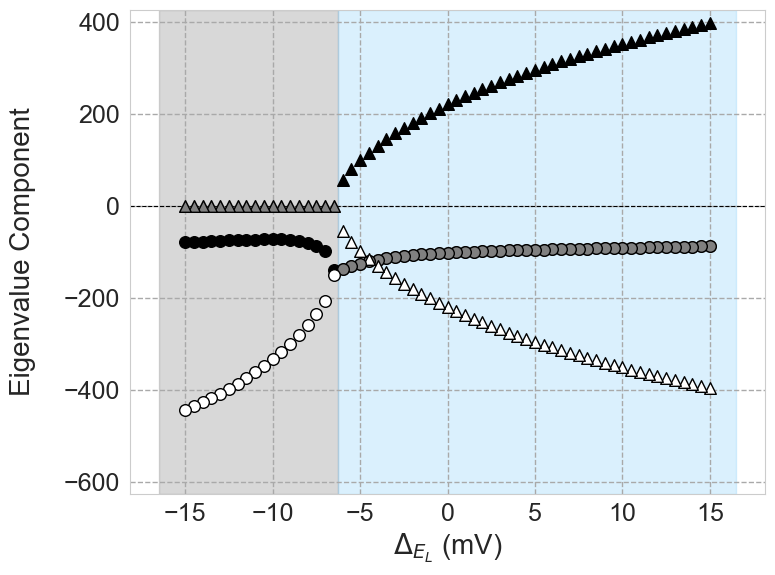

Eigenvalues of Fixed Point for Changing $\Delta_{E_L}$ ($b=0$ pA, $\nu_{drive}=2$ Hz)


In [263]:
import seaborn as sns

# Import eigen_df_r2b0_dense from pkl file
with open(f"../data/eigen_df_r2b0_dense.pkl", "rb") as f:
    eigen_df_r2b0_dense = pickle.load(f)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Colours (now used for background only)
color_real = "gray"           # overdamped
color_complex = "lightskyblue"  # underdamped

# tolerance for equality checks
EQ_TOL = 1e-6

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
})

# ---------------------------------------------------
# Determine overdamped / underdamped boundary
# ---------------------------------------------------
imag_vals = eigen_df_r2b0_dense["Im_lambda1"].values
delta_vals = eigen_df_r2b0_dense["delta_EL"].values

# First index where eigenvalues become complex
idx_switch = next(
    i for i in range(len(imag_vals))
    if abs(imag_vals[i]) == 0
)

# Boundary is halfway between last real and first complex
x_boundary = 0.5 * (delta_vals[idx_switch - 1] + delta_vals[idx_switch])

# Add x_boundary to dataframe as delta_crit
eigen_df_r2b0_dense["delta_crit"] = x_boundary

# Save updated DataFrame with delta_crit to pkl file
with open(f"../data/eigen_df_r2b0_dense.pkl", "wb") as f:
    pickle.dump(eigen_df_r2b0_dense, f)

# ---------------------------------------------------
# Overlay λ1 (filled, unless coincident)
# ---------------------------------------------------
for i in range(len(eigen_df_r2b0_dense)):
    dEL = eigen_df_r2b0_dense["delta_EL"].iloc[i]

    Re1 = eigen_df_r2b0_dense["Re_lambda1"].iloc[i]
    Im1 = eigen_df_r2b0_dense["Im_lambda1"].iloc[i]
    Re2 = eigen_df_r2b0_dense["Re_lambda2"].iloc[i]
    Im2 = eigen_df_r2b0_dense["Im_lambda2"].iloc[i]

    coincident_real = abs(Re1 - Re2) < EQ_TOL
    coincident_imag = abs(Im1 - Im2) < EQ_TOL

    alpha1_real = 0.2 if coincident_real else 1
    alpha1_imag = 0.2 if coincident_imag else 1

    # Re(λ1)
    ax.scatter(
        dEL, Re1,
        color="gray" if coincident_real else "black",
        marker="o",
        s=70,
        zorder=3
    )

    # Im(λ1)
    ax.scatter(
        dEL, Im1,
        color="gray" if coincident_imag else "black",
        marker="^",
        s=70,
        zorder=3
    )

# ---------------------------------------------------
# Overlay λ2 (hollow, unless coincident)
# ---------------------------------------------------
for i in range(len(eigen_df_r2b0_dense)):
    dEL = eigen_df_r2b0_dense["delta_EL"].iloc[i]

    Re1 = eigen_df_r2b0_dense["Re_lambda1"].iloc[i]
    Im1 = eigen_df_r2b0_dense["Im_lambda1"].iloc[i]
    Re2 = eigen_df_r2b0_dense["Re_lambda2"].iloc[i]
    Im2 = eigen_df_r2b0_dense["Im_lambda2"].iloc[i]

    coincident_real = abs(Re1 - Re2) < EQ_TOL
    coincident_imag = abs(Im1 - Im2) < EQ_TOL

    alpha2_real = 0.2 if coincident_real else 1
    alpha2_imag = 0.2 if coincident_imag else 1

    # Re(λ2)
    ax.scatter(
        dEL, Re2,
        facecolors="gray" if coincident_real else "white",
        edgecolors="black",
        marker="o",
        s=70,
        linewidths=1,
        zorder=3
    )

    # Im(λ2)
    ax.scatter(
        dEL, Im2,
        facecolors="gray" if coincident_imag else "white",
        edgecolors="black",
        marker="^",
        s=70,
        linewidths=1,
        zorder=3
    )

# Boundaries for shaded regions
xmin, xmax = ax.get_xlim()

# Background shading
ax.axvspan(xmin, x_boundary, color=color_real, alpha=0.3, zorder=0)
ax.axvspan(x_boundary, xmax, color=color_complex, alpha=0.3, zorder=0)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel(r'$\Delta_{E_L}$ (mV)', fontsize=20)
ax.set_ylabel("Eigenvalue Component", fontsize=20, labelpad=20)
ax.grid(which="both", linestyle="--", color='darkgray', linewidth=1)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(-625, 425)

plt.tight_layout()
plt.show()

print(r"Eigenvalues of Fixed Point for Changing $\Delta_{E_L}$ ($b=0$ pA, $\nu_{drive}=2$ Hz)")

Eigenvalue calculations and plot for Column 2 ($\nu_\text{drive}=4 \text{ Hz, } b=0 \text{ pA}$)

In [254]:
# ---------------------------------------------
# RUN SIMULATIONS AND STORE RESULTS
# ---------------------------------------------

rate_val = 4 # Hz
b_val = 0 # pA


# Extend ΔEL range implicitly via EL_inh
EL_exc = -70
EL_inh_range = np.arange(-85, -54.5, 0.5) # Equivalent to delta_EL range of -15 mV to 15 mV

# Storage structure
eigen_data_r4b0_dense = {
    "EL_inh": [],
    "delta_EL": [],
    "Re_lambda1": [],
    "Im_lambda1": [],
    "Re_lambda2": [],
    "Im_lambda2": [],
    "fe_stationary": [],
    "fi_stationary": [],
    "w_stationary": [],
    "T_stationary": [],
    "dfedot_dfe": [],
    "dfedot_dfi": [],
    "dfidot_dfe": [],
    "dfidot_dfi": [],
    "eigenvector1_real": [],
    "eigenvector1_imag": [],
    "eigenvector2_real": [],
    "eigenvector2_imag": [],
    "eigenfrequency": []
}

print("Running simulations...\n")

for EL_inh in EL_inh_range:

    delta_EL = EL_exc - EL_inh
    print(f"Running simulation for EL_inh = {EL_inh} mV  (ΔEL = {delta_EL})")

    # Run mean-field simulation
    results = run_mf_dynamic_T(
        PRS, PFS, 5, 10, 600e-12, b_val, rate_val, EL_exc, EL_inh,
        twRS=0.5, tfinal=5, dt=0.001, T_init=0.010, show_plot=False
    )

    # Compute stationary values
    fe_stat = np.mean(results[0][-1000:])
    fi_stat = np.mean(results[1][-1000:])
    w_stat  = np.mean(results[2][-1000:])
    T_stat  = np.mean(results[3][-1000:])

    # Compute eigenvalues
    result = analyze_fixed_point_vectors(
        fe_stat, fi_stat, w_stat, rate_val, EL_exc, EL_inh, T_stat, 
        0.5, b_val, PRS, PFS
    )
    
    # Eigenvalues
    eigs = result["Eigenvalues"]

    # Eigenvectors
    eigvecs = result["Eigenvectors"]

    # Partial derivatives
    eigen_data_r4b0_dense["dfedot_dfe"].append(result["dfedot_dfe"])
    eigen_data_r4b0_dense["dfedot_dfi"].append(result["dfedot_dfi"])
    eigen_data_r4b0_dense["dfidot_dfe"].append(result["dfidot_dfe"])
    eigen_data_r4b0_dense["dfidot_dfi"].append(result["dfidot_dfi"])

    # Eigenfrequency
    imag_parts = np.abs(np.imag(eigs))
    idx = np.argmax(imag_parts)

    if imag_parts[idx] > 1e-12:
        omega = np.abs(np.imag(eigs[idx])) / (2 * np.pi)  # Hz
    else:
        omega = 0.0

    # Store data
    eigen_data_r4b0_dense["EL_inh"].append(EL_inh)
    eigen_data_r4b0_dense["delta_EL"].append(delta_EL)
    eigen_data_r4b0_dense["Re_lambda1"].append(eigs[0].real)
    eigen_data_r4b0_dense["Im_lambda1"].append(eigs[0].imag)
    eigen_data_r4b0_dense["Re_lambda2"].append(eigs[1].real)
    eigen_data_r4b0_dense["Im_lambda2"].append(eigs[1].imag)
    eigen_data_r4b0_dense["fe_stationary"].append(fe_stat)
    eigen_data_r4b0_dense["fi_stationary"].append(fi_stat)
    eigen_data_r4b0_dense["w_stationary"].append(w_stat)
    eigen_data_r4b0_dense["T_stationary"].append(T_stat)
    eigen_data_r4b0_dense["eigenvector1_real"].append(eigvecs[:,0].real)
    eigen_data_r4b0_dense["eigenvector1_imag"].append(eigvecs[:,0].imag)
    eigen_data_r4b0_dense["eigenvector2_real"].append(eigvecs[:,1].real)
    eigen_data_r4b0_dense["eigenvector2_imag"].append(eigvecs[:,1].imag)
    eigen_data_r4b0_dense["eigenfrequency"].append(omega)

print("\nFinished simulations.")

# Convert to DataFrame for plotting later
eigen_df_r4b0_dense = pd.DataFrame(eigen_data_r4b0_dense)
eigen_df_r4b0_dense.head()

# Save results to pkl file
with open(f"../data/eigen_df_r4b0_dense.pkl", "wb") as f:
    pickle.dump(eigen_df_r4b0_dense, f)

Running simulations...

Running simulation for EL_inh = -85.0 mV  (ΔEL = 15.0)
Running simulation for EL_inh = -84.5 mV  (ΔEL = 14.5)
Running simulation for EL_inh = -84.0 mV  (ΔEL = 14.0)
Running simulation for EL_inh = -83.5 mV  (ΔEL = 13.5)
Running simulation for EL_inh = -83.0 mV  (ΔEL = 13.0)
Running simulation for EL_inh = -82.5 mV  (ΔEL = 12.5)
Running simulation for EL_inh = -82.0 mV  (ΔEL = 12.0)
Running simulation for EL_inh = -81.5 mV  (ΔEL = 11.5)
Running simulation for EL_inh = -81.0 mV  (ΔEL = 11.0)
Running simulation for EL_inh = -80.5 mV  (ΔEL = 10.5)
Running simulation for EL_inh = -80.0 mV  (ΔEL = 10.0)
Running simulation for EL_inh = -79.5 mV  (ΔEL = 9.5)
Running simulation for EL_inh = -79.0 mV  (ΔEL = 9.0)
Running simulation for EL_inh = -78.5 mV  (ΔEL = 8.5)
Running simulation for EL_inh = -78.0 mV  (ΔEL = 8.0)
Running simulation for EL_inh = -77.5 mV  (ΔEL = 7.5)
Running simulation for EL_inh = -77.0 mV  (ΔEL = 7.0)
Running simulation for EL_inh = -76.5 mV  (ΔEL 

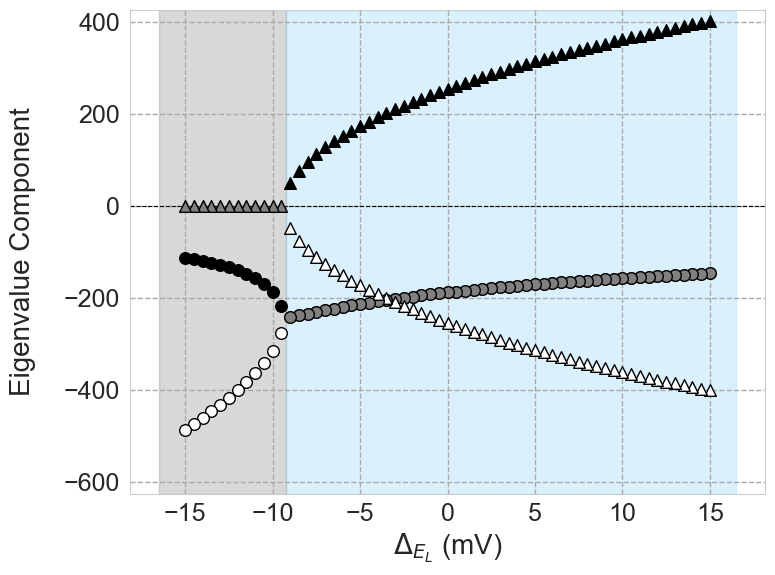

Eigenvalues of Fixed Point for Changing $\Delta_{E_L}$ ($b=0$ pA, $\nu_{drive}=4$ Hz)


In [264]:
# Import eigen_df_r4b0_dense from pkl file
with open(f"../data/eigen_df_r4b0_dense.pkl", "rb") as f:
    eigen_df_r4b0_dense = pickle.load(f)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Colours (now used for background only)
color_real = "gray"           # overdamped
color_complex = "lightskyblue"  # underdamped

# tolerance for equality checks
EQ_TOL = 1e-6

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
})

# ---------------------------------------------------
# Determine overdamped / underdamped boundary
# ---------------------------------------------------
imag_vals = eigen_df_r4b0_dense["Im_lambda1"].values
delta_vals = eigen_df_r4b0_dense["delta_EL"].values

# First index where eigenvalues become complex
idx_switch = next(
    i for i in range(len(imag_vals))
    if abs(imag_vals[i]) == 0
)

# Boundary is halfway between last real and first complex
x_boundary = 0.5 * (delta_vals[idx_switch - 1] + delta_vals[idx_switch])

# Add x_boundary to dataframe as delta_crit
eigen_df_r4b0_dense["delta_crit"] = x_boundary

# Save updated DataFrame with delta_crit to pkl file
with open(f"../data/eigen_df_r4b0_dense.pkl", "wb") as f:
    pickle.dump(eigen_df_r4b0_dense, f)

# ---------------------------------------------------
# Overlay λ1 (filled, unless coincident)
# ---------------------------------------------------
for i in range(len(eigen_df_r4b0_dense)):
    dEL = eigen_df_r4b0_dense["delta_EL"].iloc[i]

    Re1 = eigen_df_r4b0_dense["Re_lambda1"].iloc[i]
    Im1 = eigen_df_r4b0_dense["Im_lambda1"].iloc[i]
    Re2 = eigen_df_r4b0_dense["Re_lambda2"].iloc[i]
    Im2 = eigen_df_r4b0_dense["Im_lambda2"].iloc[i]

    coincident_real = abs(Re1 - Re2) < EQ_TOL
    coincident_imag = abs(Im1 - Im2) < EQ_TOL

    alpha1_real = 0.2 if coincident_real else 1
    alpha1_imag = 0.2 if coincident_imag else 1

    # Re(λ1)
    ax.scatter(
        dEL, Re1,
        color="gray" if coincident_real else "black",
        marker="o",
        s=70,
        zorder=3
    )

    # Im(λ1)
    ax.scatter(
        dEL, Im1,
        color="gray" if coincident_imag else "black",
        marker="^",
        s=70,
        zorder=3
    )

# ---------------------------------------------------
# Overlay λ2 (hollow, unless coincident)
# ---------------------------------------------------
for i in range(len(eigen_df_r4b0_dense)):
    dEL = eigen_df_r4b0_dense["delta_EL"].iloc[i]

    Re1 = eigen_df_r4b0_dense["Re_lambda1"].iloc[i]
    Im1 = eigen_df_r4b0_dense["Im_lambda1"].iloc[i]
    Re2 = eigen_df_r4b0_dense["Re_lambda2"].iloc[i]
    Im2 = eigen_df_r4b0_dense["Im_lambda2"].iloc[i]

    coincident_real = abs(Re1 - Re2) < EQ_TOL
    coincident_imag = abs(Im1 - Im2) < EQ_TOL

    alpha2_real = 0.2 if coincident_real else 1
    alpha2_imag = 0.2 if coincident_imag else 1

    # Re(λ2)
    ax.scatter(
        dEL, Re2,
        facecolors="gray" if coincident_real else "white",
        edgecolors="black",
        marker="o",
        s=70,
        linewidths=1,
        zorder=3
    )

    # Im(λ2)
    ax.scatter(
        dEL, Im2,
        facecolors="gray" if coincident_imag else "white",
        edgecolors="black",
        marker="^",
        s=70,
        linewidths=1,
        zorder=3
    )

# Boundaries for shaded regions
xmin, xmax = ax.get_xlim()

# Background shading
ax.axvspan(xmin, x_boundary, color=color_real, alpha=0.3, zorder=0)
ax.axvspan(x_boundary, xmax, color=color_complex, alpha=0.3, zorder=0)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel(r'$\Delta_{E_L}$ (mV)', fontsize=20)
ax.set_ylabel("Eigenvalue Component", fontsize=20, labelpad=20)
ax.grid(which="both", linestyle="--", color='darkgray', linewidth=1)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(-625, 425)

plt.tight_layout()
plt.show()

print(r"Eigenvalues of Fixed Point for Changing $\Delta_{E_L}$ ($b=0$ pA, $\nu_{drive}=4$ Hz)")

Eigenvalue calculations and plot for Column 3 ($\nu_\text{drive}=4 \text{ Hz, } b=60 \text{ pA}$)

In [256]:
# ---------------------------------------------
# RUN SIMULATIONS AND STORE RESULTS
# ---------------------------------------------

rate_val = 4 # Hz
b_val = 60 # pA


# Extend ΔEL range implicitly via EL_inh
EL_exc = -70
EL_inh_range = np.arange(-85, -54.5, 0.5) # Equivalent to delta_EL range of -15 mV to 15 mV

# Storage structure
eigen_data_r4b60_dense = {
    "EL_inh": [],
    "delta_EL": [],
    "Re_lambda1": [],
    "Im_lambda1": [],
    "Re_lambda2": [],
    "Im_lambda2": [],
    "fe_stationary": [],
    "fi_stationary": [],
    "w_stationary": [],
    "T_stationary": [],
    "dfedot_dfe": [],
    "dfedot_dfi": [],
    "dfidot_dfe": [],
    "dfidot_dfi": [],
    "eigenvector1_real": [],
    "eigenvector1_imag": [],
    "eigenvector2_real": [],
    "eigenvector2_imag": [],
    "eigenfrequency": []
}

print("Running simulations...\n")

for EL_inh in EL_inh_range:

    delta_EL = EL_exc - EL_inh
    print(f"Running simulation for EL_inh = {EL_inh} mV  (ΔEL = {delta_EL})")

    # Run mean-field simulation
    results = run_mf_dynamic_T(
        PRS, PFS, 5, 10, 600e-12, b_val, rate_val, EL_exc, EL_inh,
        twRS=0.5, tfinal=5, dt=0.001, T_init=0.010, show_plot=False
    )

    # Compute stationary values
    fe_stat = np.mean(results[0][-1000:])
    fi_stat = np.mean(results[1][-1000:])
    w_stat  = np.mean(results[2][-1000:])
    T_stat  = np.mean(results[3][-1000:])

    # Compute eigenvalues
    result = analyze_fixed_point_vectors(
        fe_stat, fi_stat, w_stat, rate_val, EL_exc, EL_inh, T_stat, 
        0.5, b_val, PRS, PFS
    )
    
    # Eigenvalues
    eigs = result["Eigenvalues"]

    # Eigenvectors
    eigvecs = result["Eigenvectors"]

    # Partial derivatives
    eigen_data_r4b60_dense["dfedot_dfe"].append(result["dfedot_dfe"])
    eigen_data_r4b60_dense["dfedot_dfi"].append(result["dfedot_dfi"])
    eigen_data_r4b60_dense["dfidot_dfe"].append(result["dfidot_dfe"])
    eigen_data_r4b60_dense["dfidot_dfi"].append(result["dfidot_dfi"])

    # Eigenfrequency
    imag_parts = np.abs(np.imag(eigs))
    idx = np.argmax(imag_parts)

    if imag_parts[idx] > 1e-12:
        omega = np.abs(np.imag(eigs[idx])) / (2 * np.pi)  # Hz
    else:
        omega = 0.0

    # Store data
    eigen_data_r4b60_dense["EL_inh"].append(EL_inh)
    eigen_data_r4b60_dense["delta_EL"].append(delta_EL)
    eigen_data_r4b60_dense["Re_lambda1"].append(eigs[0].real)
    eigen_data_r4b60_dense["Im_lambda1"].append(eigs[0].imag)
    eigen_data_r4b60_dense["Re_lambda2"].append(eigs[1].real)
    eigen_data_r4b60_dense["Im_lambda2"].append(eigs[1].imag)
    eigen_data_r4b60_dense["fe_stationary"].append(fe_stat)
    eigen_data_r4b60_dense["fi_stationary"].append(fi_stat)
    eigen_data_r4b60_dense["w_stationary"].append(w_stat)
    eigen_data_r4b60_dense["T_stationary"].append(T_stat)
    eigen_data_r4b60_dense["eigenvector1_real"].append(eigvecs[:,0].real)
    eigen_data_r4b60_dense["eigenvector1_imag"].append(eigvecs[:,0].imag)
    eigen_data_r4b60_dense["eigenvector2_real"].append(eigvecs[:,1].real)
    eigen_data_r4b60_dense["eigenvector2_imag"].append(eigvecs[:,1].imag)
    eigen_data_r4b60_dense["eigenfrequency"].append(omega)

print("\nFinished simulations.")

# Convert to DataFrame for plotting later
eigen_df_r4b60_dense = pd.DataFrame(eigen_data_r4b60_dense)
eigen_df_r4b60_dense.head()

# Save results to pkl file
with open(f"../data/eigen_df_r4b60_dense.pkl", "wb") as f:
    pickle.dump(eigen_df_r4b60_dense, f)

Running simulations...

Running simulation for EL_inh = -85.0 mV  (ΔEL = 15.0)
Running simulation for EL_inh = -84.5 mV  (ΔEL = 14.5)
Running simulation for EL_inh = -84.0 mV  (ΔEL = 14.0)
Running simulation for EL_inh = -83.5 mV  (ΔEL = 13.5)
Running simulation for EL_inh = -83.0 mV  (ΔEL = 13.0)
Running simulation for EL_inh = -82.5 mV  (ΔEL = 12.5)
Running simulation for EL_inh = -82.0 mV  (ΔEL = 12.0)
Running simulation for EL_inh = -81.5 mV  (ΔEL = 11.5)
Running simulation for EL_inh = -81.0 mV  (ΔEL = 11.0)
Running simulation for EL_inh = -80.5 mV  (ΔEL = 10.5)
Running simulation for EL_inh = -80.0 mV  (ΔEL = 10.0)
Running simulation for EL_inh = -79.5 mV  (ΔEL = 9.5)
Running simulation for EL_inh = -79.0 mV  (ΔEL = 9.0)
Running simulation for EL_inh = -78.5 mV  (ΔEL = 8.5)
Running simulation for EL_inh = -78.0 mV  (ΔEL = 8.0)
Running simulation for EL_inh = -77.5 mV  (ΔEL = 7.5)
Running simulation for EL_inh = -77.0 mV  (ΔEL = 7.0)
Running simulation for EL_inh = -76.5 mV  (ΔEL 

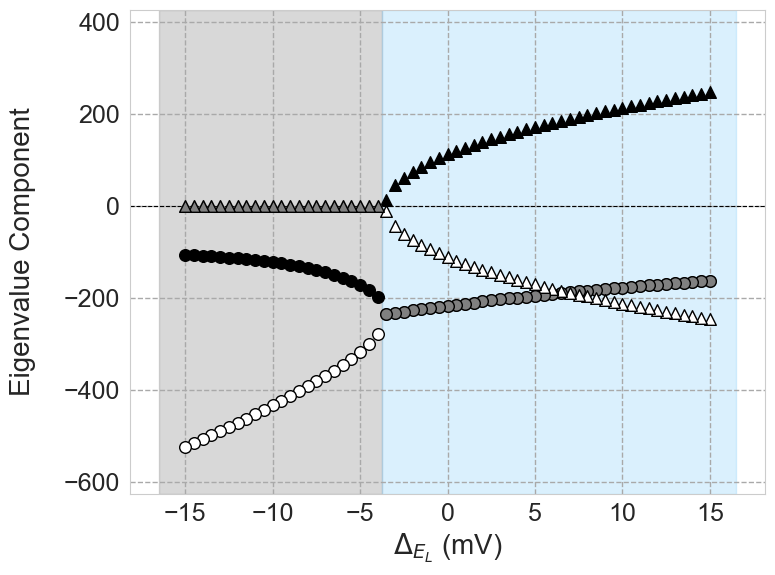

Eigenvalues of Fixed Point for Changing $\Delta_{E_L}$ ($b=60$ pA, $\nu_{drive}=4$ Hz)


In [265]:
# Import eigen_df_r4b60_dense from pkl file
with open(f"../data/eigen_df_r4b60_dense.pkl", "rb") as f:
    eigen_df_r4b60_dense = pickle.load(f)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Colours (now used for background only)
color_real = "gray"           # overdamped
color_complex = "lightskyblue"  # underdamped

# tolerance for equality checks
EQ_TOL = 1e-6

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
})

# ---------------------------------------------------
# Determine overdamped / underdamped boundary
# ---------------------------------------------------
imag_vals = eigen_df_r4b60_dense["Im_lambda1"].values
delta_vals = eigen_df_r4b60_dense["delta_EL"].values

# First index where eigenvalues become complex
idx_switch = next(
    i for i in range(len(imag_vals))
    if abs(imag_vals[i]) == 0
)

# Boundary is halfway between last real and first complex
x_boundary = 0.5 * (delta_vals[idx_switch - 1] + delta_vals[idx_switch])

# Add x_boundary to dataframe as delta_crit
eigen_df_r4b60_dense["delta_crit"] = x_boundary

# Save updated DataFrame with delta_crit to pkl file
with open(f"../data/eigen_df_r4b60_dense.pkl", "wb") as f:
    pickle.dump(eigen_df_r4b60_dense, f)

# ---------------------------------------------------
# Overlay λ1 (filled, unless coincident)
# ---------------------------------------------------
for i in range(len(eigen_df_r4b60_dense)):
    dEL = eigen_df_r4b60_dense["delta_EL"].iloc[i]

    Re1 = eigen_df_r4b60_dense["Re_lambda1"].iloc[i]
    Im1 = eigen_df_r4b60_dense["Im_lambda1"].iloc[i]
    Re2 = eigen_df_r4b60_dense["Re_lambda2"].iloc[i]
    Im2 = eigen_df_r4b60_dense["Im_lambda2"].iloc[i]

    coincident_real = abs(Re1 - Re2) < EQ_TOL
    coincident_imag = abs(Im1 - Im2) < EQ_TOL

    alpha1_real = 0.2 if coincident_real else 1
    alpha1_imag = 0.2 if coincident_imag else 1

    # Re(λ1)
    ax.scatter(
        dEL, Re1,
        color="gray" if coincident_real else "black",
        marker="o",
        s=70,
        zorder=3
    )

    # Im(λ1)
    ax.scatter(
        dEL, Im1,
        color="gray" if coincident_imag else "black",
        marker="^",
        s=70,
        zorder=3
    )

# ---------------------------------------------------
# Overlay λ2 (hollow, unless coincident)
# ---------------------------------------------------
for i in range(len(eigen_df_r4b60_dense)):
    dEL = eigen_df_r4b60_dense["delta_EL"].iloc[i]

    Re1 = eigen_df_r4b60_dense["Re_lambda1"].iloc[i]
    Im1 = eigen_df_r4b60_dense["Im_lambda1"].iloc[i]
    Re2 = eigen_df_r4b60_dense["Re_lambda2"].iloc[i]
    Im2 = eigen_df_r4b60_dense["Im_lambda2"].iloc[i]

    coincident_real = abs(Re1 - Re2) < EQ_TOL
    coincident_imag = abs(Im1 - Im2) < EQ_TOL

    alpha2_real = 0.2 if coincident_real else 1
    alpha2_imag = 0.2 if coincident_imag else 1

    # Re(λ2)
    ax.scatter(
        dEL, Re2,
        facecolors="gray" if coincident_real else "white",
        edgecolors="black",
        marker="o",
        s=70,
        linewidths=1,
        zorder=3
    )

    # Im(λ2)
    ax.scatter(
        dEL, Im2,
        facecolors="gray" if coincident_imag else "white",
        edgecolors="black",
        marker="^",
        s=70,
        linewidths=1,
        zorder=3
    )

# Boundaries for shaded regions
xmin, xmax = ax.get_xlim()

# Background shading
ax.axvspan(xmin, x_boundary, color=color_real, alpha=0.3, zorder=0)
ax.axvspan(x_boundary, xmax, color=color_complex, alpha=0.3, zorder=0)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel(r'$\Delta_{E_L}$ (mV)', fontsize=20)
ax.set_ylabel("Eigenvalue Component", fontsize=20, labelpad=20)
ax.grid(which="both", linestyle="--", color='darkgray', linewidth=1)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(-625, 425)

plt.tight_layout()
plt.show()

print(r"Eigenvalues of Fixed Point for Changing $\Delta_{E_L}$ ($b=60$ pA, $\nu_{drive}=4$ Hz)")

### Fig. 2b - responsiveness simulations

In [258]:
# Function to run oscillatory impulse simulations

def run_impulse_simulation(b_val, rate, EL_inh, EL_exc, A=1, period=500, oscillation_onset=2000, show_plots=True, seed=12):
    # Reset the scope for each simulation
    start_scope()

    # Set random seed for reproducibility (both NumPy and Brian2)
    np.random.seed(seed)
    brian_seed(seed)

    # define fixed parameters and equations for AdEx network
    DT = 0.1  # time step
    defaultclock.dt = DT * ms
    N1 = 2000  # inhibitory neurons
    N2 = 8000  # excitatory neurons 
    TotTime = 5000  # Simulation duration (ms)
    duration = TotTime * ms
    C = 200 * pF
    gL = 10 * nS
    tauw = 500 * ms
    a = 0.0 * nS
    I = 0. * nA
    Ee = 0 * mV
    Ei = -80 * mV

    # Define afferent impulse parameters
    per = period
    DT_aff = 0.1
    N_afferent = N2

    eqs = """
    dvm/dt=(gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)-GsynE*(vm-Ee)-GsynI*(vm-Ei)+I-w)/C : volt (unless refractory)
    dw/dt=(a*(vm-EL)-w)/tauw : amp
    dGsynI/dt = -GsynI/TsynI : siemens
    dGsynE/dt = -GsynE/TsynE : siemens
    TsynI:second
    TsynE:second
    Vr:volt
    b:amp
    DeltaT:volt
    Vcut:volt
    VT:volt
    EL:volt
    """

    # --- Define neuron populations
    G_inh = NeuronGroup(N1, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')
    G_inh.vm = -60 * mV
    G_inh.w = a * (G_inh.vm - G_inh.EL)
    G_inh.Vr = -65 * mV
    G_inh.GsynI = 0.0 * nS
    G_inh.GsynE = 0.0 * nS
    G_inh.TsynI = 5.0 * ms
    G_inh.TsynE = 5.0 * ms
    G_inh.b = 0 * pA
    G_inh.DeltaT = 0.5 * mV
    G_inh.VT = -50. * mV
    G_inh.Vcut = G_inh.VT + 5 * G_inh.DeltaT
    G_inh.EL = float(EL_inh) * mV

    G_exc = NeuronGroup(N2, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')
    G_exc.vm = -60 * mV
    G_exc.w = a * (G_exc.vm - G_exc.EL)
    G_exc.Vr = -65 * mV
    G_exc.GsynI = 0.0 * nS
    G_exc.GsynE = 0.0 * nS
    G_exc.TsynI = 5.0 * ms
    G_exc.TsynE = 5.0 * ms
    G_exc.b = float(b_val) * pA
    G_exc.DeltaT = 2 * mV
    G_exc.VT = -50. * mV
    G_exc.Vcut = G_exc.VT + 5 * G_exc.DeltaT
    G_exc.EL = float(EL_exc) * mV

    # # External drive
    # P_ed = PoissonGroup(N2, rates=float(rate) * Hz)

    # Network connections
    Qi = 5.0 * nS
    Qe = 1.5 * nS
    Qe_ext = 1.5 * nS
    prbC = 0.05

    S_12 = Synapses(G_inh, G_exc, on_pre='GsynI_post+=Qi'); S_12.connect('i!=j', p=prbC)
    S_11 = Synapses(G_inh, G_inh, on_pre='GsynI_post+=Qi'); S_11.connect('i!=j', p=prbC)
    S_21 = Synapses(G_exc, G_inh, on_pre='GsynE_post+=Qe'); S_21.connect('i!=j', p=prbC)
    S_22 = Synapses(G_exc, G_exc, on_pre='GsynE_post+=Qe'); S_22.connect('i!=j', p=prbC)
    # S_ed_in = Synapses(P_ed, G_inh, on_pre='GsynE_post+=Qe_ext'); S_ed_in.connect(p=prbC)
    # S_ed_ex = Synapses(P_ed, G_exc, on_pre='GsynE_post+=Qe_ext'); S_ed_ex.connect(p=prbC)

    # Oscillatory impulse --------------------------------------------------------------------------------
    time_array_aff = np.arange(0, TotTime, DT_aff)
    onset = oscillation_onset # 2000 ms by default (allows baseline to stabilise)
    afferent_input = modulating_input(time_array_aff, A, per, rate, onset, TotTime) * Hz

    rate_array = TimedArray(afferent_input, dt=DT * ms)
    G_aff = PoissonGroup(N_afferent, rates='rate_array(t)')
    S_aff_ex = Synapses(G_aff, G_exc, on_pre='GsynE_post+=Qe_ext'); S_aff_ex.connect(p=prbC)
    S_aff_in = Synapses(G_aff, G_inh, on_pre='GsynE_post+=Qe_ext'); S_aff_in.connect(p=prbC)

    # Recording tools -----------------------------------------------------------------------------------
    M1G_inh = SpikeMonitor(G_inh)
    FRG_inh = PopulationRateMonitor(G_inh)
    M1G_exc = SpikeMonitor(G_exc)
    FRG_exc = PopulationRateMonitor(G_exc)

    # Run simulation
    run(duration)

    # Bin firing rates -----------------------------------------------------------------------------------
    def bin_array(array, BIN, time_array):
        N0 = int(BIN / (time_array[1] - time_array[0]))
        N1 = int((time_array[-1] - time_array[0]) / BIN)
        return array[:N0 * N1].reshape((N1, N0)).mean(axis=1)
    

    BIN = 1 # ms (changed from 5)
    time_array = np.asarray(FRG_exc.t / ms) # changed from: time_array = np.array(arange(int(TotTime / DT))) * DT

    LfrG_exc = np.array(FRG_exc.rate / Hz)
    TimBinned, popRateG_exc = bin_array(time_array, BIN, time_array), bin_array(LfrG_exc, BIN, time_array)
    LfrG_inh = np.array(FRG_inh.rate / Hz)
    TimBinned, popRateG_inh = bin_array(time_array, BIN, time_array), bin_array(LfrG_inh, BIN, time_array)

    # --- Measure baseline activity ---------------------------------------------------
    
    # start with the firing rate data for the excitatory and inhibitory populations
    exc_rates = popRateG_exc.shape
    inh_rates = popRateG_inh.shape

    # Calculate the baseline firing rates between t=1000 ms and the onset of the impulse (t=oscillation_onset)
    # Return an error if this "baseline period" is less than 500 ms, i.e. if oscillation_onset < 1500 ms
    if oscillation_onset < 1500:
        raise ValueError("Baseline period too short. Ensure oscillation_onset >= 1500 ms.")

    baseline_start = 1000
    baseline_end = oscillation_onset
    baseline_start_idx = int(baseline_start / BIN)
    baseline_end_idx = int(baseline_end / BIN)
    baseline_exc_rates = popRateG_exc[baseline_start_idx:baseline_end_idx]
    baseline_inh_rates = popRateG_inh[baseline_start_idx:baseline_end_idx]
    # Calculate the average firing rates during the baseline period (baseline firing rates)
    average_exc_rate = np.mean(baseline_exc_rates)
    average_inh_rate = np.mean(baseline_inh_rates)
    # Calculate the standard deviations of the firing rates during the baseline period
    std_exc_rate = np.std(baseline_exc_rates)
    std_inh_rate = np.std(baseline_inh_rates)

    # --- Sinusoid fitting helper -------------------------------------------------------------------
    def fit_sinusoid(time_ms, rate_hz, period_ms):
        # Ensure everything is dimensionless
        t = np.asarray(time_ms) * 1.0
        r = np.asarray(rate_hz) * 1.0
        mask = np.isfinite(r)
        t = t[mask]
        r = r[mask]
        omega = 2 * np.pi / period_ms
        X = np.column_stack([np.cos(omega * t), np.sin(omega * t), np.ones_like(t)])
        coeffs, _, _, _ = np.linalg.lstsq(X, r, rcond=None)
        A_cos, A_sin, offset = coeffs
        amp = np.sqrt(A_cos**2 + A_sin**2)
        phase = np.arctan2(-A_sin, A_cos)  # radians
        return amp, phase, offset

    # Exclude transient (initial 3 s)
    transient_cutoff = 3000  # ms (fit based on last two seconds)
    valid_indices = TimBinned >= transient_cutoff
    TimBinned_no_transient = TimBinned[valid_indices]
    popRateG_exc_no_transient = popRateG_exc[valid_indices]
    popRateG_inh_no_transient = popRateG_inh[valid_indices]

    # --- Fit sinusoids to population rates after transient ----------------------
    amp_exc, phase_exc_raw, offset_exc = fit_sinusoid(TimBinned_no_transient, popRateG_exc_no_transient, period)
    amp_inh, phase_inh_raw, offset_inh = fit_sinusoid(TimBinned_no_transient, popRateG_inh_no_transient, period)

    # --- Normalise evoked amplitudes by standard deviation of the baseline firing rates
    # Produces a "signal-to-noise" measure representing the number of standard deviations above baseline noise of the evoked amplitudes

    if std_exc_rate > 0:
        amp_exc_norm = amp_exc / std_exc_rate
    else:
        amp_exc_norm = np.nan
    if std_inh_rate > 0:
        amp_inh_norm = amp_inh / std_inh_rate
    else:
        amp_inh_norm = np.nan

    # --- Fit afferent waveform (for phase reference only) -----------------------
    afferent_binned = bin_array(afferent_input, BIN, time_array)
    afferent_binned_no_transient = np.asarray(afferent_binned[valid_indices]) * 1.0
    amp_aff, phase_aff_raw, offset_aff = fit_sinusoid(TimBinned_no_transient, afferent_binned_no_transient, period)

    # --- Compute relative phases and convert to degrees -------------------------
    phase_exc = np.degrees(np.angle(np.exp(1j * (phase_exc_raw - phase_aff_raw))))  # degrees
    phase_inh = np.degrees(np.angle(np.exp(1j * (phase_inh_raw - phase_aff_raw))))  # degrees

    # --- Construct fitted curves ------------------------------------------------
    omega = 2 * np.pi / period
    fitted_exc = offset_exc + amp_exc * np.cos(omega * TimBinned_no_transient + phase_exc_raw)
    fitted_inh = offset_inh + amp_inh * np.cos(omega * TimBinned_no_transient + phase_inh_raw)

    # --- Plot results -----------------------------------------------------------
    if show_plots:
        plt.figure(figsize=(10, 5))
        plt.plot(TimBinned, popRateG_exc, label='Excitatory Rate', color='green')
        plt.plot(TimBinned, popRateG_inh, label='Inhibitory Rate', color='red')
        plt.plot(TimBinned, afferent_binned, label='Afferent Input', color='blue', linestyle='--')

        # Add fitted sinusoids
        plt.plot(TimBinned_no_transient, fitted_exc, color='darkgreen', linestyle='-', linewidth=2,
                 label=f'Exc Fit')
        plt.plot(TimBinned_no_transient, fitted_inh, color='darkred', linestyle='-', linewidth=2,
                 label=f'Inh Fit')

        plt.xlabel('Time (ms)')
        plt.ylabel('Firing Rate (Hz)')
        plt.title('Population Firing Rates with Sinusoidal Fits')

        # Only show last 1000ms for clarity
        # plt.xlim(TotTime - 1000, TotTime)

        plt.legend()
        plt.tight_layout()
        plt.show()

        # Raster plot
        plt.figure(figsize=(10, 5))
        plt.scatter(M1G_exc.t[::10]/ms, M1G_exc.i[::10], s=1, color='green', label='Excitatory Spikes (every 10th)')
        plt.scatter(M1G_inh.t[::10]/ms, M1G_inh.i[::10] + N2, s=1, color='red', label='Inhibitory Spikes (every 10th)')
        plt.xlabel('Time (ms)')
        plt.ylabel('Neuron Index')
        plt.title('Raster Plot')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # --- Return outputs ---------------------------------------------------------
    return {
        "b_val": b_val,
        "rate": rate,
        "EL_inh": EL_inh,
        "EL_exc": EL_exc,
        "A": A,
        "period": per,
        "amp_exc": amp_exc,
        "phase_exc_deg": phase_exc,
        "offset_exc": offset_exc,
        "amp_inh": amp_inh,
        "phase_inh_deg": phase_inh,
        "offset_inh": offset_inh,
        "amp_exc_norm": amp_exc_norm,
        "amp_inh_norm": amp_inh_norm
    }

In [8]:
# Function to run frequency simulations for a particular choice of rate, b, A

import pickle

def run_impulse_sweep(rate_value, b_value, A_value):
    # --- Fixed parameters ---
    init_seed = 12

    # --- Updated parameter ranges ---
    EL_exc_range = [-70]  # fixed EL_exc
    delta_EL_range = [-15, -10, -5, 0, 5, 10, 15]
    frequency_range = [0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30,
                       35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
    period_range = 1000 / np.array(frequency_range)
    num_runs = 10

    # --- Results container ---
    impulse_results = []

    # --- Simulation tracking ---
    total_simulations = len(delta_EL_range) * len(EL_exc_range) * len(period_range) * num_runs
    start_time = time.time()
    completed_sims = 0
    save_interval = 50  # Save after every 50 simulations

    tag = f"r{rate_value}b{b_value}a{A_value}"

    print("======================================")
    print("Starting simulations with parameters:")
    print(f"  EL_exc value: {EL_exc_range}")
    print(f"  delta_EL_range: {delta_EL_range}")
    print(f"  Frequency range (Hz): {frequency_range}")
    print(f"  Period range (ms): {period_range}")
    print(f"  A_value: {A_value}")
    print(f"  Rate value (Hz): {rate_value}")
    print(f"  Runs per combo: {num_runs}")
    print(f"  Total impulse simulations: {total_simulations}")
    print("======================================\n")

    # --- Simulation loops ---
    for EL_exc_value in EL_exc_range:
        for delta_EL_value in delta_EL_range:

            EL_inh_value = EL_exc_value - delta_EL_value

            for per_value in period_range:
                for iteration in range(num_runs):
                    fixed_seed = init_seed + iteration

                    impulse_result = run_impulse_simulation(
                        b_val=b_value,
                        rate=rate_value,
                        EL_inh=EL_inh_value,
                        EL_exc=EL_exc_value,
                        A=A_value,
                        period=per_value,
                        show_plots=False,
                        seed=fixed_seed
                    )

                    impulse_results.append(impulse_result)

                    # --- Progress tracking ---
                    completed_sims += 1
                    elapsed_time = time.time() - start_time
                    avg_time = elapsed_time / completed_sims
                    remaining = total_simulations - completed_sims
                    est_time_remaining = avg_time * remaining

                    print(
                        f"Completed {completed_sims}/{total_simulations} impulse sims | "
                        f"delta_EL={delta_EL_value} mV | A={A_value} | period={per_value:.2f} ms "
                        f"({1000/per_value:.1f} Hz) | run={iteration+1}/{num_runs}"
                    )
                    print(f"  Elapsed: {elapsed_time:.1f}s | Remaining est: {est_time_remaining/60:.1f} min")
                    print("-----")

                    # --- Periodic saving ---
                    if completed_sims % save_interval == 0:
                        with open(f"../data/impulse_results_{tag}_partial.pkl", "wb") as f:
                            pickle.dump(impulse_results, f)
                        print(f"Partial results saved after {completed_sims} simulations.\n")

    # --- Final save ---
    with open(f"../data/impulse_results_{tag}_final.pkl", "wb") as f:
        pickle.dump(impulse_results, f)

    print("======================================")
    print("All simulations completed successfully.")
    print(f"Total elapsed time: {time.time() - start_time:.2f} seconds.")
    print("Final results saved as:")
    print(f"  impulse_results_{tag}_final.pkl")
    print("======================================")

    return impulse_results

In [9]:
def aggregate_impulse_results(impulse_results):
    df = pd.DataFrame(impulse_results)

    # Reconstruct delta_EL
    df["delta_EL"] = df["EL_exc"] - df["EL_inh"]

    # Period (ms) → frequency (Hz)
    df["frequency"] = 1000.0 / df["period"]

    group_cols = ["EL_exc", "delta_EL", "frequency"]

    agg = (
        df
        .groupby(group_cols)
        .agg(
            amp_exc_mean=("amp_exc", "mean"),
            amp_exc_std=("amp_exc", "std"),
            amp_inh_mean=("amp_inh", "mean"),
            amp_inh_std=("amp_inh", "std"),
            phase_exc_deg_mean=("phase_exc_deg", "mean"),
            phase_exc_deg_std=("phase_exc_deg", "std"),
            phase_inh_deg_mean=("phase_inh_deg", "mean"),
            phase_inh_deg_std=("phase_inh_deg", "std"),
            amp_exc_norm_mean=("amp_exc_norm", "mean"),
            amp_exc_norm_std=("amp_exc_norm", "std"),
            amp_inh_norm_mean=("amp_inh_norm", "mean"),
            amp_inh_norm_std=("amp_inh_norm", "std")
        )
        .reset_index()
    )

    return agg

### Run frequency sweep sims for following parameter combinations:
- Input amplitude A=1 Hz, b=0 pA, rate = 2 Hz (Column 1)
- Input amplitude A=1 Hz, b=0 pA, rate = 4 Hz (Column 2)
- Input amplitude A=1 Hz, b=60 pA, rate = 4 Hz (Column 3)

Note: long simulation (~10 hours on mac)

In [ ]:
param_sets = [
    dict(A=1, b=0,  r=2),
    dict(A=1, b=0,  r=4),
    dict(A=1, b=60, r=4),
]

total_jobs = len(param_sets)
job_counter = 0
global_start = time.time()

for p in param_sets:
    job_counter += 1
    job_start = time.time()

    print("======================================")
    print(f"Global job {job_counter}/{total_jobs}")
    print(f"A={p['A']} | b={p['b']} | r={p['r']}")
    print("======================================")

    run_impulse_sweep(
        rate_value=p["r"],
        b_value=p["b"],
        A_value=p["A"]
    )

    print(
        f"Finished job {job_counter}/{total_jobs} | "
        f"Elapsed: {(time.time() - job_start)/60:.1f} min | "
        f"Total elapsed: {(time.time() - global_start)/60:.1f} min"
    )

Plot evoked excitatory response versus input frequency across $\Delta_{E_L}$ values

In [261]:
# Function to plot responsiveness curves

def plot_exc_responses_new(
    data,
    eigenfreqs,
    b_value,
    rate_value,
    A_value,
    xrange=(0.1, 100),
    ymax=3.0,
):
    # Plot exc_responses + eigenfrequency lines

    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    # Unique values
    delta_EL_unique = np.sort(data["delta_EL"].unique())
    EL_exc_unique = np.sort(data["EL_exc"].unique())

    # More strongly differentiated colors
    delta_colors = dict(zip(
        delta_EL_unique,
        sns.color_palette("rocket", n_colors=len(delta_EL_unique))
    ))

    # --- Plot responsiveness curves ---
    for EL_exc in EL_exc_unique:
        for delta_EL in delta_EL_unique:
            subset = data[
                (data["EL_exc"] == EL_exc) &
                (data["delta_EL"] == delta_EL)
            ].sort_values("frequency")

            if subset.empty:
                continue

            freq = subset["frequency"]
            mean = subset["amp_exc_mean"]
            std = subset["amp_exc_std"]

            plt.fill_between(freq, mean - std, mean + std,
                             color=delta_colors[delta_EL],
                             alpha=0.3)

            plt.plot(freq, mean,
                     color=delta_colors[delta_EL],
                     linestyle='-',
                     linewidth=3,
                     label=f"{delta_EL} mV")

    # --- Add eigenfrequency vertical lines ---
    for delta_EL, eigfreq in eigenfreqs.items():
        if eigfreq is None:
            continue
        if delta_EL not in delta_colors:
            continue
        plt.axvline(
            x=eigfreq,
            color=delta_colors[delta_EL],
            linestyle="--",
            linewidth=2.5,
            alpha=0.8
        )

    # Axis settings
    ax = plt.gca()
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(1, 10)*0.1, numticks=10)
    )
    ax.grid(which="both", linestyle="--", linewidth=1)

    ax.set_xlabel(r"$f \text{ (Hz)}$", fontsize=20)
    ax.set_ylabel("Excitatory Amplitude (Hz)", fontsize=20, labelpad=20)
    ax.set_ylim(0, ymax)
    ax.set_xlim(xrange)

    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.tick_params(axis='both', which='minor', labelsize=18)

    plt.tight_layout()
    plt.show()
    print(rf"($b={b_value}$ pA, $\nu_{{drive}}={rate_value}$ Hz, $A={A_value}$ Hz)")

Extract eigenfrequencies and delta_EL_crit values from mean-field linear stability calculations for each parameter set

In [16]:
# Import eigen_df_r2b0_dense, eigen_df_r4b0_dense, eigen_df_r4b60_dense from pkl files
with open(f"../data/eigen_df_r2b0_dense.pkl", "rb") as f:
    eigen_df_r2b0_dense = pickle.load(f)
with open(f"../data/eigen_df_r4b0_dense.pkl", "rb") as f:
    eigen_df_r4b0_dense = pickle.load(f)
with open(f"../data/eigen_df_r4b60_dense.pkl", "rb") as f:
    eigen_df_r4b60_dense = pickle.load(f)

eigenfreqs_r2b0 = {}
for i in range(len(eigen_df_r2b0_dense)):
    delta_EL = eigen_df_r2b0_dense["delta_EL"].iloc[i]
    eigenfrequency = eigen_df_r2b0_dense["eigenfrequency"].iloc[i]
    eigenfreqs_r2b0[delta_EL] = eigenfrequency

delta_EL_crit_r2b0 = eigen_df_r2b0_dense["delta_crit"][0]

eigenfreqs_r4b0 = {}
for i in range(len(eigen_df_r4b0_dense)):
    delta_EL = eigen_df_r4b0_dense["delta_EL"].iloc[i]
    eigenfrequency = eigen_df_r4b0_dense["eigenfrequency"].iloc[i]
    eigenfreqs_r4b0[delta_EL] = eigenfrequency

delta_EL_crit_r4b0 = eigen_df_r4b0_dense["delta_crit"][0]

eigenfreqs_r4b60 = {}
for i in range(len(eigen_df_r4b60_dense)):
    delta_EL = eigen_df_r4b60_dense["delta_EL"].iloc[i]
    eigenfrequency = eigen_df_r4b60_dense["eigenfrequency"].iloc[i]
    eigenfreqs_r4b60[delta_EL] = eigenfrequency

delta_EL_crit_r4b60 = eigen_df_r4b60_dense["delta_crit"][0]

In [267]:
param_sets = [
    dict(A=1, b=0,  r=2,  eigen=eigenfreqs_r2b0,  delta_crit=delta_EL_crit_r2b0),
    dict(A=1, b=0,  r=4,  eigen=eigenfreqs_r4b0,  delta_crit=delta_EL_crit_r4b0),
    dict(A=1, b=60, r=4,  eigen=eigenfreqs_r4b60, delta_crit=delta_EL_crit_r4b60),
]

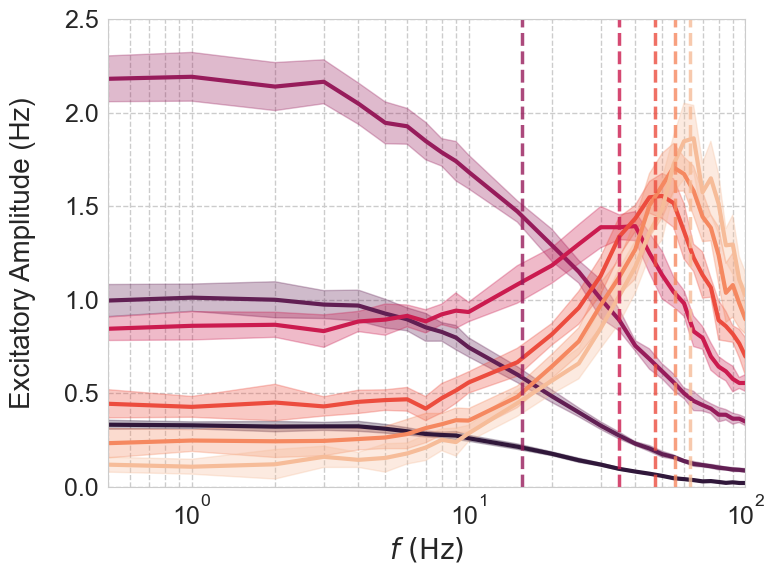

($b=0$ pA, $\nu_{drive}=2$ Hz, $A=1$ Hz)


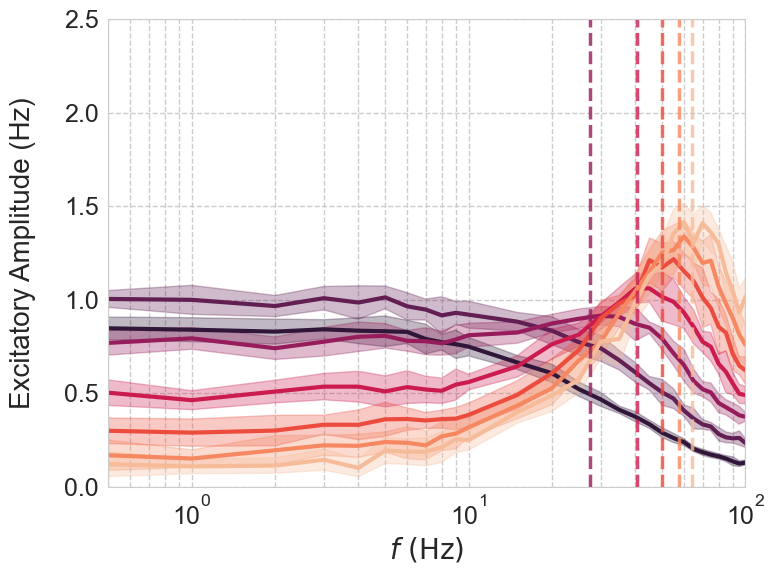

($b=0$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


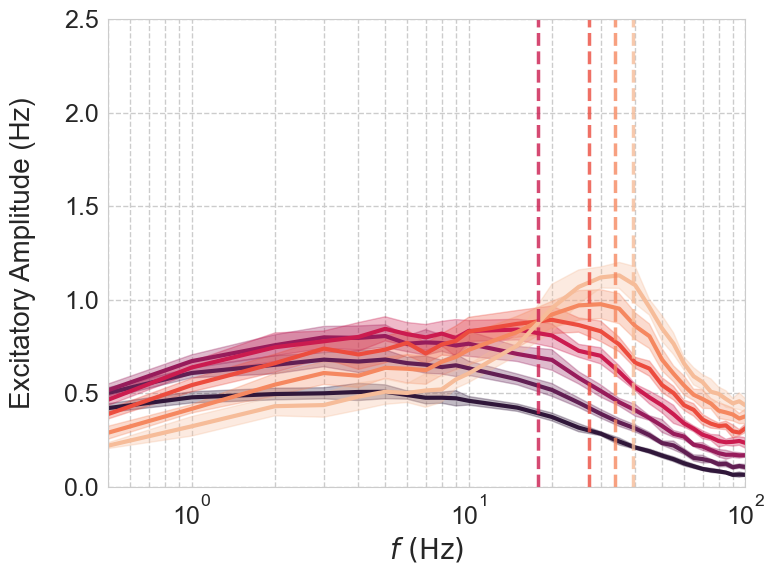

($b=60$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


In [ ]:
for p in param_sets:
    tag = f"r{p['r']}b{p['b']}a{p['A']}"

    with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
        results = pickle.load(f)

    data = aggregate_impulse_results(results)

    plot_exc_responses_new(
        data=data,
        eigenfreqs=p["eigen"],
        b_value=p["b"],
        rate_value=p["r"],
        A_value=p["A"],
        xrange=(0.5, 100),
        ymax=2.5
    )

### Fig. 2c - slow-input responsiveness snapshots

In [130]:
# Function to plot response snapshot to input at particular frequency (default f=0.5 Hz)

def plot_exc_response_snapshot_new(
    data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
):
    # Visualise response to slow input (f=1 Hz)

    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    # Filter for 'freq' Hz
    subset_1hz = data[data["frequency"] == freq]

    # Unique values
    delta_EL_unique = np.sort(data["delta_EL"].unique())

    # Viridis colors
    delta_colors = dict(zip(
        delta_EL_unique,
        sns.color_palette("rocket", n_colors=len(delta_EL_unique))
    ))

    for delta_EL in delta_EL_unique:
        sub = subset_1hz[subset_1hz["delta_EL"] == delta_EL]

        if sub.empty:
            continue

        y = sub["amp_exc_mean"].iloc[0]
        yerr = sub["amp_exc_std"].iloc[0]
        color = delta_colors[delta_EL]

        plt.errorbar(
            delta_EL,
            y,
            yerr=yerr,
            fmt="o",
            color=color,
            markersize=8,
            ecolor=color,
            elinewidth=1.5,
            capsize=8
        )

    # --- Critical value ---
    crit_val = delta_EL_crit

    # Get axis limits
    ax = plt.gca()
    xmin, xmax = ax.get_xlim()

    # --- Shade regions ---

    # Overdamped region (left of critical)
    ax.axvspan(xmin, crit_val, color="gray", alpha=0.3, zorder=0)

    # Underdamped region (right of critical)
    ax.axvspan(crit_val, xmax, color="lightskyblue", alpha=0.3, zorder=0)

    # --- Vertical line at critical ΔEL ---
    plt.axvline(
        x=crit_val,
        color="black",
        linestyle=":",
        linewidth=2.5
    )

    # delta_EL_crit label
    ax.text(
        0.9 * (crit_val - xmin) / (xmax - xmin),
        0.8,
        r"$\Delta_{E_L}^\text{crit.}$",
        ha="center",
        va="top",
        color="black",
        fontsize=18,
        transform=ax.transAxes
    )

    # --- Add region labels ---
    ax.text(
        0.15,
        0.95,
        "OD",
        ha="center",
        va="top",
        fontsize=20,
        fontweight="bold",
        transform=ax.transAxes
    )

    ax.text(
        0.65,
        0.95,
        "UD",
        ha="center",
        va="top",
        fontsize=20,
        fontweight="bold",
        transform=ax.transAxes
    )

    # Labels and title
    ax.grid(which="both", linestyle="--", color='darkgray', linewidth=1)
    ax.set_xlabel(r"$\Delta_{E_L} \text{ (mV)}$", fontsize=20)
    ax.set_ylabel(rf"Excitatory Amplitude ($f={freq} \text{{ Hz}}$)", fontsize=20, labelpad=20)
    ax.set_ylim(0, ymax)
    # ax.set_title(
    #     rf"Excitatory Response at $f={freq}$ Hz vs $\Delta_{{E_L}}$ "
    #     rf"($b={b_value}$ pA, $\nu_{{drive}}={rate_value}$ Hz, $A={A_value}$ Hz)"
    # )

    # Increase tick font size
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.tick_params(axis='both', which='minor', labelsize=18)


    plt.tight_layout()
    plt.show()
    print(rf"($b={b_value}$ pA, $\nu_{{drive}}={rate_value}$ Hz, $A={A_value}$ Hz)")

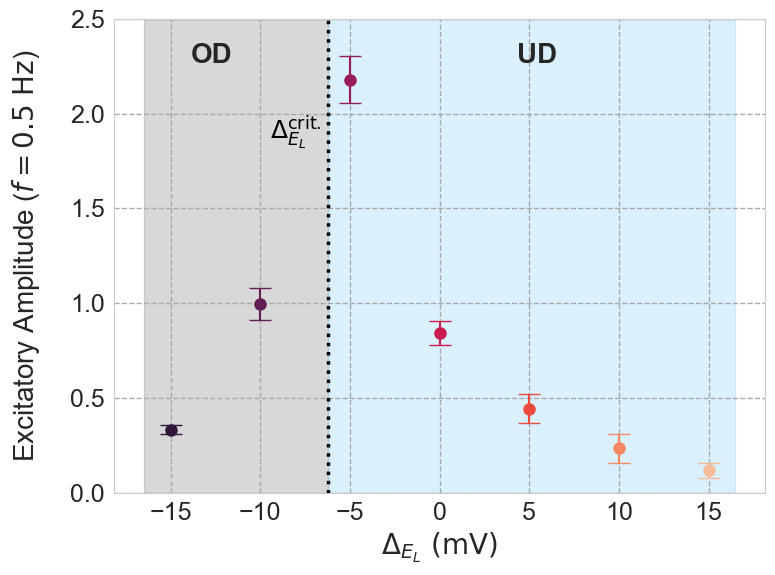

($b=0$ pA, $\nu_{drive}=2$ Hz, $A=1$ Hz)


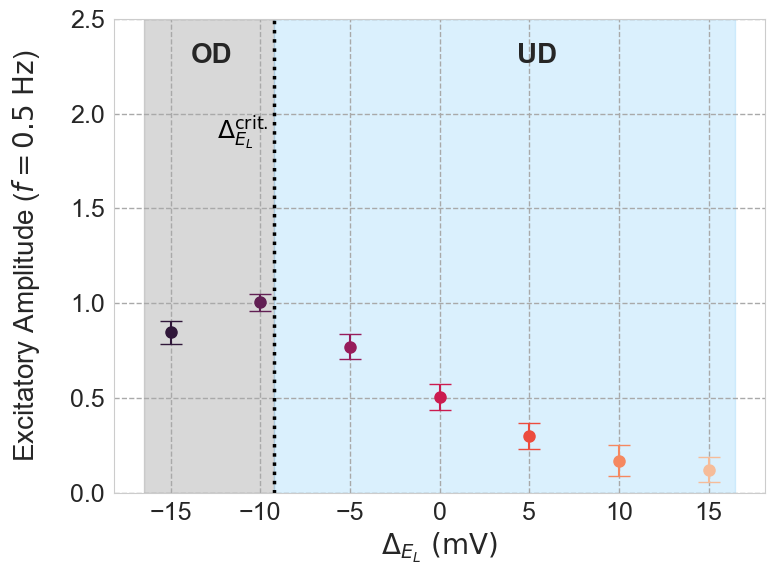

($b=0$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


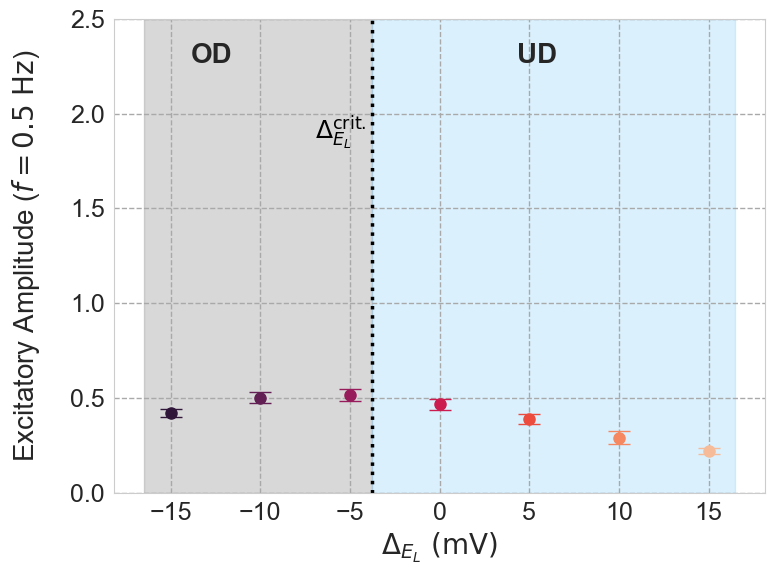

($b=60$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


In [131]:
for p in param_sets:
    tag = f"r{p['r']}b{p['b']}a{p['A']}"

    with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
        results = pickle.load(f)

    data = aggregate_impulse_results(results)

    plot_exc_response_snapshot_new(
        data=data,
        delta_EL_crit=p["delta_crit"],
        b_value=p["b"],
        rate_value=p["r"],
        A_value=p["A"],
        ymax=2.5,
        freq=0.5
    )

## Fig. 3
Response peak heights vs $|\mathrm{Re}\{\lambda\}|$

In [268]:
# Import eigenvalue data from pkl files
with open(f"../data/eigen_df_r2b0_dense.pkl", "rb") as f:
    eigen_data_r2b0_dense = pickle.load(f)
with open(f"../data/eigen_df_r4b0_dense.pkl", "rb") as f:
    eigen_data_r4b0_dense = pickle.load(f)
with open(f"../data/eigen_df_r4b60_dense.pkl", "rb") as f:
    eigen_data_r4b60_dense = pickle.load(f)

# Reconstruct dictionaries from eigenvalue results
real_eigendict_r2b0 = {int(delta_EL): float(re_lambda1) for delta_EL, re_lambda1 in zip(eigen_data_r2b0_dense["delta_EL"], eigen_data_r2b0_dense["Re_lambda1"])}
real_eigendict_r4b0 = {int(delta_EL): float(re_lambda1) for delta_EL, re_lambda1 in zip(eigen_data_r4b0_dense["delta_EL"], eigen_data_r4b0_dense["Re_lambda1"])}
real_eigendict_r4b60 = {int(delta_EL): float(re_lambda1) for delta_EL, re_lambda1 in zip(eigen_data_r4b60_dense["delta_EL"], eigen_data_r4b60_dense["Re_lambda1"])}

In [139]:
# -------------------------------------------------
# Load data and prepare delta_EL colours
# -------------------------------------------------
with open(f"../data/impulse_results_r2b0a1_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)

delta_EL_unique = np.sort(data["delta_EL"].unique())

# Rocket colour scheme
delta_colors = dict(zip(
    delta_EL_unique,
    sns.color_palette("rocket", n_colors=len(delta_EL_unique))
))

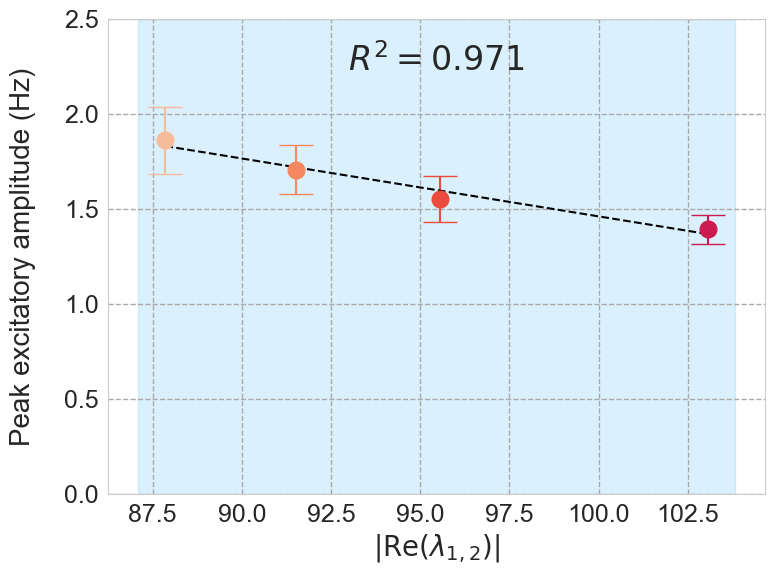

Plot for: r2b0a1


In [142]:
# Plot of peak height vs Re(lambda), coloured by delta_EL

import matplotlib.lines as mlines

real_eigendict = real_eigendict_r2b0

# -----------------------------------------------------------
# Plot: Peak amplitude (y) vs Real eigenvalue Re(lambda) (x)
# -----------------------------------------------------------

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))  # match plotting code 2

tag = "r2b0a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)

data = aggregate_impulse_results(results)

# -----------------------------------------------------------
# Compute peak amplitude and std per delta_EL
# -----------------------------------------------------------
peak_amplitudes = {}
peak_stds = {}

for delta_EL, sub in data.groupby("delta_EL"):
    # Find row where amp_exc_mean is maximal
    idx_max = sub["amp_exc_mean"].idxmax()

    peak_amplitudes[delta_EL] = sub.loc[idx_max, "amp_exc_mean"]
    peak_stds[delta_EL] = sub.loc[idx_max, "amp_exc_std"]

# Build scatter arrays
real_eigs = []
peak_amps = []
peak_errs = []
point_colors = []
legend_handles = []

delta_EL_filt = [0, 5, 10, 15]

for delta_EL in delta_EL_filt:
    if delta_EL not in real_eigendict:
        continue
    if delta_EL not in peak_amplitudes:
        continue

    eig = real_eigendict[delta_EL]
    amp = peak_amplitudes[delta_EL]
    err = peak_stds[delta_EL]
    col = delta_colors[delta_EL]

    real_eigs.append(eig)
    peak_amps.append(amp)
    peak_errs.append(err)
    point_colors.append(col)

    legend_handles.append(
        mlines.Line2D(
            [], [], color=col, marker='o', linestyle='None',
            markersize=8,
            label=f"{delta_EL} mV"
        )
    )

# -----------------------------------------------------------
# Scatter with error bars (formatted to match plotting code 2)
# -----------------------------------------------------------
for x, y, yerr, c in zip(real_eigs, peak_amps, peak_errs, point_colors):
    plt.errorbar(
        abs(x),
        y,
        yerr=yerr,
        fmt="o",
        color=c,
        markersize=12,
        ecolor=c,
        elinewidth=1.5,
        capsize=12
    )

# Fit a linear regression for R²
x_fit = np.abs(real_eigs)

slope, intercept = np.polyfit(x_fit, peak_amps, 1)
predicted = slope * x_fit + intercept
ss_res = np.sum((np.array(peak_amps) - predicted) ** 2)
ss_tot = np.sum((np.array(peak_amps) - np.mean(peak_amps)) ** 2)
r_squared = 1 - ss_res / ss_tot

# Regression line
xvals = np.linspace(min(x_fit), max(x_fit), 200)
plt.plot(
    abs(xvals),
    slope * xvals + intercept,
    linestyle="--",
    color="black",
    linewidth=1.5
)

# Annotate R²
plt.text(
    0.5, 0.95,
    rf"$R^2 = {r_squared:.3f}$",
    transform=plt.gca().transAxes,
    fontsize=24,
    va='top',
    ha='center'
)

# Axis labels
plt.xlabel(r"$|\mathrm{Re}(\lambda_{1,2})|$", fontsize=20)
plt.ylabel("Peak excitatory amplitude (Hz)", fontsize=20, labelpad=20)

# Define xmin and xmax for the background coloring
xmin, xmax = plt.gca().get_xlim()  # Get the full x-axis limits of the plot

# Background colouring (light blue for underdamped)
plt.axvspan(xmin, xmax, color="lightskyblue", alpha=0.3, zorder=0)

# Grid styling
plt.grid(which="both", linestyle="--", color="darkgray", linewidth=1)

# Tick font sizes
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)

# # Legend
# plt.legend(
#     handles=legend_handles,
#     title=r"$\Delta_{E_L}$",
#     fontsize=16,
#     title_fontsize=18,
#     loc="best",
#     frameon=True
# )

plt.ylim(0, 2.5)
plt.tight_layout()
plt.show()

print(f"Plot for: {tag}")

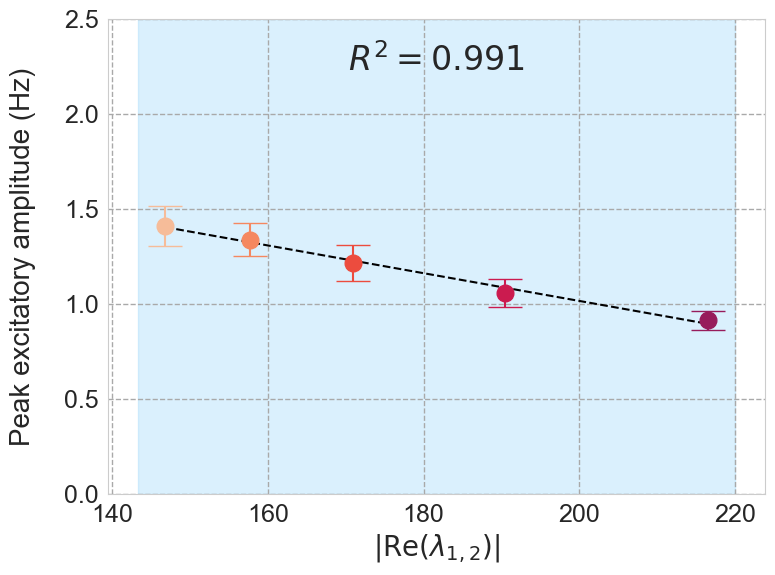

Plot for: r4b0a1


In [141]:
# Plot of peak height vs Re(lambda), coloured by delta_EL

import matplotlib.lines as mlines

real_eigendict = real_eigendict_r4b0

# -----------------------------------------------------------
# Plot: Peak amplitude (y) vs Real eigenvalue Re(lambda) (x)
# -----------------------------------------------------------

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))  # match plotting code 2

tag = "r4b0a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)

data = aggregate_impulse_results(results)

# -----------------------------------------------------------
# Compute peak amplitude and std per delta_EL
# -----------------------------------------------------------
peak_amplitudes = {}
peak_stds = {}

for delta_EL, sub in data.groupby("delta_EL"):
    # Find row where amp_exc_mean is maximal
    idx_max = sub["amp_exc_mean"].idxmax()

    peak_amplitudes[delta_EL] = sub.loc[idx_max, "amp_exc_mean"]
    peak_stds[delta_EL] = sub.loc[idx_max, "amp_exc_std"]

# Build scatter arrays
real_eigs = []
peak_amps = []
peak_errs = []
point_colors = []
legend_handles = []

delta_EL_filt = [-5, 0, 5, 10, 15]

for delta_EL in delta_EL_filt:
    if delta_EL not in real_eigendict:
        continue
    if delta_EL not in peak_amplitudes:
        continue

    eig = real_eigendict[delta_EL]
    amp = peak_amplitudes[delta_EL]
    err = peak_stds[delta_EL]
    col = delta_colors[delta_EL]

    real_eigs.append(eig)
    peak_amps.append(amp)
    peak_errs.append(err)
    point_colors.append(col)

    legend_handles.append(
        mlines.Line2D(
            [], [], color=col, marker='o', linestyle='None',
            markersize=8,
            label=f"{delta_EL} mV"
        )
    )

# -----------------------------------------------------------
# Scatter with error bars (formatted to match plotting code 2)
# -----------------------------------------------------------
for x, y, yerr, c in zip(real_eigs, peak_amps, peak_errs, point_colors):
    plt.errorbar(
        abs(x),
        y,
        yerr=yerr,
        fmt="o",
        color=c,
        markersize=12,
        ecolor=c,
        elinewidth=1.5,
        capsize=12
    )

# Fit a linear regression for R²
x_fit = np.abs(real_eigs)

slope, intercept = np.polyfit(x_fit, peak_amps, 1)
predicted = slope * x_fit + intercept

ss_res = np.sum((np.array(peak_amps) - predicted) ** 2)
ss_tot = np.sum((np.array(peak_amps) - np.mean(peak_amps)) ** 2)
r_squared = 1 - ss_res / ss_tot

# Regression line
xvals = np.linspace(min(x_fit), max(x_fit), 200)
plt.plot(
    abs(xvals),
    slope * xvals + intercept,
    linestyle="--",
    color="black",
    linewidth=1.5
)

# Annotate R²
plt.text(
    0.5, 0.95,
    rf"$R^2 = {r_squared:.3f}$",
    transform=plt.gca().transAxes,
    fontsize=24,
    va='top',
    ha='center'
)

# Axis labels
plt.xlabel(r"$|\mathrm{Re}(\lambda_{1,2})|$", fontsize=20)
plt.ylabel("Peak excitatory amplitude (Hz)", fontsize=20, labelpad=20)

# Define xmin and xmax for the background coloring
xmin, xmax = plt.gca().get_xlim()  # Get the full x-axis limits of the plot

# Background colouring (light blue for underdamped)
plt.axvspan(xmin, xmax, color="lightskyblue", alpha=0.3, zorder=0)

# Grid styling
plt.grid(which="both", linestyle="--", color="darkgray", linewidth=1)

# Tick font sizes
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)

# # Legend
# plt.legend(
#     handles=legend_handles,
#     title=r"$\Delta_{E_L}$",
#     fontsize=16,
#     title_fontsize=18,
#     loc="best",
#     frameon=True
# )

plt.ylim(0, 2.5)
plt.tight_layout()
plt.show()

print(f"Plot for: {tag}")

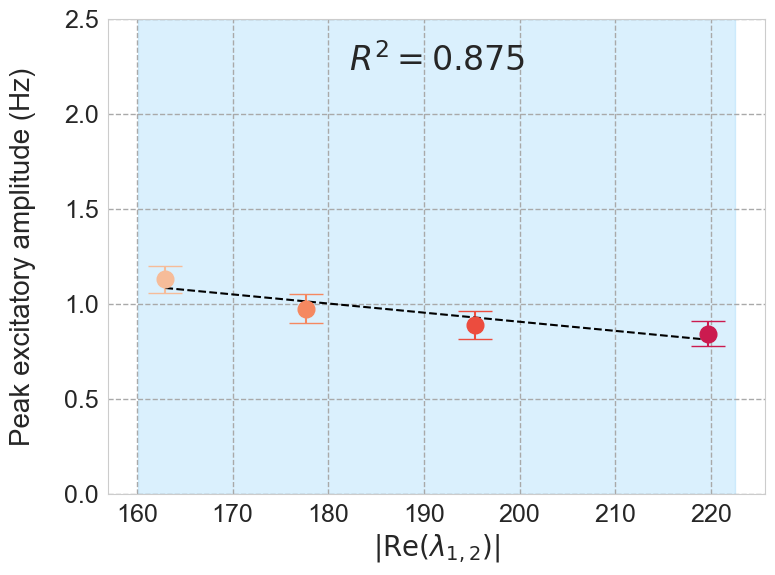

Plot for: r4b60a1


In [143]:
# Plot of peak height vs Re(lambda), coloured by delta_EL

import matplotlib.lines as mlines

real_eigendict = real_eigendict_r4b60

# -----------------------------------------------------------
# Plot: Peak amplitude (y) vs Real eigenvalue Re(lambda) (x)
# -----------------------------------------------------------

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))  # match plotting code 2

tag = "r4b60a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)

data = aggregate_impulse_results(results)

# -----------------------------------------------------------
# Compute peak amplitude and std per delta_EL
# -----------------------------------------------------------
peak_amplitudes = {}
peak_stds = {}

for delta_EL, sub in data.groupby("delta_EL"):
    # Find row where amp_exc_mean is maximal
    idx_max = sub["amp_exc_mean"].idxmax()

    peak_amplitudes[delta_EL] = sub.loc[idx_max, "amp_exc_mean"]
    peak_stds[delta_EL] = sub.loc[idx_max, "amp_exc_std"]

# Build scatter arrays
real_eigs = []
peak_amps = []
peak_errs = []
point_colors = []
legend_handles = []

delta_EL_filt = [0, 5, 10, 15]

for delta_EL in delta_EL_filt:
    if delta_EL not in real_eigendict:
        continue
    if delta_EL not in peak_amplitudes:
        continue

    eig = real_eigendict[delta_EL]
    amp = peak_amplitudes[delta_EL]
    err = peak_stds[delta_EL]
    col = delta_colors[delta_EL]

    real_eigs.append(eig)
    peak_amps.append(amp)
    peak_errs.append(err)
    point_colors.append(col)

    legend_handles.append(
        mlines.Line2D(
            [], [], color=col, marker='o', linestyle='None',
            markersize=8,
            label=f"{delta_EL} mV"
        )
    )

# -----------------------------------------------------------
# Scatter with error bars (formatted to match plotting code 2)
# -----------------------------------------------------------
for x, y, yerr, c in zip(real_eigs, peak_amps, peak_errs, point_colors):
    plt.errorbar(
        abs(x),
        y,
        yerr=yerr,
        fmt="o",
        color=c,
        markersize=12,
        ecolor=c,
        elinewidth=1.5,
        capsize=12
    )

# Fit a linear regression for R²
x_fit = np.abs(real_eigs)

slope, intercept = np.polyfit(x_fit, peak_amps, 1)
predicted = slope * x_fit + intercept

ss_res = np.sum((np.array(peak_amps) - predicted) ** 2)
ss_tot = np.sum((np.array(peak_amps) - np.mean(peak_amps)) ** 2)
r_squared = 1 - ss_res / ss_tot

# Regression line
xvals = np.linspace(min(x_fit), max(x_fit), 200)
plt.plot(
    abs(xvals),
    slope * xvals + intercept,
    linestyle="--",
    color="black",
    linewidth=1.5
)

# Annotate R²
plt.text(
    0.5, 0.95,
    rf"$R^2 = {r_squared:.3f}$",
    transform=plt.gca().transAxes,
    fontsize=24,
    va='top',
    ha='center'
)

# Axis labels
plt.xlabel(r"$|\mathrm{Re}(\lambda_{1,2})|$", fontsize=20)
plt.ylabel("Peak excitatory amplitude (Hz)", fontsize=20, labelpad=20)

# Define xmin and xmax for the background coloring
xmin, xmax = plt.gca().get_xlim()  # Get the full x-axis limits of the plot

# Background colouring (light blue for underdamped)
plt.axvspan(xmin, xmax, color="lightskyblue", alpha=0.3, zorder=0)

# Grid styling
plt.grid(which="both", linestyle="--", color="darkgray", linewidth=1)

# Tick font sizes
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)

# # Legend
# plt.legend(
#     handles=legend_handles,
#     title=r"$\Delta_{E_L}$",
#     fontsize=16,
#     title_fontsize=18,
#     loc="best",
#     frameon=True
# )

plt.ylim(0, 2.5)
plt.tight_layout()
plt.show()

print(f"Plot for: {tag}")

## Fig. 4
Mean-field slow-input response estimate

In [269]:
# Re-import mean-field eigenvalue data from pkl files (to get eigenfrequencies for plotting)

with open(f"../data/eigen_df_r2b0_dense.pkl", "rb") as f:
    eigen_df_r2b0_dense = pickle.load(f)
with open(f"../data/eigen_df_r4b0_dense.pkl", "rb") as f:
    eigen_df_r4b0_dense = pickle.load(f)
with open(f"../data/eigen_df_r4b60_dense.pkl", "rb") as f:
    eigen_df_r4b60_dense = pickle.load(f)

eigenfreqs_r2b0 = {}
for i in range(len(eigen_df_r2b0_dense)):
    delta_EL = eigen_df_r2b0_dense["delta_EL"].iloc[i]
    eigenfrequency = eigen_df_r2b0_dense["eigenfrequency"].iloc[i]
    eigenfreqs_r2b0[delta_EL] = eigenfrequency

delta_EL_crit_r2b0 = eigen_df_r2b0_dense["delta_crit"][0]

eigenfreqs_r4b0 = {}
for i in range(len(eigen_df_r4b0_dense)):
    delta_EL = eigen_df_r4b0_dense["delta_EL"].iloc[i]
    eigenfrequency = eigen_df_r4b0_dense["eigenfrequency"].iloc[i]
    eigenfreqs_r4b0[delta_EL] = eigenfrequency

delta_EL_crit_r4b0 = eigen_df_r4b0_dense["delta_crit"][0]

eigenfreqs_r4b60 = {}
for i in range(len(eigen_df_r4b60_dense)):
    delta_EL = eigen_df_r4b60_dense["delta_EL"].iloc[i]
    eigenfrequency = eigen_df_r4b60_dense["eigenfrequency"].iloc[i]
    eigenfreqs_r4b60[delta_EL] = eigenfrequency

delta_EL_crit_r4b60 = eigen_df_r4b60_dense["delta_crit"][0]

$\nu_\text{drive} = 2 \text{ Hz, } b = 0 \text{ pA}$

In [270]:
param_set = dict(A=1, b=0,  r=2,  eigen=eigenfreqs_r2b0,  delta_crit=delta_EL_crit_r2b0)

tag = f"r{param_set['r']}b{param_set['b']}a{param_set['A']}"

with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)

SNN_data_r2b0 = aggregate_impulse_results(results)

SNN_data_r2b0_filt = SNN_data_r2b0[SNN_data_r2b0["frequency"] == 0.5][["delta_EL", "amp_exc_mean", "amp_exc_std", "amp_inh_mean", "amp_inh_std"]]
print(SNN_data_r2b0_filt)

     delta_EL  amp_exc_mean  amp_exc_std  amp_inh_mean  amp_inh_std
2         -15      0.331338     0.023919      3.310905     0.075844
33        -10      0.995122     0.085648      4.863346     0.192541
64         -5      2.180397     0.122490      7.334957     0.256967
95          0      0.844235     0.062826      3.820301     0.142840
126         5      0.443182     0.075459      2.848020     0.173011
157        10      0.232693     0.078878      2.365681     0.143472
188        15      0.117747     0.040009      2.066181     0.076988


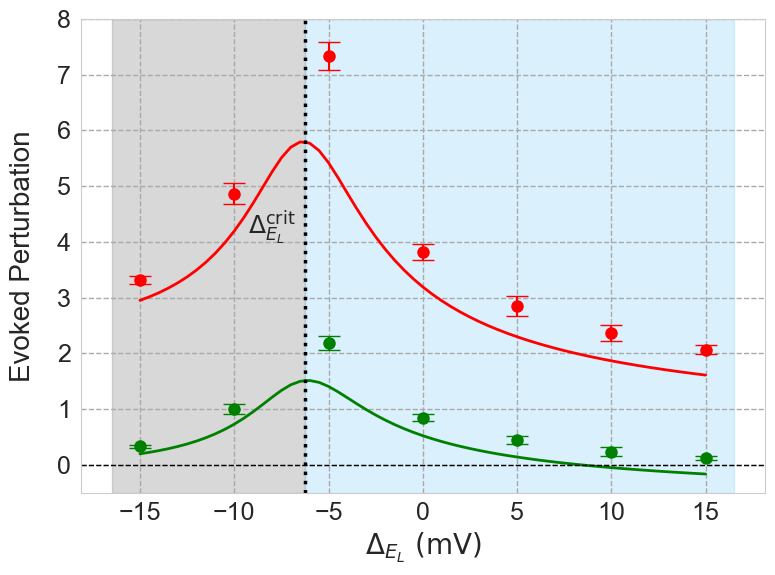

In [163]:
# ---------------------------------------------------
# PARTIAL DERIVATIVE RATIO PLOTS
# ---------------------------------------------------

delta_EL_crit = eigen_df_r2b0_dense["delta_crit"][0]

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# --- Compute quantities ---
delta_EL = eigen_df_r2b0_dense["delta_EL"]

num = (eigen_df_r2b0_dense["dfedot_dfe"]*eigen_df_r2b0_dense["dfidot_dfi"] + eigen_df_r2b0_dense["dfidot_dfi"]/eigen_df_r2b0_dense["T_stationary"] - eigen_df_r2b0_dense["dfedot_dfi"]*eigen_df_r2b0_dense["dfidot_dfe"])
denom = (- eigen_df_r2b0_dense["dfidot_dfe"]/eigen_df_r2b0_dense["T_stationary"])
det = eigen_df_r2b0_dense["dfedot_dfe"]*eigen_df_r2b0_dense["dfidot_dfi"] - eigen_df_r2b0_dense["dfedot_dfi"]*eigen_df_r2b0_dense["dfidot_dfe"]

# --- Plot ---
ax.plot(
    delta_EL,
    -1/det * num,
    "-",
    color="green",
    linewidth=2,
    markersize=8,
    label=r"1/det * chi_exc",
)

ax.plot(
    delta_EL,
    -1/det * denom,
    "-",
    color="red",
    linewidth=2,
    markersize=8,
    label=r"-1/det * chi_inh",
)

# ---------------------------------------------------
# OVERLAY SNN DATA (mean ± std)
# ---------------------------------------------------

delta_EL_SNN = np.arange(-15, 20, 5)

exc_means = np.array(SNN_data_r2b0_filt["amp_exc_mean"])
exc_stds  = np.array(SNN_data_r2b0_filt["amp_exc_std"])

inh_means = np.array(SNN_data_r2b0_filt["amp_inh_mean"])
inh_stds  = np.array(SNN_data_r2b0_filt["amp_inh_std"])

# Colors consistent with theory curves
exc_color = "green"
inh_color = "red"

# Plot excitatory SNN points
ax.errorbar(
    delta_EL_SNN,
    exc_means,
    yerr=exc_stds,
    fmt="o",
    color=exc_color,
    markersize=8,
    ecolor=exc_color,
    elinewidth=1.5,
    capsize=8,
    zorder=5,
)

# Plot inhibitory SNN points
ax.errorbar(
    delta_EL_SNN,
    inh_means,
    yerr=inh_stds,
    fmt="o",
    color=inh_color,
    markersize=8,
    ecolor=inh_color,
    elinewidth=1.5,
    capsize=8,
    zorder=5,
)


# --- Reference lines ---
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(delta_EL_crit, color="black", linestyle=":", linewidth=2.5)

# --- Shade regions ---
xmin, xmax = ax.get_xlim()
ax.axvspan(xmin, delta_EL_crit, color="gray", alpha=0.3, zorder=0)
ax.axvspan(delta_EL_crit, xmax, color="lightskyblue", alpha=0.3, zorder=0)

# --- Grid styling ---
ax.grid(which="both", linestyle="--", color="darkgray", linewidth=1)

# --- Labels ---
ax.set_xlabel(r"$\Delta_{E_L} \text{ (mV)}$", fontsize=20)
ax.set_ylabel("Evoked Perturbation", fontsize=20, labelpad=15)

# --- Legend ---
# ax.legend(fontsize=16, loc="upper left", frameon=True)

# --- Tick sizes ---
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=18)

# --- Critical label ---
xmin, xmax = ax.get_xlim()
ax.text(
    0.85 * (delta_EL_crit - xmin) / (xmax - xmin),
    0.6,
    r"$\Delta_{E_L}^\mathrm{crit}$",
    ha="center",
    va="top",
    fontsize=18,
    transform=ax.transAxes,
)

plt.ylim(-0.5, 8)
plt.tight_layout()
plt.show()

$\nu_\text{drive} = 4 \text{ Hz, } b = 0 \text{ pA}$

In [164]:
param_set = dict(A=1, b=0,  r=4,  eigen=eigenfreqs_r4b0,  delta_crit=delta_EL_crit_r4b0)

tag = f"r{param_set['r']}b{param_set['b']}a{param_set['A']}"

with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)

SNN_data_r4b0 = aggregate_impulse_results(results)

SNN_data_r4b0_filt = SNN_data_r4b0[SNN_data_r4b0["frequency"] == 0.5][["delta_EL", "amp_exc_mean", "amp_exc_std", "amp_inh_mean", "amp_inh_std"]]
print(SNN_data_r4b0_filt)

     delta_EL  amp_exc_mean  amp_exc_std  amp_inh_mean  amp_inh_std
2         -15      0.846654     0.060002      4.035325     0.132095
33        -10      1.003604     0.045156      4.243475     0.113089
64         -5      0.768851     0.065600      3.613458     0.137213
95          0      0.502316     0.068206      2.977966     0.136994
126         5      0.298936     0.068781      2.516703     0.113403
157        10      0.168074     0.081543      2.203611     0.165642
188        15      0.120178     0.066195      2.056405     0.119643


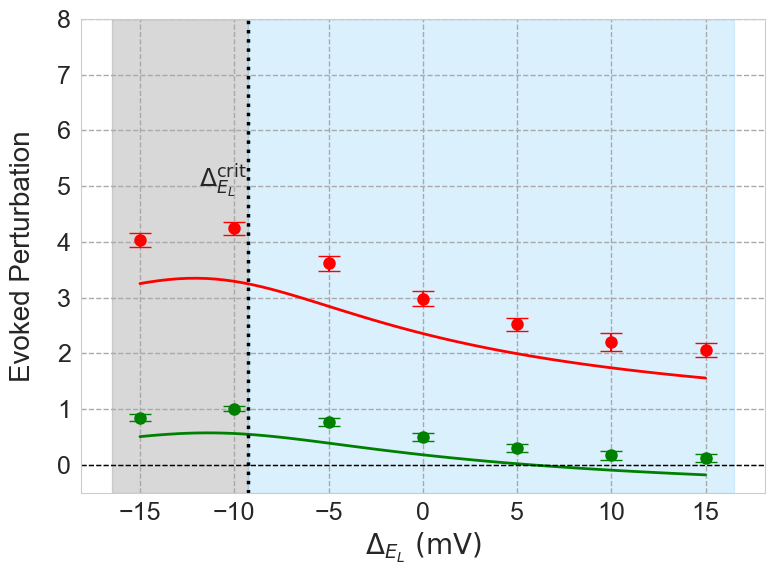

In [168]:
# ---------------------------------------------------
# PARTIAL DERIVATIVE RATIO PLOTS
# ---------------------------------------------------

delta_EL_crit = eigen_df_r4b0_dense["delta_crit"][0]

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# --- Compute quantities ---
delta_EL = eigen_df_r4b0_dense["delta_EL"]

num = (eigen_df_r4b0_dense["dfedot_dfe"]*eigen_df_r4b0_dense["dfidot_dfi"] + eigen_df_r4b0_dense["dfidot_dfi"]/eigen_df_r4b0_dense["T_stationary"] - eigen_df_r4b0_dense["dfedot_dfi"]*eigen_df_r4b0_dense["dfidot_dfe"])
denom = (- eigen_df_r4b0_dense["dfidot_dfe"]/eigen_df_r4b0_dense["T_stationary"])
det = eigen_df_r4b0_dense["dfedot_dfe"]*eigen_df_r4b0_dense["dfidot_dfi"] - eigen_df_r4b0_dense["dfedot_dfi"]*eigen_df_r4b0_dense["dfidot_dfe"]

# --- Plot ---
ax.plot(
    delta_EL,
    -1/det * num,
    "-",
    color="green",
    linewidth=2,
    markersize=8,
    label=r"1/det * chi_exc",
)

ax.plot(
    delta_EL,
    -1/det * denom,
    "-",
    color="red",
    linewidth=2,
    markersize=8,
    label=r"-1/det * chi_inh",
)

# ---------------------------------------------------
# OVERLAY SNN DATA (mean ± std)
# ---------------------------------------------------

delta_EL_SNN = np.arange(-15, 20, 5)

exc_means = np.array(SNN_data_r4b0_filt["amp_exc_mean"])
exc_stds  = np.array(SNN_data_r4b0_filt["amp_exc_std"])

inh_means = np.array(SNN_data_r4b0_filt["amp_inh_mean"])
inh_stds  = np.array(SNN_data_r4b0_filt["amp_inh_std"])

# Colors consistent with theory curves
exc_color = "green"
inh_color = "red"

# Plot excitatory SNN points
ax.errorbar(
    delta_EL_SNN,
    exc_means,
    yerr=exc_stds,
    fmt="o",
    color=exc_color,
    markersize=8,
    ecolor=exc_color,
    elinewidth=1.5,
    capsize=8,
    zorder=5,
)

# Plot inhibitory SNN points
ax.errorbar(
    delta_EL_SNN,
    inh_means,
    yerr=inh_stds,
    fmt="o",
    color=inh_color,
    markersize=8,
    ecolor=inh_color,
    elinewidth=1.5,
    capsize=8,
    zorder=5,
)


# --- Reference lines ---
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(delta_EL_crit, color="black", linestyle=":", linewidth=2.5)

# --- Shade regions ---
xmin, xmax = ax.get_xlim()
ax.axvspan(xmin, delta_EL_crit, color="gray", alpha=0.3, zorder=0)
ax.axvspan(delta_EL_crit, xmax, color="lightskyblue", alpha=0.3, zorder=0)

# --- Grid styling ---
ax.grid(which="both", linestyle="--", color="darkgray", linewidth=1)

# --- Labels ---
ax.set_xlabel(r"$\Delta_{E_L} \text{ (mV)}$", fontsize=20)
ax.set_ylabel("Evoked Perturbation", fontsize=20, labelpad=15)

# --- Legend ---
# ax.legend(fontsize=16, loc="upper left", frameon=True)

# --- Tick sizes ---
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=18)

# --- Critical label ---
xmin, xmax = ax.get_xlim()
ax.text(
    0.85 * (delta_EL_crit - xmin) / (xmax - xmin),
    0.7,
    r"$\Delta_{E_L}^\mathrm{crit}$",
    ha="center",
    va="top",
    fontsize=18,
    transform=ax.transAxes,
)

plt.ylim(-0.5, 8)
plt.tight_layout()
plt.show()

$\nu_\text{drive} = 4 \text{ Hz, } b = 60 \text{ pA}$

In [170]:
param_set = dict(A=1, b=60,  r=4,  eigen=eigenfreqs_r4b60,  delta_crit=delta_EL_crit_r4b60)

tag = f"r{param_set['r']}b{param_set['b']}a{param_set['A']}"

with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)

SNN_data_r4b60 = aggregate_impulse_results(results)

SNN_data_r4b60_filt = SNN_data_r4b60[SNN_data_r4b60["frequency"] == 0.5][["delta_EL", "amp_exc_mean", "amp_exc_std", "amp_inh_mean", "amp_inh_std"]]
print(SNN_data_r4b60_filt)

     delta_EL  amp_exc_mean  amp_exc_std  amp_inh_mean  amp_inh_std
2         -15      0.420333     0.023298      3.147857     0.067443
33        -10      0.501412     0.028246      3.289977     0.071232
64         -5      0.516205     0.032952      3.260492     0.078975
95          0      0.465294     0.030407      3.088329     0.077887
126         5      0.388786     0.026530      2.878153     0.068850
157        10      0.288945     0.034498      2.637465     0.082646
188        15      0.219667     0.015596      2.466138     0.050503


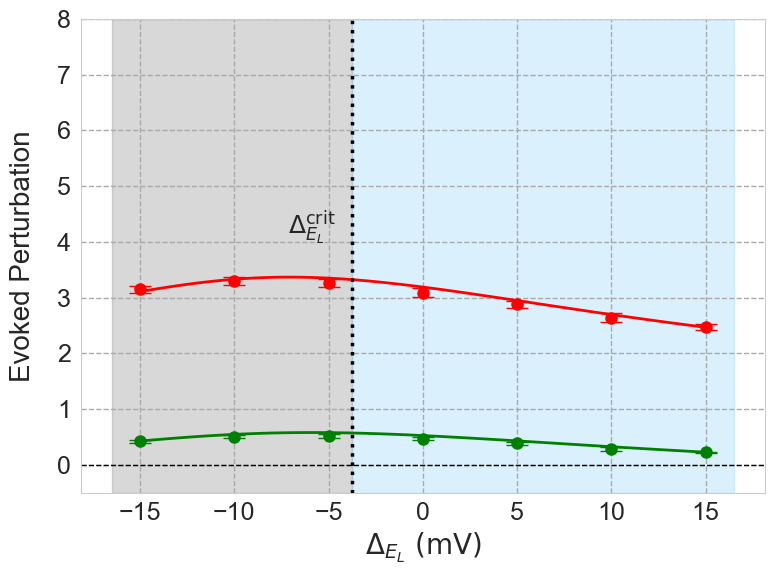

In [171]:
# ---------------------------------------------------
# PARTIAL DERIVATIVE RATIO PLOTS
# ---------------------------------------------------

delta_EL_crit = eigen_df_r4b60_dense["delta_crit"][0]

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# --- Compute quantities ---
delta_EL = eigen_df_r4b60_dense["delta_EL"]

num = (eigen_df_r4b60_dense["dfedot_dfe"]*eigen_df_r4b60_dense["dfidot_dfi"] + eigen_df_r4b60_dense["dfidot_dfi"]/eigen_df_r4b60_dense["T_stationary"] - eigen_df_r4b60_dense["dfedot_dfi"]*eigen_df_r4b60_dense["dfidot_dfe"])
denom = (- eigen_df_r4b60_dense["dfidot_dfe"]/eigen_df_r4b60_dense["T_stationary"])
det = eigen_df_r4b60_dense["dfedot_dfe"]*eigen_df_r4b60_dense["dfidot_dfi"] - eigen_df_r4b60_dense["dfedot_dfi"]*eigen_df_r4b60_dense["dfidot_dfe"]

# --- Plot ---
ax.plot(
    delta_EL,
    -1/det * num,
    "-",
    color="green",
    linewidth=2,
    markersize=8,
    label=r"1/det * chi_exc",
)

ax.plot(
    delta_EL,
    -1/det * denom,
    "-",
    color="red",
    linewidth=2,
    markersize=8,
    label=r"-1/det * chi_inh",
)

# ---------------------------------------------------
# OVERLAY SNN DATA (mean ± std)
# ---------------------------------------------------

delta_EL_SNN = np.arange(-15, 20, 5)

exc_means = np.array(SNN_data_r4b60_filt["amp_exc_mean"])
exc_stds  = np.array(SNN_data_r4b60_filt["amp_exc_std"])

inh_means = np.array(SNN_data_r4b60_filt["amp_inh_mean"])
inh_stds  = np.array(SNN_data_r4b60_filt["amp_inh_std"])

# Colors consistent with theory curves
exc_color = "green"
inh_color = "red"

# Plot excitatory SNN points
ax.errorbar(
    delta_EL_SNN,
    exc_means,
    yerr=exc_stds,
    fmt="o",
    color=exc_color,
    markersize=8,
    ecolor=exc_color,
    elinewidth=1.5,
    capsize=8,
    zorder=5,
)

# Plot inhibitory SNN points
ax.errorbar(
    delta_EL_SNN,
    inh_means,
    yerr=inh_stds,
    fmt="o",
    color=inh_color,
    markersize=8,
    ecolor=inh_color,
    elinewidth=1.5,
    capsize=8,
    zorder=5,
)


# --- Reference lines ---
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(delta_EL_crit, color="black", linestyle=":", linewidth=2.5)

# --- Shade regions ---
xmin, xmax = ax.get_xlim()
ax.axvspan(xmin, delta_EL_crit, color="gray", alpha=0.3, zorder=0)
ax.axvspan(delta_EL_crit, xmax, color="lightskyblue", alpha=0.3, zorder=0)

# --- Grid styling ---
ax.grid(which="both", linestyle="--", color="darkgray", linewidth=1)

# --- Labels ---
ax.set_xlabel(r"$\Delta_{E_L} \text{ (mV)}$", fontsize=20)
ax.set_ylabel("Evoked Perturbation", fontsize=20, labelpad=15)

# --- Legend ---
# ax.legend(fontsize=16, loc="upper left", frameon=True)

# --- Tick sizes ---
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=18)

# --- Critical label ---
xmin, xmax = ax.get_xlim()
ax.text(
    0.85 * (delta_EL_crit - xmin) / (xmax - xmin),
    0.6,
    r"$\Delta_{E_L}^\mathrm{crit}$",
    ha="center",
    va="top",
    fontsize=18,
    transform=ax.transAxes,
)

plt.ylim(-0.5, 8)
plt.tight_layout()
plt.show()

## Fig. 5
Baseline vs evoked I:E ratios

### Functions to run baseline spiking network simulations (i.e. without time-varying input)

In [179]:
# Define helper functions

from random import sample

# Coefficient of variation - measure of regularity of network state -----------------------------

def compute_cv(inh_spike_trains, exc_spike_trains, inh_samples=200, exc_samples=800):

    # Number of neurons to sample from each population
    num_inh_neurons = inh_samples
    num_exc_neurons = exc_samples   

    # Randomly sample inhibitory and excitatory neurons
    sampled_inh_neurons = sample(list(inh_spike_trains.keys()), num_inh_neurons)
    sampled_exc_neurons = sample(list(exc_spike_trains.keys()), num_exc_neurons)

    # Compute ISI CV for sampled inhibitory neurons
    isi_inh_CVs = []

    for neuron in sampled_inh_neurons:
        spike_times_inh = inh_spike_trains[neuron]
        if len(spike_times_inh) > 2:  # CV only defined for >2 spikes
            isi_inh = np.diff(spike_times_inh) / ms  # Convert to milliseconds
            mean_isi_inh = np.mean(isi_inh)
            sd_isi_inh = np.std(isi_inh)
            isi_inh_CVs.append(sd_isi_inh / mean_isi_inh)

    # Remove NaN values
    non_nan_inh_CVs = [cv for cv in isi_inh_CVs if not np.isnan(cv)]

    # Compute ISI CV for sampled excitatory neurons
    isi_exc_CVs = []

    for neuron in sampled_exc_neurons:
        spike_times_exc = exc_spike_trains[neuron]
        if len(spike_times_exc) > 2:  # CV only defined for >2 spikes
            isi_exc = np.diff(spike_times_exc) / ms  # Convert to milliseconds
            mean_isi_exc = np.mean(isi_exc)
            sd_isi_exc = np.std(isi_exc)
            isi_exc_CVs.append(sd_isi_exc / mean_isi_exc)

    # Remove NaN values
    non_nan_exc_CVs = [cv for cv in isi_exc_CVs if not np.isnan(cv)]

    # Combine inhibitory and excitatory CVs
    average_cv = np.mean(non_nan_inh_CVs + non_nan_exc_CVs)

    return average_cv

# Cross-correlation - measure of synchrony of network state -----------------------------------------

def compute_cc(inh_spike_trains, exc_spike_trains):
    # Initialize a list to store valid cross-correlation values
    valid_cross_correlations = []

    # Combine spike trains from both populations
    all_spike_trains = {**inh_spike_trains, **exc_spike_trains}
    neuron_indices = list(all_spike_trains.keys())

    # Perform 1000 random pairwise cross-correlations
    for _ in range(1000):
        # Get two random neurons from the combined population
        neuron1, neuron2 = sample(neuron_indices, 2)
        
        # Retrieve the spike trains for the selected neurons
        spikes1 = all_spike_trains[neuron1]
        spikes2 = all_spike_trains[neuron2]

        # Ensure that both neurons have at least 3 spikes
        if len(spikes1) > 2 and len(spikes2) > 2:
            # Convert spike times to spike count vectors
            max_time = np.max([spikes1[-1], spikes2[-1]]) * second  # set max time based on the latest spike
            bin_width = 5 * ms
            bins = np.arange(0, max_time + bin_width, bin_width)
            
            # Histogram the spike times to get spike counts
            spike_counts1, _ = np.histogram(spikes1, bins=bins)
            spike_counts2, _ = np.histogram(spikes2, bins=bins)
            
            # Ensure that spike count vectors are aligned in length
            if len(spike_counts1) == len(spike_counts2):
                # Calculate covariance and standard deviations
                mean1, mean2 = np.mean(spike_counts1), np.mean(spike_counts2)
                cov = np.mean((spike_counts1 - mean1) * (spike_counts2 - mean2))
                std1, std2 = np.std(spike_counts1), np.std(spike_counts2)
                
                # Avoid division by zero in sparse spike trains
                if std1 > 0 and std2 > 0:
                    correlation = cov / (std1 * std2)
                    valid_cross_correlations.append(correlation)

    # Calculate the average cross-correlation across all valid pairs
    if valid_cross_correlations:
        average_cross_correlation = np.mean(valid_cross_correlations)
    else:
        average_cross_correlation = np.nan

    return average_cross_correlation


In [180]:
def run_baseline_simulation_new(b_val, rate, EL_inh, EL_exc, bin_size, show_plots=True, seed=12):

    # Reset the scope for each simulation
    start_scope()

    # Set random seed for reproducibility (bot numPy and Brian2)
    np.random.seed(seed)
    brian_seed(seed)
    
    # define fixed parameters and equations for AdEx network

    DT=0.1 # time step
    defaultclock.dt = DT*ms
    N1 = 2000 # number of inhibitory neurons
    N2 = 8000 # number of excitatory neurons 
    TotTime=5000 #Simulation duration (ms)
    duration = TotTime*ms
    C = 200*pF
    gL = 10*nS
    tauw = 500*ms # changed from 500
    a = 0.0*nS# 4*nS
    I = 0.*nA
    Ee=0*mV
    Ei=-80*mV

    # # Define afferent impulse parameters
    # A_val = A
    # t0 = 2500 # impose a peak time of 1000ms (ensuring transient has passed)
    # tau1 = tau  # Rise time constant
    # tau2 = tau # Decay time constant
    # TotTime = 5000   # Total simulation time (ms)
    # DT_aff = 0.1       # Time step (ms)
    # N_afferent = N2  # Number of neurons in excitatory population (8000)

    eqs = """
    dvm/dt=(gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)-GsynE*(vm-Ee)-GsynI*(vm-Ei)+I-w)/C : volt (unless refractory)
    dw/dt=(a*(vm-EL)-w)/tauw : amp
    dGsynI/dt = -GsynI/TsynI : siemens
    dGsynE/dt = -GsynE/TsynE : siemens
    TsynI:second
    TsynE:second
    Vr:volt
    b:amp
    DeltaT:volt
    Vcut:volt
    VT:volt
    EL:volt
    """
    
    sim_start = time.time()

    # Population 1 - Fast Spiking
    G_inh = NeuronGroup(N1, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')
    G_inh.vm = -60*mV
    G_inh.w = a * (G_inh.vm - G_inh.EL)
    G_inh.Vr = -65*mV
    G_inh.GsynI = 0.0*nS
    G_inh.GsynE = 0.0*nS
    G_inh.TsynI = 5.0*ms
    G_inh.TsynE = 5.0*ms
    G_inh.b = 0*pA
    G_inh.DeltaT = 0.5*mV
    G_inh.VT = -50.*mV
    G_inh.Vcut = G_inh.VT + 5 * G_inh.DeltaT
    G_inh.EL = float(EL_inh) * mV

    # Population 2 - Regular Spiking
    G_exc = NeuronGroup(N2, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')
    G_exc.vm = -60*mV
    G_exc.w = a * (G_exc.vm - G_exc.EL)
    G_exc.Vr = -65*mV
    G_exc.GsynI = 0.0*nS
    G_exc.GsynE = 0.0*nS
    G_exc.TsynI = 5.0*ms
    G_exc.TsynE = 5.0*ms
    G_exc.b = float(b_val) * pA
    G_exc.DeltaT = 2*mV
    G_exc.VT = -50.*mV
    G_exc.Vcut = G_exc.VT + 5 * G_exc.DeltaT
    G_exc.EL = float(EL_exc) * mV

    # External drive
    P_ed = PoissonGroup(N2, rates= float(rate) * Hz)

    # Network connections
    Qi = 5.0*nS
    Qe = 1.5*nS
    Qe_ext = 1.5*nS
    prbC = 0.05

    S_12 = Synapses(G_inh, G_exc, on_pre='GsynI_post+=Qi')
    S_12.connect('i!=j', p=prbC)

    S_11 = Synapses(G_inh, G_inh, on_pre='GsynI_post+=Qi')
    S_11.connect('i!=j', p=prbC)

    S_21 = Synapses(G_exc, G_inh, on_pre='GsynE_post+=Qe')
    S_21.connect('i!=j', p=prbC)

    S_22 = Synapses(G_exc, G_exc, on_pre='GsynE_post+=Qe')
    S_22.connect('i!=j', p=prbC)

    S_ed_in = Synapses(P_ed, G_inh, on_pre='GsynE_post+=Qe_ext')
    S_ed_in.connect(p=prbC)

    S_ed_ex = Synapses(P_ed, G_exc, on_pre='GsynE_post+=Qe_ext')
    S_ed_ex.connect(p=prbC)

    # Reco ing tools -----------------------------------------------------------------------------------
    
    # --- Record metrics from random subset of 10% of neurons ---
    rec1 = np.random.choice(N1, size=int(0.1 * N1), replace=False)
    rec2 = np.random.choice(N2, size=int(0.1 * N2), replace=False)

    M1G_inh = SpikeMonitor(G_inh)
    FRG_inh = PopulationRateMonitor(G_inh)
    M1G_exc = SpikeMonitor(G_exc)
    FRG_exc = PopulationRateMonitor(G_exc)
    M2G1 = StateMonitor(G_inh, 'vm', record=rec1) # record mean vm of inh neurons
    M3G1 = StateMonitor(G_inh, 'w', record=rec1) # record mean adaptation current of inh neurons
    M4G1 = StateMonitor(G_inh, 'GsynE', record=rec1) # record mean GsynE of inh neurons
    M5G1 = StateMonitor(G_inh, 'GsynI', record=rec1) # record mean GsynI of inh neurons

    M2G2 = StateMonitor(G_exc, 'vm', record=rec2) # record mean vm of exc neurons
    M3G2 = StateMonitor(G_exc, 'w', record=rec2) # record mean adaptation current of exc neurons
    M4G2 = StateMonitor(G_exc, 'GsynE', record=rec2) # record mean GsynE of exc neurons
    M5G2 = StateMonitor(G_exc, 'GsynI', record=rec2) # record mean GsynI of exc neurons

    # Run simulation
    from brian2 import run
    run(duration)

    # prepare firing rate arrays for analysis
    def bin_array(array, BIN, time_array):
        N0 = int(BIN/(time_array[1]-time_array[0]))
        N1 = int((time_array[-1]-time_array[0])/BIN)
        return array[:N0*N1].reshape((N1,N0)).mean(axis=1)

    BIN=bin_size # ms
    time_array = np.array(arange(int(TotTime/DT)))*DT

    LfrG_exc=np.array(FRG_exc.rate/Hz)
    TimBinned,popRateG_exc=bin_array(time_array, BIN, time_array),bin_array(LfrG_exc, BIN, time_array)

    LfrG_inh=np.array(FRG_inh.rate/Hz)
    TimBinned,popRateG_inh=bin_array(time_array, BIN, time_array),bin_array(LfrG_inh, BIN, time_array)

    # extract the firing rate data for the excitatory and inhibitory populations
    exc_rates = popRateG_exc.shape
    inh_rates = popRateG_inh.shape

    # Measure the average population firing rates across the entire simulation (after transient period)
    transient_end = 500  # ms
    transient_end_idx = int(transient_end / BIN)
    average_exc_rate = np.mean(popRateG_exc[transient_end_idx:])
    average_inh_rate = np.mean(popRateG_inh[transient_end_idx:])

    # Measure the standard deviation of the population firing rates across the entire simulation (after transient period)
    std_exc_rate = np.std(popRateG_exc[transient_end_idx:])
    std_inh_rate = np.std(popRateG_inh[transient_end_idx:])

    # Measure the muGe, muGi, g_ratio, tau_eff, muVe, muVi, sVe, sVi, w across this interval **directly** (rather than using transfer function)
    M4G1_trimmed = M4G1.GsynE[:, int(transient_end / DT):]
    M4G2_trimmed = M4G2.GsynE[:, int(transient_end / DT):]
    avg_GsynE_inh = np.mean(M4G1_trimmed) # excitatory conductance in inhibitory neurons
    avg_GsynE_exc = np.mean(M4G2_trimmed) # excitatory conductance in excitatory neurons
    muGe = (avg_GsynE_inh * N1+ avg_GsynE_exc * N2) / (N1 + N2) # weighted average

    var_GsynE_inh = np.mean(np.var(M4G1_trimmed, axis=1))  # mean temporal var in inh neurons
    var_GsynE_exc = np.mean(np.var(M4G2_trimmed, axis=1))  # mean temporal var in exc neurons
    var_muGe = (var_GsynE_inh * N1 + var_GsynE_exc * N2) / (N1 + N2) # weighted network-level mean temporal variance

    M5G1_trimmed = M5G1.GsynI[:, int(transient_end / DT):] 
    M5G2_trimmed = M5G2.GsynI[:, int(transient_end / DT):]
    avg_GsynI_inh = np.mean(M5G1_trimmed) # inhibitory conductance in inhibitory neurons
    avg_GsynI_exc = np.mean(M5G2_trimmed) # inhibitory conductance in excitatory neurons
    muGi = (avg_GsynI_inh * N1 + avg_GsynI_exc * N2) / (N1 + N2) # weighted average

    var_GsynI_inh = np.mean(np.var(M5G1_trimmed, axis=1))  # mean temporal var in inh neurons
    var_GsynI_exc = np.mean(np.var(M5G2_trimmed, axis=1))  # mean temporal var in exc neurons
    var_muGi = (var_GsynI_inh * N1 + var_GsynI_exc * N2) / (N1 + N2) # weighted network-level mean temporal variance

    g_ratio = (muGe + muGi + gL) / gL # total conductance relative to leak
    tau_eff = C / (gL + muGe + muGi) # effective membrane time constant
    e_i_ratio = muGe / muGi    

    M2G1_trimmed = M2G1.vm[:, int(transient_end / DT):]
    M2G2_trimmed = M2G2.vm[:, int(transient_end / DT):]
    muVi = np.mean(M2G1_trimmed) # mean vm of inhibitory neurons
    muVe = np.mean(M2G2_trimmed) # mean vm of excitatory neurons

    sVi = np.std(M2G1_trimmed) # std vm of inhibitory neurons
    sVe = np.std(M2G2_trimmed) # std vm of excitatory neurons

    M3G2_trimmed = M3G2.w[:, int(transient_end / DT):] # adaptation current only for excitatory neurons
    w_stationary = np.mean(M3G2_trimmed) # mean adaptation current in excitatory neurons

    # Trim spike monitors to only include spikes after transient
    M1G_inh_trimmed = {i: t[t >= transient_end*ms] for i, t in M1G_inh.spike_trains().items()}
    M1G_exc_trimmed = {i: t[t >= transient_end*ms] for i, t in M1G_exc.spike_trains().items()}

    # # muV, sV, tauV and predicted firing rates -----------------------------------------------------------------------

    # _, muGe, muGi, g_ratio, muVe, sVe, tVe  = TF_upd(PRS, average_exc_rate + rate, average_inh_rate, w_stationary/amp, EL_exc)

    # _, _, _, _, muVi, sVi, tVi = TF_upd(PFS, average_exc_rate + rate, average_inh_rate, 0., EL_inh)


    # # Determine whether the network is quiescent at any point across the entire simulation (either population) after transient (t>500 ms)
    # # Base this on the *inhibitory* firing rate
    # anywhere_quiescent = is_quiescent(np.array(popRateG_inh[int(500 / BIN):]))


    # Convert BIN to seconds
    bin_duration_seconds = BIN / 1000

    if show_plots:
        # produce a plot of the excitatory (green) and inhibitory (red) firing rates

        plt.figure(figsize=(10, 5))
        plt.plot(TimBinned, popRateG_exc, label='Excitatory Rate', color='green')
        plt.plot(TimBinned, popRateG_inh, label='Inhibitory Rate', color='red')

        plt.axhline(average_exc_rate, color='green', linestyle='--', label='Exc. baseline')
        plt.axhline(average_inh_rate, color='red', linestyle='--', label='Inh. baseline')

        plt.xlabel('Time (ms)')
        plt.ylabel('Firing Rate (Hz)')
        plt.title('Population Firing Rates and Afferent Input')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # produce a raster plot of spikes in excitatory (green) and inhibitory (red) populations
        plt.figure(figsize=(10, 5))
        plt.scatter(M1G_exc.t[::10]/ms, M1G_exc.i[::10], s=1, color='green', label='Excitatory Spikes (every 10th)')
        plt.scatter(M1G_inh.t[::10]/ms, M1G_inh.i[::10] + N2, s=1, color='red', label='Inhibitory Spikes (every 10th)')
        plt.xlabel('Time (ms)')
        plt.ylabel('Neuron Index')
        plt.title('Raster Plot')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # outputs
    return {"b_val": b_val, "rate": rate, "EL_inh": EL_inh, "EL_exc": EL_exc, "average_exc_rate": average_exc_rate, "average_inh_rate": average_inh_rate,
            "std_exc_rate": std_exc_rate, "std_inh_rate": std_inh_rate,
            "muGe": muGe, "muGi": muGi, "var_muGe": var_muGe, "var_muGi": var_muGi, "e_i_ratio": e_i_ratio, "g_ratio": g_ratio, "tau_eff": tau_eff, 
            "muVe": muVe, "muVi": muVi, "sVe": sVe, "sVi": sVi, "w_stationary": w_stationary,
            "CV": compute_cv(M1G_inh_trimmed, M1G_exc_trimmed), "CC": compute_cc(M1G_inh_trimmed, M1G_exc_trimmed),
            "recurrence": average_exc_rate / (average_exc_rate + rate)
           }

### Run baseline simulations

$\nu_\text{drive}=2 \text{ Hz, } b=0 \text{ pA}$ (simulation time: ~30 minutes)

In [ ]:
# --- Fixed parameters ---
rate_value = 2
b_value = 0
init_seed = 12
bin_size = 5

# --- Updated parameter ranges ---
EL_exc_range = [-70] # fixed EL_exc
delta_EL_range = np.arange(-15, 20, 5)
num_runs = 10

# --- Results containers ---
baseline_results_new_r2b0 = []

# --- Simulation tracking ---
total_simulations = len(delta_EL_range) * len(EL_exc_range) * num_runs
start_time = time.time()
completed_sims = 0
save_interval = 10  # Save after every 10 simulations

print("======================================")
print("Starting simulations with parameters:")
print(f"  EL_exc value: {EL_exc_range}")
print(f"  delta_EL_range: {delta_EL_range}")
print(f"  Rate value (Hz): {rate_value}")
print(f"  Runs per combo: {num_runs}")
print(f"  Total impulse simulations: {total_simulations}")
print("======================================\n")

# --- Simulation loops ---
for EL_exc_value in EL_exc_range:
    for delta_EL_value in delta_EL_range:

        EL_inh_value = EL_exc_value - delta_EL_value

        # Run baseline simulations
        for iteration in range(num_runs):
            fixed_seed = init_seed + iteration

            baseline_result = run_baseline_simulation_new(
                b_val=b_value,
                rate=rate_value,
                EL_inh=EL_inh_value,
                EL_exc=EL_exc_value,
                bin_size=bin_size,
                show_plots=False,
                seed=fixed_seed
            )

            baseline_results_new_r2b0.append(baseline_result)

            # --- Progress tracking ---
            completed_sims += 1
            elapsed_time = time.time() - start_time
            avg_time = elapsed_time / completed_sims
            remaining = total_simulations - completed_sims
            est_time_remaining = avg_time * remaining

            print(
                f"Completed {completed_sims}/{total_simulations} baseline sims | "
                f"delta_EL={delta_EL_value} mV | run={iteration+1}/{num_runs}"
            )
            print(f"  Elapsed: {elapsed_time:.1f}s | Remaining est: {est_time_remaining/60:.1f} min")
            print("-----")

            # --- Periodic saving ---
            if completed_sims % save_interval == 0:
                with open('../data/baseline_results_new_r2b0_partial.pkl', 'wb') as f:
                    pickle.dump(baseline_results_new_r2b0, f)
                print(f"Partial results saved after {completed_sims} simulations.\n")

# --- Final save ---
with open('../data/baseline_results_new_r2b0_final.pkl', 'wb') as f:
    pickle.dump(baseline_results_new_r2b0, f)

print("======================================")
print("All simulations completed successfully.")
print(f"Total elapsed time: {time.time() - start_time:.2f} seconds.")
print("Final results saved as:")
print("  baseline_results_new_r2b0_final.pkl")
print("======================================")

$\nu_\text{drive}=4 \text{ Hz, } b=0 \text{ pA}$ (simulation time: ~30 minutes)

In [ ]:
# --- Fixed parameters ---
rate_value = 4
b_value = 0
init_seed = 12
bin_size = 5

# --- Updated parameter ranges ---
EL_exc_range = [-70] # fixed EL_exc
delta_EL_range = np.arange(-15, 20, 5)
num_runs = 10

# --- Results containers ---
baseline_results_new_r4b0 = []

# --- Simulation tracking ---
total_simulations = len(delta_EL_range) * len(EL_exc_range) * num_runs
start_time = time.time()
completed_sims = 0
save_interval = 10  # Save after every 10 simulations

print("======================================")
print("Starting simulations with parameters:")
print(f"  EL_exc value: {EL_exc_range}")
print(f"  delta_EL_range: {delta_EL_range}")
print(f"  Rate value (Hz): {rate_value}")
print(f"  Runs per combo: {num_runs}")
print(f"  Total impulse simulations: {total_simulations}")
print("======================================\n")

# --- Simulation loops ---
for EL_exc_value in EL_exc_range:
    for delta_EL_value in delta_EL_range:

        EL_inh_value = EL_exc_value - delta_EL_value

        # Run baseline simulations
        for iteration in range(num_runs):
            fixed_seed = init_seed + iteration

            baseline_result = run_baseline_simulation_new(
                b_val=b_value,
                rate=rate_value,
                EL_inh=EL_inh_value,
                EL_exc=EL_exc_value,
                bin_size=bin_size,
                show_plots=False,
                seed=fixed_seed
            )

            baseline_results_new_r4b0.append(baseline_result)

            # --- Progress tracking ---
            completed_sims += 1
            elapsed_time = time.time() - start_time
            avg_time = elapsed_time / completed_sims
            remaining = total_simulations - completed_sims
            est_time_remaining = avg_time * remaining

            print(
                f"Completed {completed_sims}/{total_simulations} baseline sims | "
                f"delta_EL={delta_EL_value} mV | run={iteration+1}/{num_runs}"
            )
            print(f"  Elapsed: {elapsed_time:.1f}s | Remaining est: {est_time_remaining/60:.1f} min")
            print("-----")

            # --- Periodic saving ---
            if completed_sims % save_interval == 0:
                with open('../data/baseline_results_new_r4b0_partial.pkl', 'wb') as f:
                    pickle.dump(baseline_results_new_r4b0, f)
                print(f"Partial results saved after {completed_sims} simulations.\n")

# --- Final save ---
with open('../data/baseline_results_new_r4b0_final.pkl', 'wb') as f:
    pickle.dump(baseline_results_new_r4b0, f)

print("======================================")
print("All simulations completed successfully.")
print(f"Total elapsed time: {time.time() - start_time:.2f} seconds.")
print("Final results saved as:")
print("  baseline_results_new_r4b0_final.pkl")
print("======================================")

$\nu_\text{drive}=4 \text{ Hz, } b=60 \text{ pA}$ (simulation time: ~30 minutes)

In [ ]:
# --- Fixed parameters ---
rate_value = 4
b_value = 60
init_seed = 12
bin_size = 5

# --- Updated parameter ranges ---
EL_exc_range = [-70] # fixed EL_exc
delta_EL_range = np.arange(-15, 20, 5)
num_runs = 10

# --- Results containers ---
baseline_results_new_r4b60 = []

# --- Simulation tracking ---
total_simulations = len(delta_EL_range) * len(EL_exc_range) * num_runs
start_time = time.time()
completed_sims = 0
save_interval = 10  # Save after every 10 simulations

print("======================================")
print("Starting simulations with parameters:")
print(f"  EL_exc value: {EL_exc_range}")
print(f"  delta_EL_range: {delta_EL_range}")
print(f"  Rate value (Hz): {rate_value}")
print(f"  Runs per combo: {num_runs}")
print(f"  Total impulse simulations: {total_simulations}")
print("======================================\n")

# --- Simulation loops ---
for EL_exc_value in EL_exc_range:
    for delta_EL_value in delta_EL_range:

        EL_inh_value = EL_exc_value - delta_EL_value

        # Run baseline simulations
        for iteration in range(num_runs):
            fixed_seed = init_seed + iteration

            baseline_result = run_baseline_simulation_new(
                b_val=b_value,
                rate=rate_value,
                EL_inh=EL_inh_value,
                EL_exc=EL_exc_value,
                bin_size=bin_size,
                show_plots=False,
                seed=fixed_seed
            )

            baseline_results_new_r4b60.append(baseline_result)

            # --- Progress tracking ---
            completed_sims += 1
            elapsed_time = time.time() - start_time
            avg_time = elapsed_time / completed_sims
            remaining = total_simulations - completed_sims
            est_time_remaining = avg_time * remaining

            print(
                f"Completed {completed_sims}/{total_simulations} baseline sims | "
                f"delta_EL={delta_EL_value} mV | run={iteration+1}/{num_runs}"
            )
            print(f"  Elapsed: {elapsed_time:.1f}s | Remaining est: {est_time_remaining/60:.1f} min")
            print("-----")

            # --- Periodic saving ---
            if completed_sims % save_interval == 0:
                with open('../data/baseline_results_new_r4b60_partial.pkl', 'wb') as f:
                    pickle.dump(baseline_results_new_r4b60, f)
                print(f"Partial results saved after {completed_sims} simulations.\n")

# --- Final save ---
with open('../data/baseline_results_new_r4b60_final.pkl', 'wb') as f:
    pickle.dump(baseline_results_new_r4b60, f)

print("======================================")
print("All simulations completed successfully.")
print(f"Total elapsed time: {time.time() - start_time:.2f} seconds.")
print("Final results saved as:")
print("  baseline_results_new_r4b60_final.pkl")
print("======================================")

In [12]:
# Import baseline_results_new_r2b0.pkl, baseline_results_new_r4b0.pkl and baseline_results_new_r4b60.pkl

with open('../data/baseline_results_new_r2b0_final.pkl', 'rb') as f: 
    baseline_results_new_r2b0 = pickle.load(f)

with open("../data/baseline_results_new_r4b0_final.pkl", "rb") as f:
    baseline_results_new_r4b0 = pickle.load(f)

with open("../data/baseline_results_new_r4b60_final.pkl", "rb") as f:
    baseline_results_new_r4b60 = pickle.load(f)

In [13]:
# Define i_to_e_ratio and e_to_i_ratio for each dataframe
dataframes = [baseline_results_new_r2b0, baseline_results_new_r4b0, baseline_results_new_r4b60]

for df in dataframes:
    for i in range(len(df)):
        df[i]['i_e_rate_ratio'] = df[i]['average_inh_rate'] / df[i]['average_exc_rate']
        df[i]['e_i_rate_ratio'] = df[i]['average_exc_rate'] / df[i]['average_inh_rate']        

In [14]:
def plot_baseline_response_snapshot(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
):
    """
    Plot inhibitory / excitatory amplitude ratio vs ΔEL,
    with baseline I/E ratios overlaid as crosses.
    """

    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from collections import defaultdict

    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    # ------------------------------------------------------------------
    # Response data (evoked)
    # ------------------------------------------------------------------
    subset = data[data["frequency"] == freq]

    delta_EL_unique = np.sort(subset["delta_EL"].unique())

    delta_colors = dict(
        zip(
            delta_EL_unique,
            sns.color_palette("rocket", n_colors=len(delta_EL_unique)),
        )
    )

    # ------------------------------------------------------------------
    # Baseline data: group by ΔEL and average across seeds
    # ------------------------------------------------------------------
    baseline_by_delta = defaultdict(list)

    for entry in baseline_data:
        delta_EL = entry["EL_exc"] - entry["EL_inh"]
        baseline_by_delta[delta_EL].append(entry["i_e_rate_ratio"])

    baseline_mean = {
        dEL: np.mean(vals) for dEL, vals in baseline_by_delta.items()
    }

    baseline_std = {
        dEL: np.std(vals, ddof=1) for dEL, vals in baseline_by_delta.items()
    }

    # ------------------------------------------------------------------
    # Compute mean and std of evoked ratios, grouped by delta_EL
    # ------------------------------------------------------------------

    evoked_by_delta = defaultdict(list)

    for _, row in subset.iterrows():
        delta_EL = row["delta_EL"]
        row["i_e_rate_ratio"] = row["amp_inh_mean"] / row["amp_exc_mean"] 
        evoked_by_delta[delta_EL].append(row["i_e_rate_ratio"])

    evoked_mean = {
        dEL: np.mean(vals) for dEL, vals in evoked_by_delta.items()
    }

    evoked_std = {
        dEL: np.std(vals) for dEL, vals in evoked_by_delta.items()
    }
    
    # ------------------------------------------------------------------
    # Plot response + baseline
    # ------------------------------------------------------------------
    for delta_EL in delta_EL_unique:
        sub = subset[subset["delta_EL"] == delta_EL]
        if sub.empty:
            continue

        # amp_exc = sub["amp_exc_mean"].iloc[0]
        # amp_inh = sub["amp_inh_mean"].iloc[0]

        y_resp = evoked_mean[delta_EL]
        # y_err = evoked_std[delta_EL]
        y_err = 0 # no error bars for now
        color = delta_colors[delta_EL]

        # Evoked response (dot)
        plt.plot(
            delta_EL,
            y_resp,
            marker="o",
            linestyle="None",
            color=color,
            markersize=8,
            zorder=3,
        )

        # Baseline response (cross)
        if delta_EL in baseline_mean:
            plt.plot(
                delta_EL,
                baseline_mean[delta_EL],
                marker="x",
                linestyle="None",
                markersize=10,
                markeredgewidth=2.5,
                # color=color,
                color='black', # changed from above
                alpha=0.6,
                zorder=4,
            )

    # ------------------------------------------------------------------
    # Critical value and regions
    # ------------------------------------------------------------------
    crit_val = delta_EL_crit
    ax = plt.gca()
    xmin, xmax = ax.get_xlim()

    ax.axvspan(xmin, crit_val, color="gray", alpha=0.3, zorder=0)
    ax.axvspan(crit_val, xmax, color="lightskyblue", alpha=0.3, zorder=0)

    plt.axvline(
        x=crit_val,
        color="black",
        linestyle=":",
        linewidth=2.5,
    )

    ax.text(
        0.9 * (crit_val - xmin) / (xmax - xmin),
        0.8,
        r"$\Delta_{E_L}^\text{crit.}$",
        ha="center",
        va="top",
        fontsize=18,
        transform=ax.transAxes,
    )

    ax.text(
        0.15,
        0.95,
        "OD",
        ha="center",
        va="top",
        fontsize=20,
        fontweight="bold",
        transform=ax.transAxes,
    )

    ax.text(
        0.65,
        0.95,
        "UD",
        ha="center",
        va="top",
        fontsize=20,
        fontweight="bold",
        transform=ax.transAxes,
    )

    # ------------------------------------------------------------------
    # Axes styling
    # ------------------------------------------------------------------
    ax.grid(which="both", linestyle="--", color="darkgray", linewidth=1)
    ax.set_xlabel(r"$\Delta_{E_L} \text{ (mV)}$", fontsize=20)
    ax.set_ylabel(
        rf"I-E Ratio ($f={freq} \text{{ Hz}}$)",
        fontsize=20,
        labelpad=20,
    )
    ax.set_ylim(0, ymax)

    plt.tick_params(axis="both", which="major", labelsize=18)
    plt.tick_params(axis="both", which="minor", labelsize=18)

    plt.tight_layout()
    plt.show()

    print(rf"($b={b_value}$ pA, $\nu_{{drive}}={rate_value}$ Hz, $A={A_value}$ Hz)")

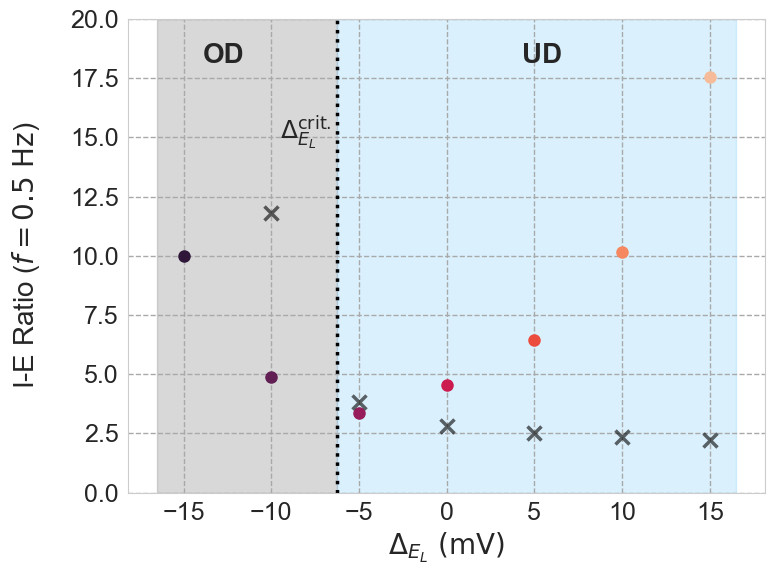

($b=0$ pA, $\nu_{drive}=2$ Hz, $A=1$ Hz)


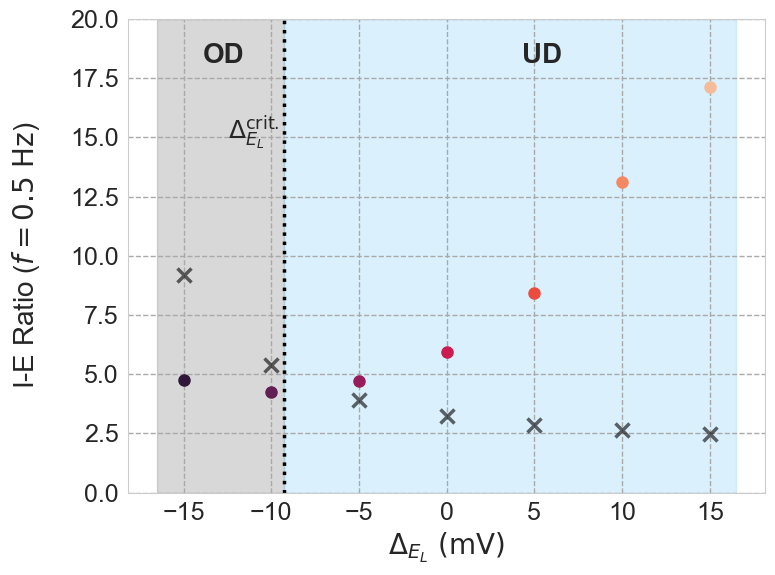

($b=0$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


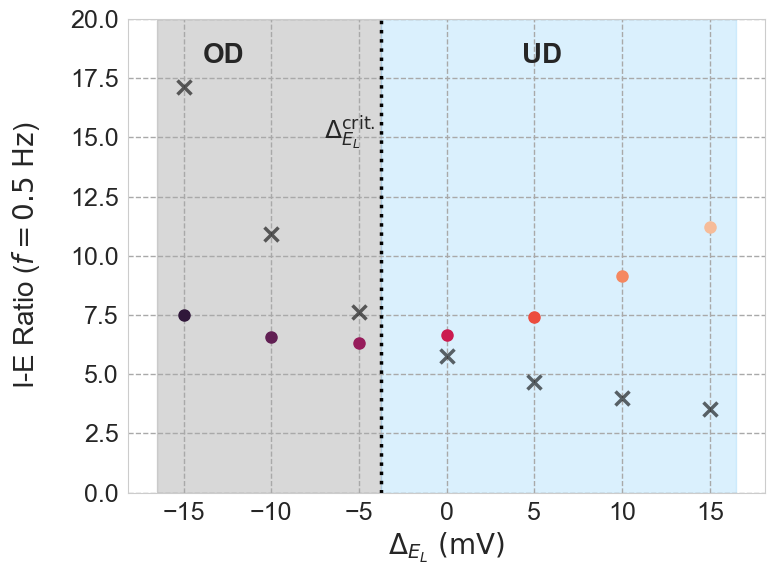

($b=60$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


In [189]:
# r2b0a1
tag = "r2b0a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r2b0
delta_EL_crit = delta_EL_crit_r2b0
b_value = 0
rate_value = 2
A_value = 1
ymax = 20

plot_baseline_response_snapshot(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
)

# r4b0a1
tag = "r4b0a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r4b0
delta_EL_crit = delta_EL_crit_r4b0
b_value = 0
rate_value = 4
A_value = 1
ymax = 20

plot_baseline_response_snapshot(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
)

# r4b60a1
tag = "r4b60a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r4b60
delta_EL_crit = delta_EL_crit_r4b60
b_value = 60
rate_value = 4
A_value = 1
ymax = 20

plot_baseline_response_snapshot(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
)

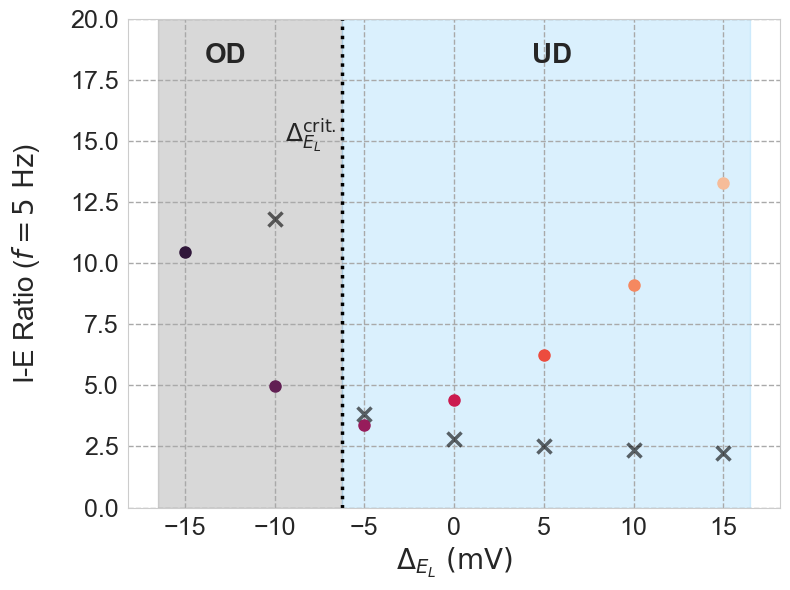

($b=0$ pA, $\nu_{drive}=2$ Hz, $A=1$ Hz)


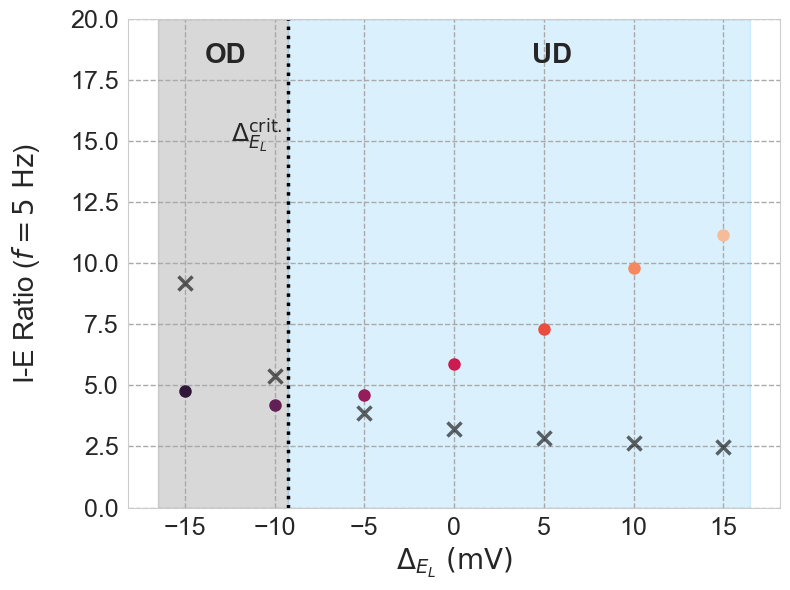

($b=0$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


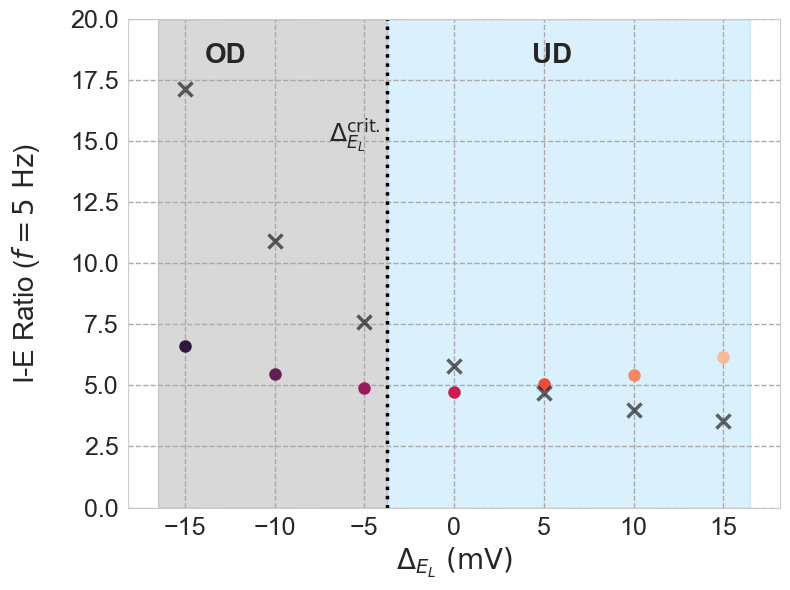

($b=60$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


In [25]:
# r2b0a1
tag = "r2b0a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r2b0
delta_EL_crit = delta_EL_crit_r2b0
b_value = 0
rate_value = 2
A_value = 1
ymax = 20

plot_baseline_response_snapshot(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=5,
)

# r4b0a1
tag = "r4b0a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r4b0
delta_EL_crit = delta_EL_crit_r4b0
b_value = 0
rate_value = 4
A_value = 1
ymax = 20

plot_baseline_response_snapshot(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=5,
)

# r4b60a1
tag = "r4b60a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r4b60
delta_EL_crit = delta_EL_crit_r4b60
b_value = 60
rate_value = 4
A_value = 1
ymax = 20

plot_baseline_response_snapshot(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=5,
)

## Fig. 6
Plots of $\Delta_{\mu_V}$ versus $\Delta_{E_L}$

In [272]:
def plot_delta_muV_snapshot_symbols(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
    symbols_on=False,
):
    """
    Plot excitatory amplitude vs ΔEL,
    with baseline delta_muV overlaid as crosses.
    Optionally annotate three points with symbols.
    """

    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from collections import defaultdict

    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    # ------------------------------------------------------------------
    # Response data (evoked)
    # ------------------------------------------------------------------
    subset = data[data["frequency"] == freq]

    delta_EL_unique = np.sort(subset["delta_EL"].unique())

    delta_colors = dict(
        zip(
            delta_EL_unique,
            sns.color_palette("rocket", n_colors=len(delta_EL_unique)),
        )
    )

    # ------------------------------------------------------------------
    # Baseline data: group by ΔEL and average across seeds
    # ------------------------------------------------------------------
    baseline_by_delta = defaultdict(list)

    for entry in baseline_data:
        delta_EL = entry["EL_exc"] - entry["EL_inh"]
        entry["delta_muV"] = entry["muVe"] - entry["muVi"]
        baseline_by_delta[delta_EL].append(entry["delta_muV"])

    baseline_mean = {
        dEL: np.mean(vals) for dEL, vals in baseline_by_delta.items()
    }

    baseline_std = {
        dEL: np.std(vals, ddof=1) for dEL, vals in baseline_by_delta.items()
    }

    # ------------------------------------------------------------------
    # Plot response + baseline
    # ------------------------------------------------------------------
    for delta_EL in delta_EL_unique:
        if delta_EL in baseline_mean:
            plt.errorbar(
                delta_EL,
                baseline_mean[delta_EL] * 1000,
                yerr=baseline_std.get(delta_EL, None) * 1000,
                fmt="o",
                markersize=8,
                markeredgewidth=2.5,
                color="black",
                ecolor="black",
                elinewidth=1.5,
                capsize=8,
                zorder=5,
            )

    # ------------------------------------------------------------------
    # Optional symbol annotations
    # ------------------------------------------------------------------
    if symbols_on:
        deltas = np.array(sorted(baseline_mean.keys()))

        # index of point closest to critical boundary
        i0 = np.argmin(np.abs(deltas - delta_EL_crit))

        symbol_specs = [
            (i0, r"$\dagger$"),          # closest
            (i0 - 1, r"$*$"),# left
            (i0 + 1, "D"),         # right
        ]

        for idx, sym in symbol_specs:
            if 0 <= idx < len(deltas):
                x = deltas[idx]
                y = baseline_mean[x] * 1000
                plt.plot(
                    x + 0.25, y + 0.4,    # slightly right AND up
                    marker=sym,
                    color="darkblue",
                    markersize=7,        # smaller symbol
                    linestyle="None",
                    zorder=6,
                )

    # ------------------------------------------------------------------
    # Critical value and regions
    # ------------------------------------------------------------------
    crit_val = delta_EL_crit
    ax = plt.gca()
    xmin, xmax = ax.get_xlim()

    ax.axvspan(xmin, crit_val, color="gray", alpha=0.3, zorder=0)
    ax.axvspan(crit_val, xmax, color="lightskyblue", alpha=0.3, zorder=0)

    plt.axvline(
        x=crit_val,
        color="black",
        linestyle=":",
        linewidth=2.5,
    )

    ax.text(
        0.9 * (crit_val - xmin) / (xmax - xmin),
        0.8,
        r"$\Delta_{E_L}^\text{crit.}$",
        ha="center",
        va="top",
        fontsize=18,
        transform=ax.transAxes,
    )

    plt.axhline(
        y=0,
        color="black",
        linestyle="--",
        linewidth=2.5,
    )

    ax.text(
        0.15,
        0.95,
        "OD",
        ha="center",
        va="top",
        fontsize=20,
        fontweight="bold",
        transform=ax.transAxes,
    )

    ax.text(
        0.65,
        0.95,
        "UD",
        ha="center",
        va="top",
        fontsize=20,
        fontweight="bold",
        transform=ax.transAxes,
    )

    # ------------------------------------------------------------------
    # Axes styling
    # ------------------------------------------------------------------
    ax.grid(which="both", linestyle="--", color="darkgray", linewidth=1)
    ax.set_xlabel(r"$\Delta_{E_L} \text{ (mV)}$", fontsize=20)
    ax.set_ylabel(
        r"$\Delta_{\mu_V}$ baseline (mV)",
        fontsize=20,
        labelpad=20,
    )
    ax.set_ylim(-ymax, ymax)

    plt.tick_params(axis="both", which="major", labelsize=18)
    plt.tick_params(axis="both", which="minor", labelsize=18)

    plt.tight_layout()
    plt.show()

    print(rf"($b={b_value}$ pA, $\nu_{{drive}}={rate_value}$ Hz, $A={A_value}$ Hz)")

$\nu_\text{drive}=2 \text{ Hz, } b=0 \text{ pA}$

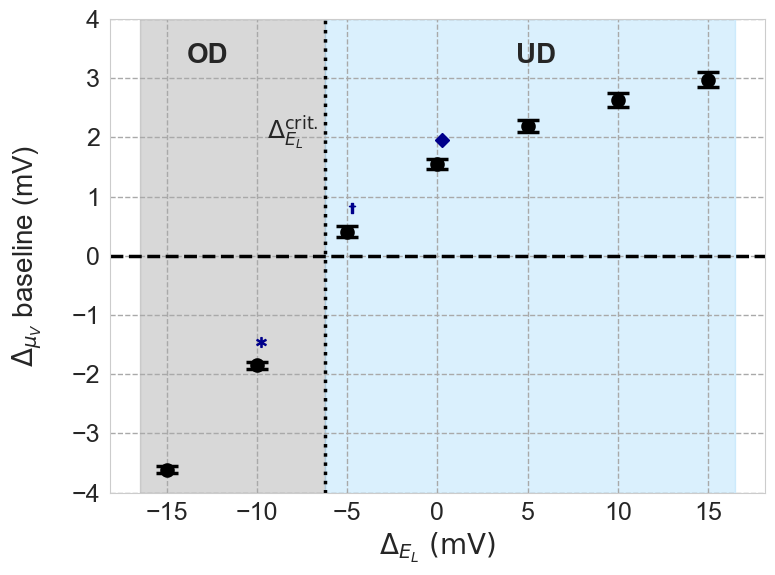

($b=0$ pA, $\nu_{drive}=2$ Hz, $A=1$ Hz)


In [191]:
tag = "r2b0a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r2b0
delta_EL_crit = delta_EL_crit_r2b0
b_value = 0
rate_value = 2
A_value = 1
ymax = 4

plot_delta_muV_snapshot_symbols(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
    symbols_on=True,
)

$\nu_\text{drive}=4 \text{ Hz, } b=0 \text{ pA}$

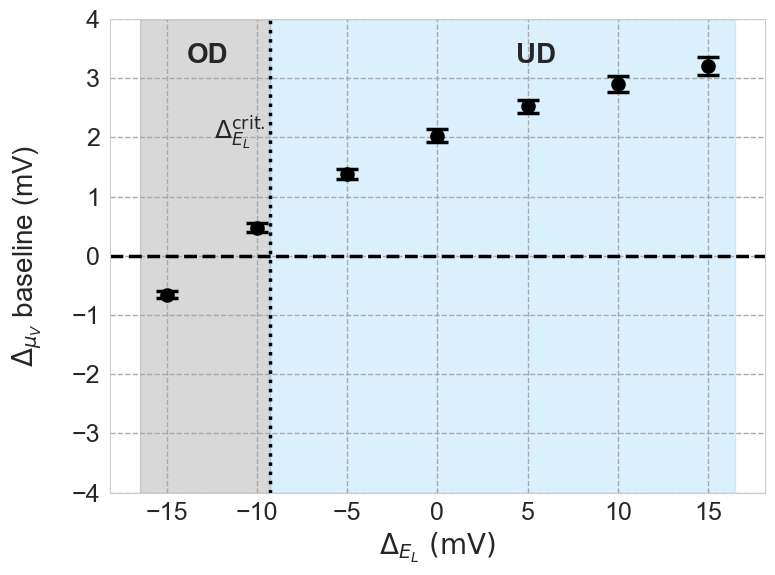

($b=0$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


In [192]:
tag = "r4b0a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r4b0
delta_EL_crit = delta_EL_crit_r4b0
b_value = 0
rate_value = 4
A_value = 1
ymax = 4

plot_delta_muV_snapshot_symbols(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
    symbols_on=False,
)

$\nu_\text{drive}=4 \text{ Hz, } b=60 \text{ pA}$

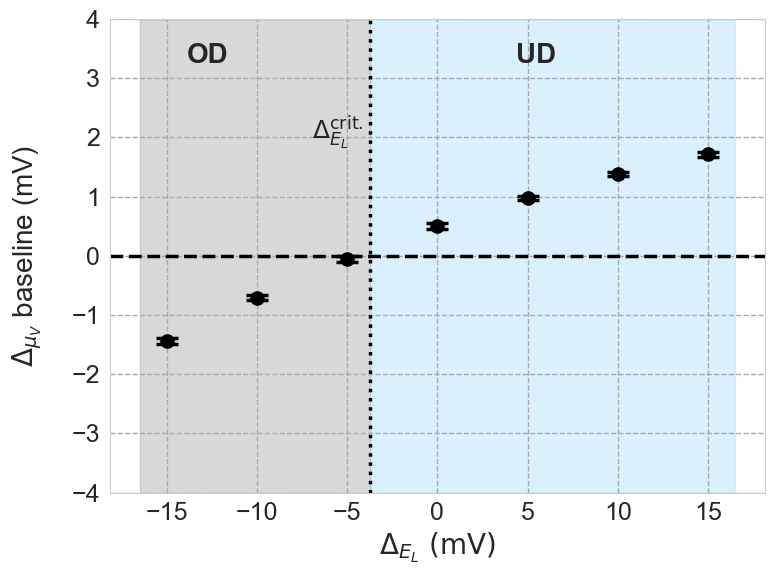

($b=60$ pA, $\nu_{drive}=4$ Hz, $A=1$ Hz)


In [193]:
tag = "r4b60a1"
with open(f"../data/impulse_results_{tag}_final.pkl", "rb") as f:
    results = pickle.load(f)
data = aggregate_impulse_results(results)
baseline_data = baseline_results_new_r4b60
delta_EL_crit = delta_EL_crit_r4b60
b_value = 60
rate_value = 4
A_value = 1
ymax = 4

plot_delta_muV_snapshot_symbols(
    data,
    baseline_data,
    delta_EL_crit,
    b_value,
    rate_value,
    A_value,
    ymax,
    freq=0.5,
    symbols_on=False,
)

## Fig. 7
Pulse inputs

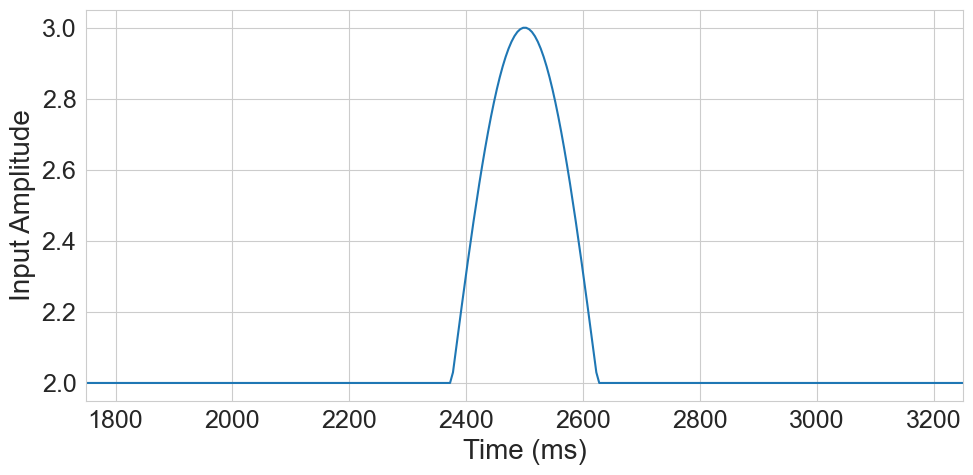

In [197]:
def half_cycle_impulse(t, A=5, period=500, offset=0, t_center=2500):
    """
    Generate a single half-cycle sinusoidal impulse centred at t_center.

    Parameters:
    - A: Amplitude
    - period: Full period of the underlying sine (ms)
    - offset: Baseline offset
    - t_center: Centre of the impulse (ms)

    Returns:
    - waveform
    """
    half_width = period / 4  # half of half-cycle
    t_start = t_center - half_width
    t_end = t_center + half_width

    waveform = np.zeros_like(t) + offset

    mask = (t >= t_start) & (t <= t_end)

    # Map masked time to [0, π]
    phase = (t[mask] - t_start) / (t_end - t_start) * np.pi
    waveform[mask] += A * np.sin(phase)

    return waveform

def plot_half_cycle_impulse(t, A=5, period=500, offset=0, t_center=2500, ylim=None):
    """
    Plot a centred half-cycle impulse with controlled window.

    Parameters:
    - ylim: tuple (ymin, ymax)
    """
    waveform = half_cycle_impulse(t, A, period, offset, t_center)

    half_cycle = period / 2
    window_half_width = 3 * half_cycle

    xmin = t_center - window_half_width
    xmax = t_center + window_half_width

    plt.figure(figsize=(10, 5))
    plt.plot(t, waveform)

    plt.xlim(xmin, xmax)

    if ylim is not None:
        plt.ylim(ylim)

    plt.xlabel('Time (ms)', fontsize=20)
    plt.ylabel('Input Amplitude', fontsize=20)

    plt.tick_params(axis="both", which="major", labelsize=18)
    plt.tick_params(axis="both", which="minor", labelsize=18)

    plt.tight_layout()
    plt.show()

# example plot with A=5, period=500, t0=0, tf=5000
t = np.linspace(0, 5000, 1000)  # Time from 0 to 100 ms
t0 = 2500  # Start time (ms)
tf = 5000 # End time (ms)
A = 1.0  # Amplitude (Hz)
period = 500 # ms
offset = 2.0  # Hz
plot_half_cycle_impulse(t, A, period, offset, t_center=2500)

In [198]:
def run_impulse_simulation_figure_half_cycle_alt(
    b_val, rate, EL_inh, EL_exc,
    A=1, period=500, t_center=2500, binsize=5,
    ylim=None, xlim=None, show_plots=True, seed=12
):

    start_scope()
    np.random.seed(seed)
    brian_seed(seed)

    DT = 0.1
    defaultclock.dt = DT * ms

    N1 = 2000
    N2 = 8000
    TotTime = 5000
    duration = TotTime * ms

    C = 200 * pF
    gL = 10 * nS
    tauw = 500 * ms
    a = 0.0 * nS
    I = 0. * nA
    Ee = 0 * mV
    Ei = -80 * mV

    # --- neuron equations ---
    eqs = """
    dvm/dt=(gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)-GsynE*(vm-Ee)-GsynI*(vm-Ei)+I-w)/C : volt (unless refractory)
    dw/dt=(a*(vm-EL)-w)/tauw : amp
    dGsynI/dt = -GsynI/TsynI : siemens
    dGsynE/dt = -GsynE/TsynE : siemens
    TsynI:second
    TsynE:second
    Vr:volt
    b:amp
    DeltaT:volt
    Vcut:volt
    VT:volt
    EL:volt
    """

    # --- populations ---
    G_inh = NeuronGroup(N1, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')
    G_exc = NeuronGroup(N2, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')

    for G, EL_val, b_val_local in [
        (G_inh, EL_inh, 0),
        (G_exc, EL_exc, b_val)
    ]:
        G.vm = -60 * mV
        G.w = a * (G.vm - G.EL)
        G.Vr = -65 * mV
        G.GsynI = 0.0 * nS
        G.GsynE = 0.0 * nS
        G.TsynI = 5.0 * ms
        G.TsynE = 5.0 * ms
        G.b = float(b_val_local) * pA
        G.DeltaT = 2 * mV if G is G_exc else 0.5 * mV
        G.VT = -50. * mV
        G.Vcut = G.VT + 5 * G.DeltaT
        G.EL = float(EL_val) * mV

    # --- connectivity ---
    Qi = 5.0 * nS
    Qe = 1.5 * nS
    Qe_ext = 1.5 * nS
    prbC = 0.05

    S_ie = Synapses(G_inh, G_exc, on_pre='GsynI_post+=Qi')
    S_ie.connect('i!=j', p=prbC)

    S_ii = Synapses(G_inh, G_inh, on_pre='GsynI_post+=Qi')
    S_ii.connect('i!=j', p=prbC)

    S_ei = Synapses(G_exc, G_inh, on_pre='GsynE_post+=Qe')
    S_ei.connect('i!=j', p=prbC)

    S_ee = Synapses(G_exc, G_exc, on_pre='GsynE_post+=Qe')
    S_ee.connect('i!=j', p=prbC)

    # --- NEW impulse input ---
    DT_aff = 0.1
    time_array_aff = np.arange(0, TotTime, DT_aff)

    afferent_input = half_cycle_impulse(
        time_array_aff, A, period, rate, t_center
    ) * Hz

    rate_array = TimedArray(afferent_input, dt=DT * ms)
    G_aff = PoissonGroup(N2, rates='rate_array(t)')

    S_aff_e = Synapses(G_aff, G_exc, on_pre='GsynE_post+=Qe_ext')
    S_aff_e.connect(p=prbC)

    S_aff_i = Synapses(G_aff, G_inh, on_pre='GsynE_post+=Qe_ext')
    S_aff_i.connect(p=prbC)

    # --- monitors ---
    M1G_inh = SpikeMonitor(G_inh)
    M1G_exc = SpikeMonitor(G_exc)
    FRG_inh = PopulationRateMonitor(G_inh)
    FRG_exc = PopulationRateMonitor(G_exc)

    run(duration)

    # --- binning ---
    def bin_array(array, BIN, time_array):
        N0 = int(BIN / (time_array[1] - time_array[0]))
        N1 = int((time_array[-1] - time_array[0]) / BIN)
        return array[:N0 * N1].reshape((N1, N0)).mean(axis=1)

    BIN = binsize
    time_array = np.asarray(FRG_exc.t / ms)

    TimBinned = bin_array(time_array, BIN, time_array)
    popRateG_exc = bin_array(np.array(FRG_exc.rate / Hz), BIN, time_array)
    popRateG_inh = bin_array(np.array(FRG_inh.rate / Hz), BIN, time_array)
    afferent_binned = bin_array(afferent_input, BIN, time_array)

    # --- centered plotting window ---
    half_cycle = period / 2
    window_half_width = 3 * half_cycle

    if xlim is None:
        xmin = t_center - window_half_width
        xmax = t_center + window_half_width
    else:
        xmin, xmax = xlim

    mask = (TimBinned >= xmin) & (TimBinned <= xmax)

    if show_plots:

        plt.figure(figsize=(8, 6))

        plt.plot(TimBinned[mask], afferent_binned[mask],
                 color='blue', linestyle='--', linewidth=2.0)

        plt.plot(TimBinned[mask], popRateG_exc[mask],
                 color='green', linewidth=1.5)

        plt.plot(TimBinned[mask], popRateG_inh[mask],
                 color='red', linewidth=1.5)

        plt.xlim(xmin, xmax)

        if ylim is not None:
            plt.ylim(ylim)

        plt.xlabel('Time (ms)', fontsize=20)
        plt.ylabel('Firing rate (Hz)', fontsize=20, labelpad=15)

        plt.tick_params(axis="both", labelsize=18)

        plt.tight_layout()
        plt.subplots_adjust(left=0.12)
        plt.show()

    return {
        "b_val": b_val,
        "rate": rate,
        "EL_inh": EL_inh,
        "EL_exc": EL_exc,
        "A": A,
        "period": period,
        "time": TimBinned,
        "exc": popRateG_exc,
        "inh": popRateG_inh,
        "aff": afferent_binned
    }

In [199]:
def run_impulse_multiseed(
    n_seeds,
    seeds=None,
    verbose=True,
    **sim_kwargs
):
    """
    Run the same simulation across multiple seeds with progress updates.
    """

    if seeds is None:
        seeds = np.arange(n_seeds)

    all_exc = []
    all_inh = []
    all_aff = []

    start_time = time.time()

    for i, seed in enumerate(seeds):

        iter_start = time.time()

        result = run_impulse_simulation_figure_half_cycle_alt(
            **sim_kwargs,
            seed=int(seed),
            show_plots=False
        )

        all_exc.append(result["exc"])
        all_inh.append(result["inh"])
        all_aff.append(result["aff"])
        time_array = result["time"]

        # --- progress reporting ---
        if verbose:
            elapsed = time.time() - start_time
            iter_time = time.time() - iter_start

            completed = i + 1
            remaining = n_seeds - completed

            avg_time = elapsed / completed
            eta = avg_time * remaining

            print(
                f"[{completed}/{n_seeds}] "
                f"seed={seed} | "
                f"iter={iter_time:.2f}s | "
                f"elapsed={elapsed:.1f}s | "
                f"ETA={eta:.1f}s"
            )

    total_time = time.time() - start_time

    if verbose:
        print(f"\nFinished {n_seeds} simulations in {total_time:.2f}s")

    return {
        "time": time_array,
        "exc": np.array(all_exc),
        "inh": np.array(all_inh),
        "aff": np.array(all_aff)
    }
    

def compute_mean_std(data):
    return np.mean(data, axis=0), np.std(data, axis=0)

def plot_multiseed_impulse(
    results,
    period,
    t_center=2500,
    ylim=None,
    xlim=None
):
    """
    Plot mean ± std across seeds.
    """

    time = results["time"]

    exc_mean, exc_std = compute_mean_std(results["exc"])
    inh_mean, inh_std = compute_mean_std(results["inh"])
    aff_mean, _ = compute_mean_std(results["aff"])  # deterministic anyway

    # --- window ---
    half_cycle = period / 2
    window_half_width = 3 * half_cycle

    if xlim is None:
        xmin = t_center - window_half_width
        xmax = t_center + window_half_width
    else:
        xmin, xmax = xlim

    mask = (time >= xmin) & (time <= xmax)

    # --- plot ---
    plt.figure(figsize=(8, 6))

    # afferent
    plt.plot(time[mask], aff_mean[mask],
             color='blue', linestyle='--', linewidth=2.0)

    # excitatory mean + std
    plt.plot(time[mask], exc_mean[mask],
             color='green', linewidth=2)
    plt.fill_between(
        time[mask],
        exc_mean[mask] - exc_std[mask],
        exc_mean[mask] + exc_std[mask],
        color='green',
        alpha=0.2
    )

    # inhibitory mean + std
    plt.plot(time[mask], inh_mean[mask],
             color='red', linewidth=2)
    plt.fill_between(
        time[mask],
        inh_mean[mask] - inh_std[mask],
        inh_mean[mask] + inh_std[mask],
        color='red',
        alpha=0.2
    )

    plt.xlim(xmin, xmax)

    if ylim is not None:
        plt.ylim(ylim)

    plt.xlabel('Time (ms)', fontsize=20)
    plt.ylabel('Firing rate (Hz)', fontsize=20, labelpad=15)

    plt.tick_params(axis="both", labelsize=18)

    plt.tight_layout()
    plt.subplots_adjust(left=0.12)
    plt.show()

#### Freq = 0.5 Hz (period = 2000 ms)

WARNING    'i' is an internal variable of group 'synapses_2', but also exists in the run namespace with the value 69. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_3', but also exists in the run namespace with the value 69. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_4', but also exists in the run namespace with the value 69. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


delta_EL = -15 mV (OD), period = 2000 ms


WARNING    'i' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value 69. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[1/10] seed=0 | iter=33.95s | elapsed=34.0s | ETA=305.6s
[2/10] seed=1 | iter=27.19s | elapsed=61.1s | ETA=244.6s
[3/10] seed=2 | iter=12.72s | elapsed=73.9s | ETA=172.3s
[4/10] seed=3 | iter=9.85s | elapsed=83.7s | ETA=125.6s
[5/10] seed=4 | iter=9.81s | elapsed=93.5s | ETA=93.5s
[6/10] seed=5 | iter=9.80s | elapsed=103.3s | ETA=68.9s
[7/10] seed=6 | iter=9.81s | elapsed=113.1s | ETA=48.5s
[8/10] seed=7 | iter=9.96s | elapsed=123.1s | ETA=30.8s
[9/10] seed=8 | iter=9.84s | elapsed=132.9s | ETA=14.8s
[10/10] seed=9 | iter=9.85s | elapsed=142.8s | ETA=0.0s

Finished 10 simulations in 142.79s


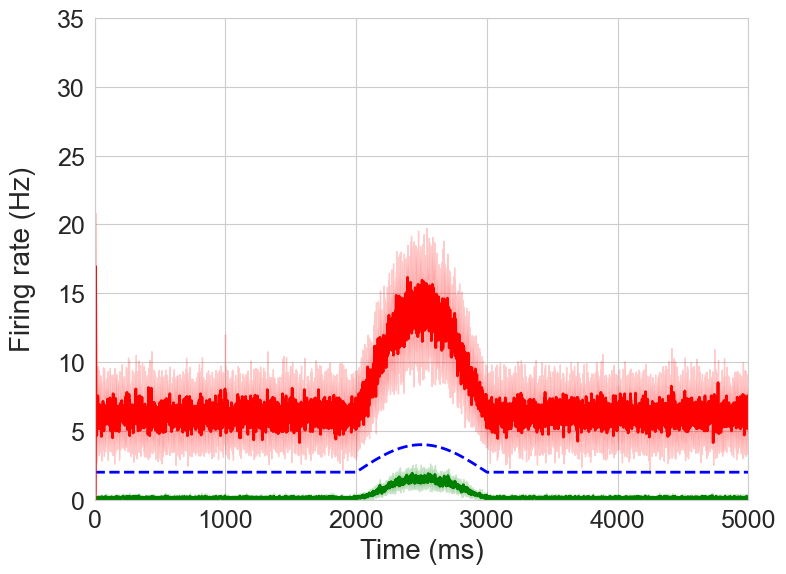

In [200]:
print("delta_EL = -15 mV (OD), period = 2000 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-55,
    EL_exc=-70,
    A=2,
    period=2000,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=2000,
    t_center=2500,
    ylim=(0, 35),
    xlim=(0, 5000)
)

delta_EL = -5 mV (crit), period = 2000 ms
[1/10] seed=0 | iter=12.50s | elapsed=12.5s | ETA=112.5s
[2/10] seed=1 | iter=12.09s | elapsed=24.6s | ETA=98.4s
[3/10] seed=2 | iter=11.12s | elapsed=35.7s | ETA=83.3s
[4/10] seed=3 | iter=10.69s | elapsed=46.4s | ETA=69.6s
[5/10] seed=4 | iter=10.77s | elapsed=57.2s | ETA=57.2s
[6/10] seed=5 | iter=10.91s | elapsed=68.1s | ETA=45.4s
[7/10] seed=6 | iter=12.11s | elapsed=80.2s | ETA=34.4s
[8/10] seed=7 | iter=12.53s | elapsed=92.7s | ETA=23.2s
[9/10] seed=8 | iter=12.07s | elapsed=104.8s | ETA=11.6s
[10/10] seed=9 | iter=12.36s | elapsed=117.1s | ETA=0.0s

Finished 10 simulations in 117.15s


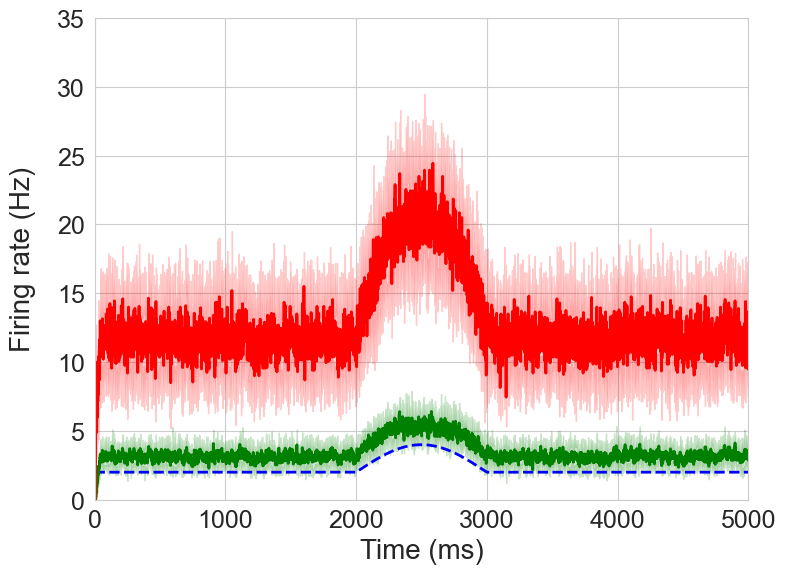

In [201]:
print("delta_EL = -5 mV (crit), period = 2000 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-65,
    EL_exc=-70,
    A=2,
    period=2000,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=2000,
    t_center=2500,
    ylim=(0, 35),
    xlim=(0, 5000)
)

delta_EL = 5 mV (UD), period = 2000 ms
[1/10] seed=0 | iter=12.67s | elapsed=12.7s | ETA=114.1s
[2/10] seed=1 | iter=12.51s | elapsed=25.2s | ETA=100.7s
[3/10] seed=2 | iter=12.70s | elapsed=37.9s | ETA=88.4s
[4/10] seed=3 | iter=12.37s | elapsed=50.3s | ETA=75.4s
[5/10] seed=4 | iter=12.52s | elapsed=62.8s | ETA=62.8s
[6/10] seed=5 | iter=12.58s | elapsed=75.4s | ETA=50.2s
[7/10] seed=6 | iter=12.42s | elapsed=87.8s | ETA=37.6s
[8/10] seed=7 | iter=12.14s | elapsed=99.9s | ETA=25.0s
[9/10] seed=8 | iter=12.35s | elapsed=112.3s | ETA=12.5s
[10/10] seed=9 | iter=12.31s | elapsed=124.6s | ETA=0.0s

Finished 10 simulations in 124.58s


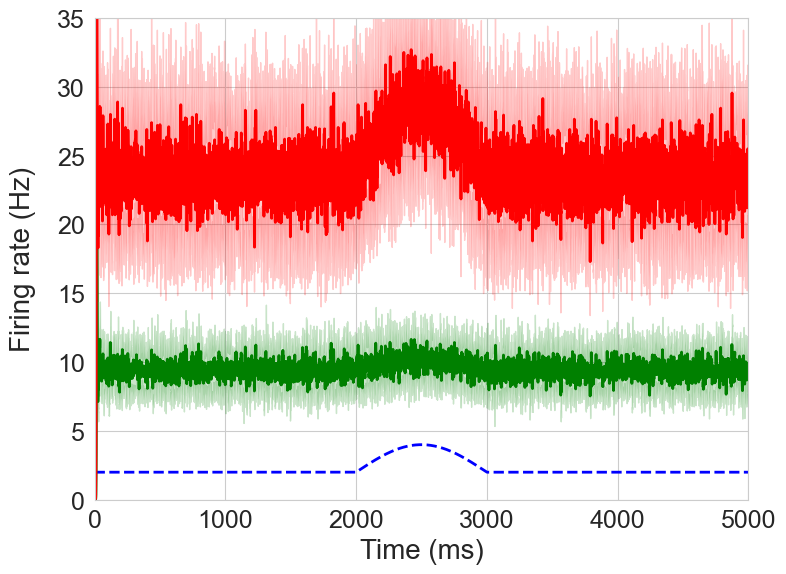

In [202]:
print("delta_EL = 5 mV (UD), period = 2000 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-75,
    EL_exc=-70,
    A=2,
    period=2000,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=2000,
    t_center=2500,
    ylim=(0, 35),
    xlim=(0, 5000)
)

#### Freq = 5 Hz (period = 200 ms)

delta_EL = -15 mV (OD), period = 200 ms
[1/10] seed=0 | iter=10.11s | elapsed=10.1s | ETA=91.0s
[2/10] seed=1 | iter=9.79s | elapsed=19.9s | ETA=79.6s
[3/10] seed=2 | iter=9.81s | elapsed=29.7s | ETA=69.3s
[4/10] seed=3 | iter=9.74s | elapsed=39.4s | ETA=59.2s
[5/10] seed=4 | iter=10.05s | elapsed=49.5s | ETA=49.5s
[6/10] seed=5 | iter=9.92s | elapsed=59.4s | ETA=39.6s
[7/10] seed=6 | iter=9.87s | elapsed=69.3s | ETA=29.7s
[8/10] seed=7 | iter=9.78s | elapsed=79.1s | ETA=19.8s
[9/10] seed=8 | iter=9.94s | elapsed=89.0s | ETA=9.9s
[10/10] seed=9 | iter=10.11s | elapsed=99.1s | ETA=0.0s

Finished 10 simulations in 99.10s


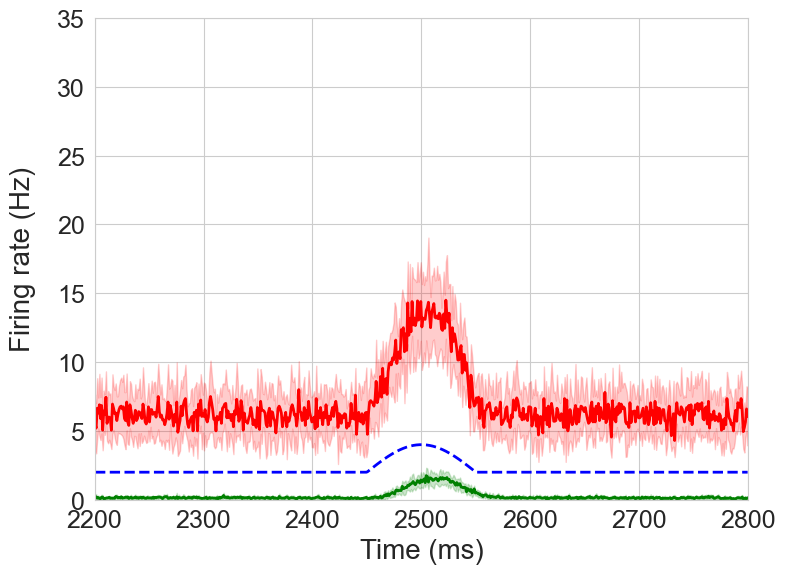

In [203]:
print("delta_EL = -15 mV (OD), period = 200 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-55,
    EL_exc=-70,
    A=2,
    period=200,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=200,
    t_center=2500,
    ylim=(0, 35),
    xlim=None
)

delta_EL = -5 mV (crit), period = 200 ms
[1/10] seed=0 | iter=11.10s | elapsed=11.1s | ETA=99.9s
[2/10] seed=1 | iter=10.78s | elapsed=21.9s | ETA=87.5s
[3/10] seed=2 | iter=10.86s | elapsed=32.7s | ETA=76.4s
[4/10] seed=3 | iter=10.70s | elapsed=43.4s | ETA=65.2s
[5/10] seed=4 | iter=10.89s | elapsed=54.3s | ETA=54.3s
[6/10] seed=5 | iter=10.89s | elapsed=65.2s | ETA=43.5s
[7/10] seed=6 | iter=10.86s | elapsed=76.1s | ETA=32.6s
[8/10] seed=7 | iter=10.63s | elapsed=86.7s | ETA=21.7s
[9/10] seed=8 | iter=10.88s | elapsed=97.6s | ETA=10.8s
[10/10] seed=9 | iter=12.66s | elapsed=110.3s | ETA=0.0s

Finished 10 simulations in 110.27s


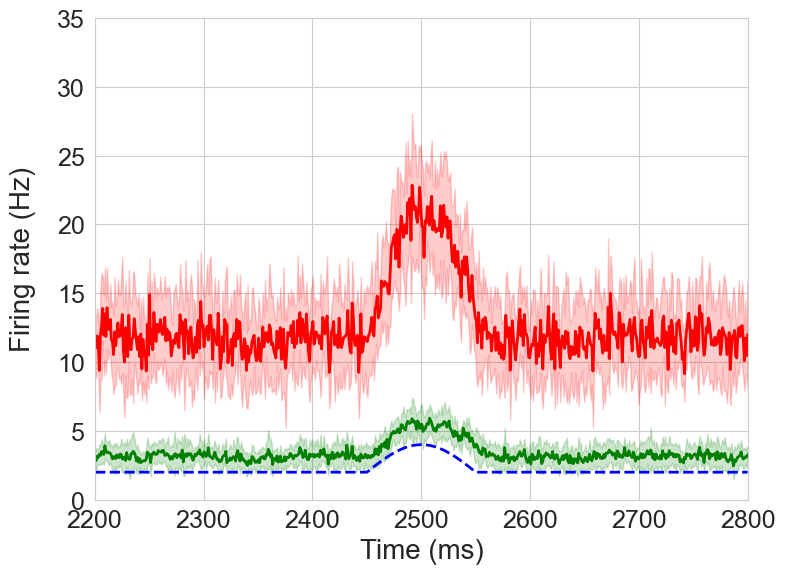

In [204]:
print("delta_EL = -5 mV (crit), period = 200 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-65,
    EL_exc=-70,
    A=2,
    period=200,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=200,
    t_center=2500,
    ylim=(0, 35),
    xlim=None
)

delta_EL = 5 mV (UD), period = 200 ms
[1/10] seed=0 | iter=13.17s | elapsed=13.2s | ETA=118.5s
[2/10] seed=1 | iter=12.89s | elapsed=26.1s | ETA=104.2s
[3/10] seed=2 | iter=12.53s | elapsed=38.6s | ETA=90.0s
[4/10] seed=3 | iter=12.51s | elapsed=51.1s | ETA=76.6s
[5/10] seed=4 | iter=12.67s | elapsed=63.8s | ETA=63.8s
[6/10] seed=5 | iter=12.59s | elapsed=76.4s | ETA=50.9s
[7/10] seed=6 | iter=12.41s | elapsed=88.8s | ETA=38.0s
[8/10] seed=7 | iter=12.24s | elapsed=101.0s | ETA=25.3s
[9/10] seed=8 | iter=12.39s | elapsed=113.4s | ETA=12.6s
[10/10] seed=9 | iter=12.48s | elapsed=125.9s | ETA=0.0s

Finished 10 simulations in 125.87s


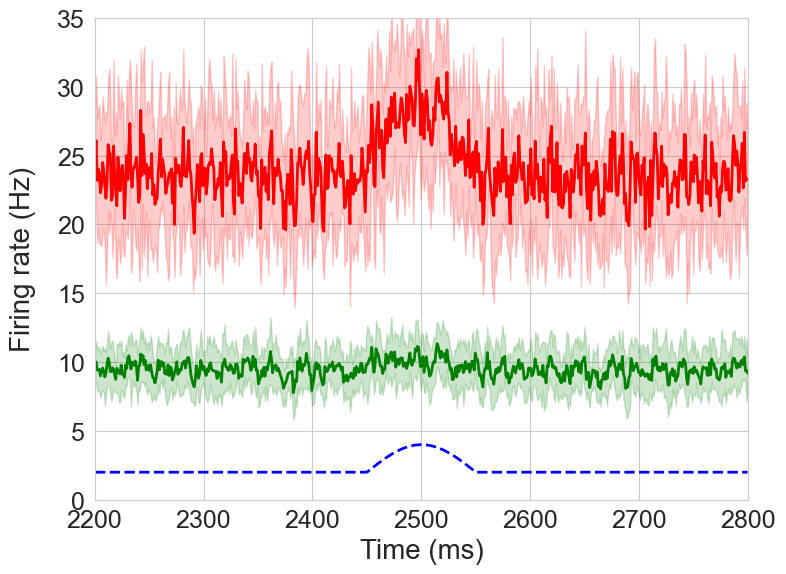

In [205]:
print("delta_EL = 5 mV (UD), period = 200 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-75,
    EL_exc=-70,
    A=2,
    period=200,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=200,
    t_center=2500,
    ylim=(0, 35),
    xlim=None
)

#### Freq = 50 Hz (period = 20 ms)

delta_EL = -15 mV (OD), period = 20 ms
[1/10] seed=0 | iter=10.05s | elapsed=10.1s | ETA=90.5s
[2/10] seed=1 | iter=9.82s | elapsed=19.9s | ETA=79.5s
[3/10] seed=2 | iter=9.92s | elapsed=29.8s | ETA=69.5s
[4/10] seed=3 | iter=9.83s | elapsed=39.6s | ETA=59.5s
[5/10] seed=4 | iter=10.14s | elapsed=49.8s | ETA=49.8s
[6/10] seed=5 | iter=9.89s | elapsed=59.7s | ETA=39.8s
[7/10] seed=6 | iter=10.13s | elapsed=69.8s | ETA=29.9s
[8/10] seed=7 | iter=9.88s | elapsed=79.7s | ETA=19.9s
[9/10] seed=8 | iter=9.84s | elapsed=89.5s | ETA=9.9s
[10/10] seed=9 | iter=9.85s | elapsed=99.4s | ETA=0.0s

Finished 10 simulations in 99.38s


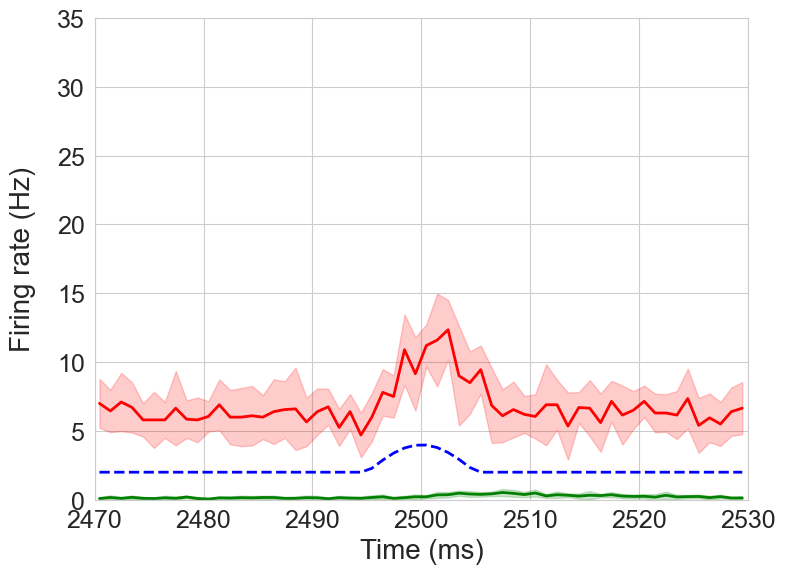

In [206]:
print("delta_EL = -15 mV (OD), period = 20 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-55,
    EL_exc=-70,
    A=2,
    period=20,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=20,
    t_center=2500,
    ylim=(0, 35),
    xlim=None
)

delta_EL = -5 mV (crit), period = 20 ms
[1/10] seed=0 | iter=11.15s | elapsed=11.2s | ETA=100.4s
[2/10] seed=1 | iter=10.88s | elapsed=22.0s | ETA=88.1s
[3/10] seed=2 | iter=11.41s | elapsed=33.4s | ETA=78.0s
[4/10] seed=3 | iter=10.85s | elapsed=44.3s | ETA=66.4s
[5/10] seed=4 | iter=11.43s | elapsed=55.7s | ETA=55.7s
[6/10] seed=5 | iter=12.04s | elapsed=67.8s | ETA=45.2s
[7/10] seed=6 | iter=11.88s | elapsed=79.6s | ETA=34.1s
[8/10] seed=7 | iter=11.54s | elapsed=91.2s | ETA=22.8s
[9/10] seed=8 | iter=12.07s | elapsed=103.3s | ETA=11.5s
[10/10] seed=9 | iter=11.66s | elapsed=114.9s | ETA=0.0s

Finished 10 simulations in 114.92s


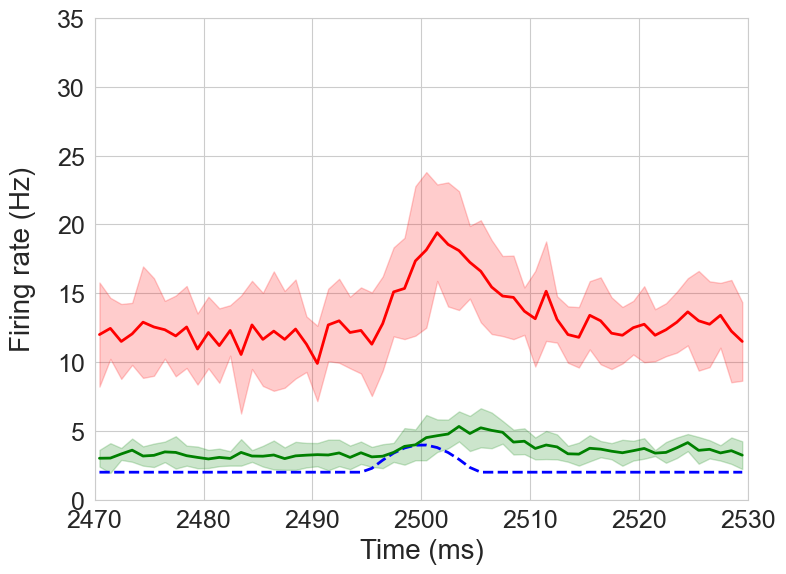

In [207]:
print("delta_EL = -5 mV (crit), period = 20 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-65,
    EL_exc=-70,
    A=2,
    period=20,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=20,
    t_center=2500,
    ylim=(0, 35),
    xlim=None
)

delta_EL = 5 mV (UD), period = 20 ms
[1/10] seed=0 | iter=14.18s | elapsed=14.2s | ETA=127.7s
[2/10] seed=1 | iter=14.08s | elapsed=28.3s | ETA=113.1s
[3/10] seed=2 | iter=13.49s | elapsed=41.7s | ETA=97.4s
[4/10] seed=3 | iter=13.38s | elapsed=55.1s | ETA=82.7s
[5/10] seed=4 | iter=14.31s | elapsed=69.4s | ETA=69.4s
[6/10] seed=5 | iter=13.12s | elapsed=82.6s | ETA=55.0s
[7/10] seed=6 | iter=12.35s | elapsed=94.9s | ETA=40.7s
[8/10] seed=7 | iter=12.29s | elapsed=107.2s | ETA=26.8s
[9/10] seed=8 | iter=12.29s | elapsed=119.5s | ETA=13.3s
[10/10] seed=9 | iter=12.29s | elapsed=131.8s | ETA=0.0s

Finished 10 simulations in 131.78s


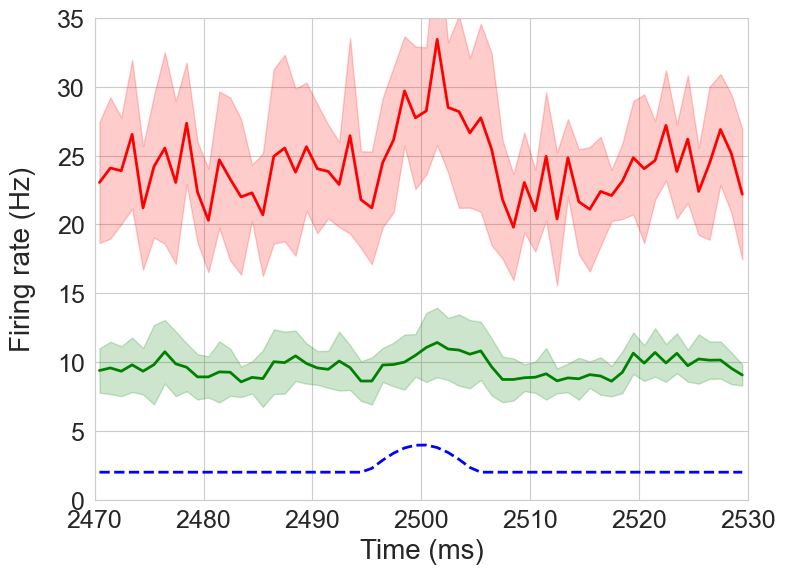

In [208]:
print("delta_EL = 5 mV (UD), period = 20 ms")

results = run_impulse_multiseed(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-75,
    EL_exc=-70,
    A=2,
    period=20,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse(
    results,
    period=20,
    t_center=2500,
    ylim=(0, 35),
    xlim=None
)

## Fig. 8
Two oscillation cycles

In [209]:
def two_cycle_impulse(t, A=5, period=500, offset=0, t_center=2500):
    """
    Generate a 2-full-cycle sinusoidal impulse centred at t_center,
    oscillating around `offset`, clipped at zero if necessary.
    """

    total_duration = 2 * period  # 2 full cycles
    t_start = t_center - total_duration / 2
    t_end = t_center + total_duration / 2

    waveform = np.zeros_like(t) + offset

    mask = (t >= t_start) & (t <= t_end)
    phase = (t[mask] - t_start) / (t_end - t_start) * (4 * np.pi)  # 2 cycles

    waveform[mask] += A * np.sin(phase)

    # Clip to zero to avoid negative external drive
    waveform = np.clip(waveform, 0, None)

    return waveform

In [210]:
def run_impulse_simulation_figure_two_cycle_alt(
    b_val, rate, EL_inh, EL_exc,
    A=1, period=500, t_center=2500, binsize=5,
    ylim=None, xlim=None, show_plots=True, seed=12
):

    start_scope()
    np.random.seed(seed)
    brian_seed(seed)

    DT = 0.1
    defaultclock.dt = DT * ms

    N1 = 2000
    N2 = 8000
    TotTime = 5000
    duration = TotTime * ms

    C = 200 * pF
    gL = 10 * nS
    tauw = 500 * ms
    a = 0.0 * nS
    I = 0. * nA
    Ee = 0 * mV
    Ei = -80 * mV

    eqs = """
    dvm/dt=(gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)-GsynE*(vm-Ee)-GsynI*(vm-Ei)+I-w)/C : volt (unless refractory)
    dw/dt=(a*(vm-EL)-w)/tauw : amp
    dGsynI/dt = -GsynI/TsynI : siemens
    dGsynE/dt = -GsynE/TsynE : siemens
    TsynI:second
    TsynE:second
    Vr:volt
    b:amp
    DeltaT:volt
    Vcut:volt
    VT:volt
    EL:volt
    """

    G_inh = NeuronGroup(N1, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')
    G_exc = NeuronGroup(N2, model=eqs, threshold='vm > Vcut',
                        reset="vm = Vr; w += b", refractory='5*ms', method='heun')

    for G, EL_val, b_val_local in [
        (G_inh, EL_inh, 0),
        (G_exc, EL_exc, b_val)
    ]:
        G.vm = -60 * mV
        G.w = a * (G.vm - G.EL)
        G.Vr = -65 * mV
        G.GsynI = 0.0 * nS
        G.GsynE = 0.0 * nS
        G.TsynI = 5.0 * ms
        G.TsynE = 5.0 * ms
        G.b = float(b_val_local) * pA
        G.DeltaT = 2 * mV if G is G_exc else 0.5 * mV
        G.VT = -50. * mV
        G.Vcut = G.VT + 5 * G.DeltaT
        G.EL = float(EL_val) * mV

    Qi = 5.0 * nS
    Qe = 1.5 * nS
    Qe_ext = 1.5 * nS
    prbC = 0.05

    S_ie = Synapses(G_inh, G_exc, on_pre='GsynI_post+=Qi')
    S_ie.connect('i!=j', p=prbC)

    S_ii = Synapses(G_inh, G_inh, on_pre='GsynI_post+=Qi')
    S_ii.connect('i!=j', p=prbC)

    S_ei = Synapses(G_exc, G_inh, on_pre='GsynE_post+=Qe')
    S_ei.connect('i!=j', p=prbC)

    S_ee = Synapses(G_exc, G_exc, on_pre='GsynE_post+=Qe')
    S_ee.connect('i!=j', p=prbC)

    # --- UPDATED INPUT ---
    DT_aff = 0.1
    time_array_aff = np.arange(0, TotTime, DT_aff)

    afferent_input = two_cycle_impulse(
        time_array_aff, A, period, rate, t_center
    ) * Hz

    rate_array = TimedArray(afferent_input, dt=DT * ms)
    G_aff = PoissonGroup(N2, rates='rate_array(t)')

    S_aff_e = Synapses(G_aff, G_exc, on_pre='GsynE_post+=Qe_ext')
    S_aff_e.connect(p=prbC)

    S_aff_i = Synapses(G_aff, G_inh, on_pre='GsynE_post+=Qe_ext')
    S_aff_i.connect(p=prbC)

    M1G_inh = SpikeMonitor(G_inh)
    M1G_exc = SpikeMonitor(G_exc)
    FRG_inh = PopulationRateMonitor(G_inh)
    FRG_exc = PopulationRateMonitor(G_exc)

    run(duration)

    def bin_array(array, BIN, time_array):
        N0 = int(BIN / (time_array[1] - time_array[0]))
        N1 = int((time_array[-1] - time_array[0]) / BIN)
        return array[:N0 * N1].reshape((N1, N0)).mean(axis=1)

    BIN = binsize
    time_array = np.asarray(FRG_exc.t / ms)

    TimBinned = bin_array(time_array, BIN, time_array)
    popRateG_exc = bin_array(np.array(FRG_exc.rate / Hz), BIN, time_array)
    popRateG_inh = bin_array(np.array(FRG_inh.rate / Hz), BIN, time_array)
    afferent_binned = bin_array(afferent_input, BIN, time_array)

    # --- UPDATED WINDOW ---
    if xlim is None:
        xmin = t_center - 2 * period
        xmax = t_center + 2 * period
    else:
        xmin, xmax = xlim

    mask = (TimBinned >= xmin) & (TimBinned <= xmax)

    if show_plots:

        plt.figure(figsize=(8, 6))

        plt.plot(TimBinned[mask], afferent_binned[mask],
                 color='blue', linestyle='--', linewidth=2.0)

        plt.plot(TimBinned[mask], popRateG_exc[mask],
                 color='green', linewidth=1.5)

        plt.plot(TimBinned[mask], popRateG_inh[mask],
                 color='red', linewidth=1.5)

        plt.xlim(xmin, xmax)

        if ylim is not None:
            plt.ylim(ylim)

        plt.xlabel('Time (ms)', fontsize=20)
        plt.ylabel('Firing rate (Hz)', fontsize=20, labelpad=15)

        plt.tick_params(axis="both", labelsize=18)

        plt.tight_layout()
        plt.subplots_adjust(left=0.12)
        plt.show()

    return {
        "b_val": b_val,
        "rate": rate,
        "EL_inh": EL_inh,
        "EL_exc": EL_exc,
        "A": A,
        "period": period,
        "time": TimBinned,
        "exc": popRateG_exc,
        "inh": popRateG_inh,
        "aff": afferent_binned
    }

In [211]:
def run_impulse_multiseed_two_cycle(
    n_seeds,
    seeds=None,
    verbose=True,
    **sim_kwargs
):
    if seeds is None:
        seeds = np.arange(n_seeds)

    all_exc, all_inh, all_aff = [], [], []

    start_time = time.time()

    for i, seed in enumerate(seeds):

        iter_start = time.time()

        result = run_impulse_simulation_figure_two_cycle_alt(
            **sim_kwargs,
            seed=int(seed),
            show_plots=False
        )

        all_exc.append(result["exc"])
        all_inh.append(result["inh"])
        all_aff.append(result["aff"])
        time_array = result["time"]

        if verbose:
            elapsed = time.time() - start_time
            iter_time = time.time() - iter_start
            completed = i + 1
            remaining = n_seeds - completed
            eta = (elapsed / completed) * remaining

            print(f"[{completed}/{n_seeds}] seed={seed} | iter={iter_time:.2f}s | elapsed={elapsed:.1f}s | ETA={eta:.1f}s")

    return {
        "time": time_array,
        "exc": np.array(all_exc),
        "inh": np.array(all_inh),
        "aff": np.array(all_aff)
    }

def plot_multiseed_impulse_two_cycle(
    results,
    period,
    t_center=2500,
    ylim=None,
    xlim=None
):

    time = results["time"]

    exc_mean, exc_std = compute_mean_std(results["exc"])
    inh_mean, inh_std = compute_mean_std(results["inh"])
    aff_mean, _ = compute_mean_std(results["aff"])

    # --- UPDATED WINDOW ---
    if xlim is None:
        xmin = t_center - 2 * period
        xmax = t_center + 2 * period
    else:
        xmin, xmax = xlim

    mask = (time >= xmin) & (time <= xmax)

    plt.figure(figsize=(8, 6))

    plt.plot(time[mask], aff_mean[mask],
             color='blue', linestyle='--', linewidth=2.0)

    plt.plot(time[mask], exc_mean[mask],
             color='green', linewidth=2)
    plt.fill_between(time[mask],
                     exc_mean[mask] - exc_std[mask],
                     exc_mean[mask] + exc_std[mask],
                     color='green', alpha=0.2)

    plt.plot(time[mask], inh_mean[mask],
             color='red', linewidth=2)
    plt.fill_between(time[mask],
                     inh_mean[mask] - inh_std[mask],
                     inh_mean[mask] + inh_std[mask],
                     color='red', alpha=0.2)

    plt.xlim(xmin, xmax)

    if ylim is not None:
        plt.ylim(ylim)

    plt.xlabel('Time (ms)', fontsize=20)
    plt.ylabel('Firing rate (Hz)', fontsize=20, labelpad=15)

    plt.tick_params(axis="both", labelsize=18)

    plt.tight_layout()
    plt.subplots_adjust(left=0.12)
    plt.show()

delta_EL = 5 mV (UD), period = 2000 ms
[1/10] seed=0 | iter=12.61s | elapsed=12.6s | ETA=113.5s
[2/10] seed=1 | iter=12.45s | elapsed=25.1s | ETA=100.2s
[3/10] seed=2 | iter=12.35s | elapsed=37.4s | ETA=87.3s
[4/10] seed=3 | iter=12.26s | elapsed=49.7s | ETA=74.5s
[5/10] seed=4 | iter=12.27s | elapsed=61.9s | ETA=61.9s
[6/10] seed=5 | iter=12.63s | elapsed=74.6s | ETA=49.7s
[7/10] seed=6 | iter=12.31s | elapsed=86.9s | ETA=37.2s
[8/10] seed=7 | iter=12.12s | elapsed=99.0s | ETA=24.7s
[9/10] seed=8 | iter=12.26s | elapsed=111.3s | ETA=12.4s
[10/10] seed=9 | iter=12.57s | elapsed=123.8s | ETA=0.0s


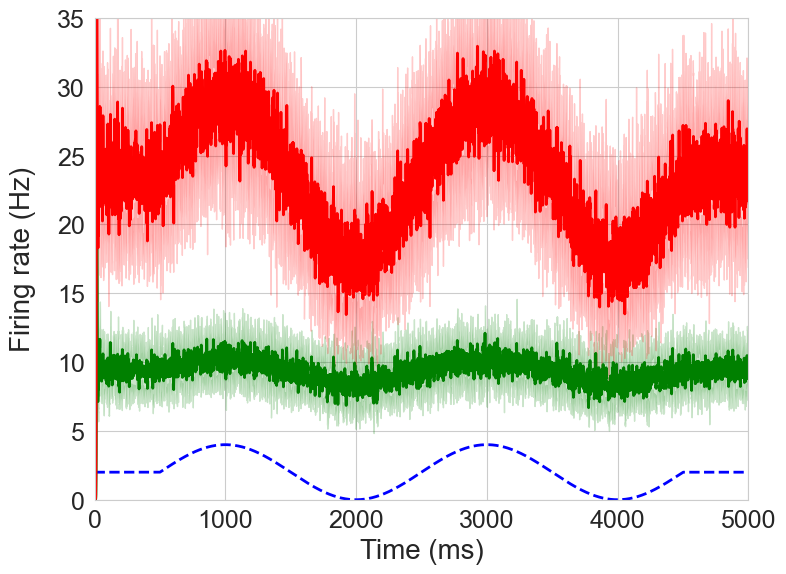

In [212]:
print("delta_EL = 5 mV (UD), period = 2000 ms")

results = run_impulse_multiseed_two_cycle(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-75,
    EL_exc=-70,
    A=2,
    period=2000,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse_two_cycle(
    results,
    period=2000,
    t_center=2500,
    ylim=(0, 35),
    xlim=(0, 5000)
)

delta_EL = 5 mV (UD), period = 200 ms
[1/10] seed=0 | iter=12.57s | elapsed=12.6s | ETA=113.1s
[2/10] seed=1 | iter=12.49s | elapsed=25.1s | ETA=100.2s
[3/10] seed=2 | iter=12.36s | elapsed=37.4s | ETA=87.3s
[4/10] seed=3 | iter=13.19s | elapsed=50.6s | ETA=75.9s
[5/10] seed=4 | iter=14.26s | elapsed=64.9s | ETA=64.9s
[6/10] seed=5 | iter=16.23s | elapsed=81.1s | ETA=54.1s
[7/10] seed=6 | iter=14.25s | elapsed=95.3s | ETA=40.9s
[8/10] seed=7 | iter=13.86s | elapsed=109.2s | ETA=27.3s
[9/10] seed=8 | iter=15.02s | elapsed=124.2s | ETA=13.8s
[10/10] seed=9 | iter=15.04s | elapsed=139.3s | ETA=0.0s


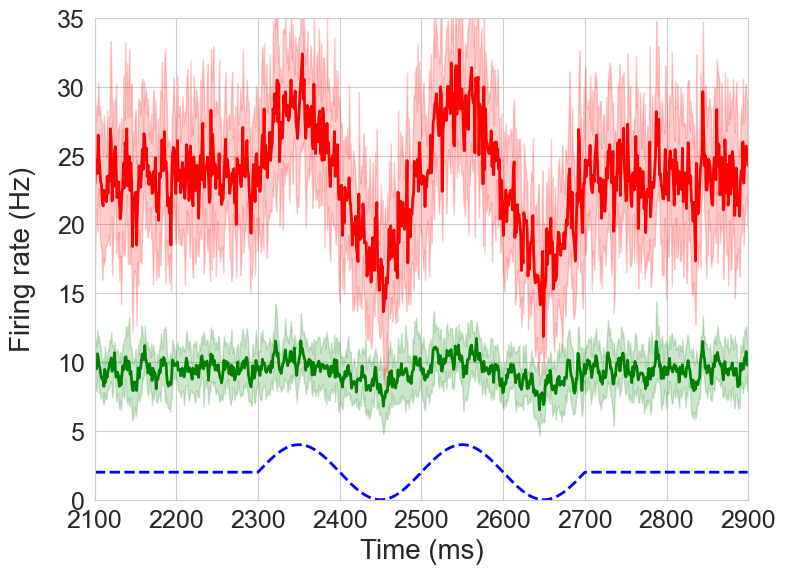

In [213]:
print("delta_EL = 5 mV (UD), period = 200 ms")

results = run_impulse_multiseed_two_cycle(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-75,
    EL_exc=-70,
    A=2,
    period=200,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse_two_cycle(
    results,
    period=200,
    t_center=2500,
    ylim=(0, 35),
    xlim=None
)

delta_EL = 5 mV (UD), period = 20 ms
[1/10] seed=0 | iter=13.75s | elapsed=13.8s | ETA=123.8s
[2/10] seed=1 | iter=13.27s | elapsed=27.0s | ETA=108.1s
[3/10] seed=2 | iter=14.35s | elapsed=41.4s | ETA=96.5s
[4/10] seed=3 | iter=12.43s | elapsed=53.8s | ETA=80.7s
[5/10] seed=4 | iter=15.00s | elapsed=68.8s | ETA=68.8s
[6/10] seed=5 | iter=23.41s | elapsed=92.2s | ETA=61.5s
[7/10] seed=6 | iter=13.98s | elapsed=106.2s | ETA=45.5s
[8/10] seed=7 | iter=14.27s | elapsed=120.5s | ETA=30.1s
[9/10] seed=8 | iter=13.05s | elapsed=133.5s | ETA=14.8s
[10/10] seed=9 | iter=14.10s | elapsed=147.6s | ETA=0.0s


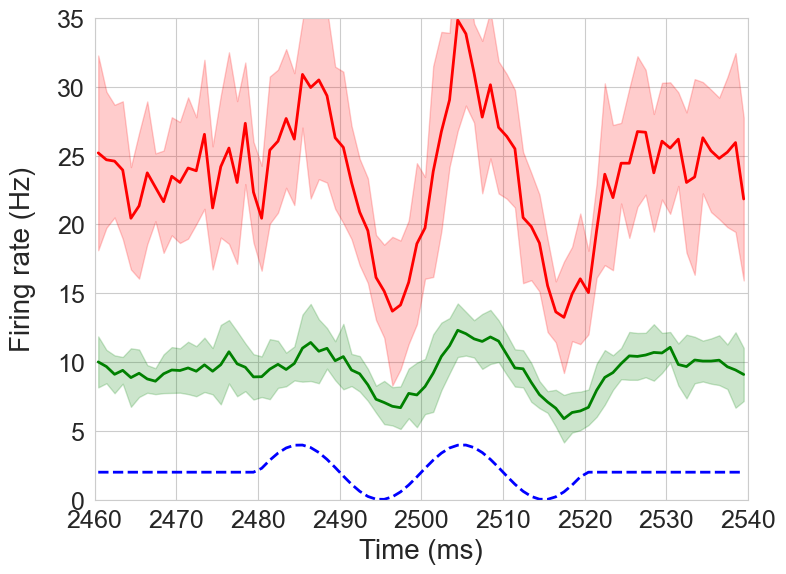

In [214]:
print("delta_EL = 5 mV (UD), period = 20 ms")

results = run_impulse_multiseed_two_cycle(
    n_seeds=10,
    b_val=0,
    rate=2,
    EL_inh=-75,
    EL_exc=-70,
    A=2,
    period=20,
    t_center=2500,
    binsize=1
)

plot_multiseed_impulse_two_cycle(
    results,
    period=20,
    t_center=2500,
    ylim=(0, 35),
    xlim=None
)

### Fig. 9
Hogkin Huxley simulations

Note: long simulation time (20 hours on mac with --n_workers = 3)

In [ ]:
import subprocess
from pathlib import Path
import os

PROJECT_ROOT = Path().resolve().parents[1]

env = os.environ.copy()
env["PYTHONPATH"] = str(PROJECT_ROOT / "async_responsiveness" / "scripts") + os.pathsep + env.get("PYTHONPATH", "")

cmd = [
    "python",
    "-m",
    "hh_network_simulations.hh_frequency_sweep_parallel_v2",
    "--workers", "3",
]

subprocess.run(cmd, cwd=PROJECT_ROOT, env=env)

In [243]:
# -----------------------------------------------------------------------
# Cell 1: Load and aggregate results
# -----------------------------------------------------------------------
import matplotlib.patches as mpatches
from matplotlib.ticker import LogLocator
from matplotlib.legend_handler import HandlerTuple

def aggregate_impulse_results_hh(impulse_results):
    df = pd.DataFrame(impulse_results)
    df["delta_EL"] = df["El_exc"] - df["EL_inh"]
    group_cols = ["El_exc", "EL_inh", "delta_EL", "frequency"]
    agg = (
        df
        .groupby(group_cols)
        .agg(
            amp_exc_mean=("amp_exc", "mean"),
            amp_exc_std=("amp_exc",  "std"),
            amp_inh_mean=("amp_inh", "mean"),
            amp_inh_std=("amp_inh",  "std"),
            phase_exc_mean=("phase_exc", "mean"),
            phase_exc_std=("phase_exc",  "std"),
            phase_inh_mean=("phase_inh", "mean"),
            phase_inh_std=("phase_inh",  "std"),
        )
        .reset_index()
    )
    return agg

# Load results

from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "async_responsiveness" / "data"

file_path = DATA_DIR / "impulse_results_hh_grid_final.pkl"

with open(file_path, "rb") as f:
    results = pickle.load(f)

data = aggregate_impulse_results_hh(results)

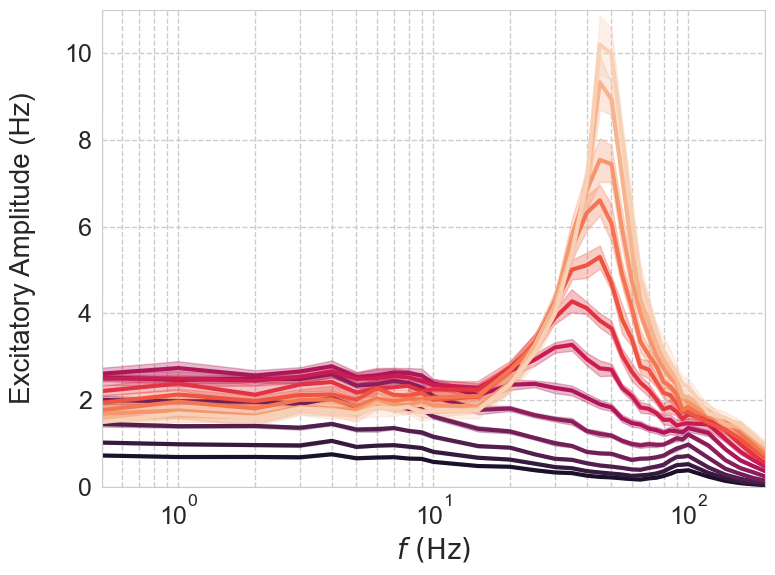

In [247]:
# Plot excitatory frequency-reesponse curves

def plot_hh_exc_responses(
    data,
    xrange=(0.5, 200),
    ymax=None,
):
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    delta_EL_unique = np.sort(data["delta_EL"].unique())
    El_exc_unique   = np.sort(data["El_exc"].unique())

    delta_colors = dict(zip(
        delta_EL_unique,
        sns.color_palette("rocket", n_colors=len(delta_EL_unique))
    ))

    for El_exc in El_exc_unique:
        for delta_EL in delta_EL_unique:
            subset = data[
                (data["El_exc"]   == El_exc) &
                (data["delta_EL"] == delta_EL)
            ].sort_values("frequency")

            if subset.empty:
                continue

            freq  = subset["frequency"]
            mean  = subset["amp_exc_mean"]
            std   = subset["amp_exc_std"]
            color = delta_colors[delta_EL]

            plt.fill_between(freq, mean - std, mean + std,
                             color=color, alpha=0.3)

            plt.plot(freq, mean,
                     color=color,
                     linestyle='-',
                     linewidth=3,
                     label=f"{delta_EL:.0f} mV")

    ax = plt.gca()
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(1, 10) * 0.1, numticks=10)
    )
    ax.grid(which="both", linestyle="--", linewidth=1)

    ax.set_xlabel(r"$f \text{ (Hz)}$", fontsize=20)
    ax.set_ylabel("Excitatory Amplitude (Hz)", fontsize=20, labelpad=20)
    ax.set_xlim(xrange)
    if ymax is not None:
        ax.set_ylim(0, ymax)

    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.tick_params(axis='both', which='minor', labelsize=18)

    plt.tight_layout()
    plt.show()


plot_hh_exc_responses(
    data,
    xrange=(0.5, 200),
    ymax=11,
)

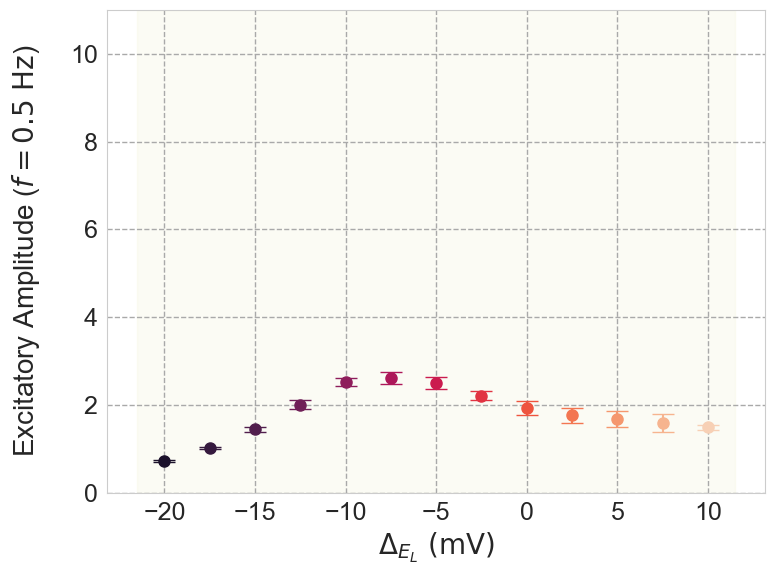

In [245]:
# Plot excitatory slow-input responses

def plot_hh_exc_response_snapshot(
    data,
    freq=0.5,
    ymax=11,
):
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    subset = data[data["frequency"] == freq]

    delta_EL_unique = np.sort(data["delta_EL"].unique())

    delta_colors = dict(zip(
        delta_EL_unique,
        sns.color_palette("rocket", n_colors=len(delta_EL_unique))
    ))

    for delta_EL in delta_EL_unique:
        sub = subset[subset["delta_EL"] == delta_EL]

        if sub.empty:
            continue

        y    = sub["amp_exc_mean"].iloc[0]
        yerr = sub["amp_exc_std"].iloc[0]
        color = delta_colors[delta_EL]

        plt.errorbar(
            delta_EL,
            y,
            yerr=yerr,
            fmt="o",
            color=color,
            markersize=8,
            ecolor=color,
            elinewidth=1.5,
            capsize=8,
        )

    ax = plt.gca()
    xmin, xmax = ax.get_xlim()

    ax.axvspan(xmin, xmax, color="beige", alpha=0.3, zorder=0)

    ax.grid(which="both", linestyle="--", color='darkgray', linewidth=1)
    ax.set_xlabel(r"$\Delta_{E_L} \text{ (mV)}$", fontsize=20)
    ax.set_ylabel(
        rf"Excitatory Amplitude ($f={freq} \text{{ Hz}}$)",
        fontsize=20, labelpad=20
    )
    ax.set_ylim(0, ymax)

    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.tick_params(axis='both', which='minor', labelsize=18)

    plt.tight_layout()
    plt.show()


plot_hh_exc_response_snapshot(
    data,
    freq=0.5,
    ymax=11,
)

## Fig. 10
State-dependent mean-field timescale $T=\tau_V$

$\nu_\text{drive}=2 \text{ Hz, } b=0 \text{ pA}$

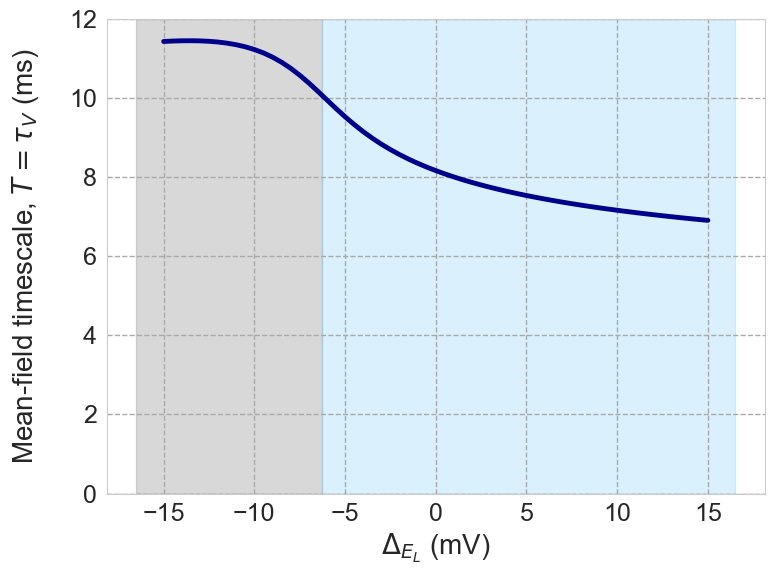

Mean-field timescale for changing $\Delta_{E_L}$ ($b=0$ pA, $\nu_{drive}=2$ Hz)


In [274]:
# Import eigen_df_r2b0_dense from pkl file
with open(f"../data/eigen_df_r2b0_dense.pkl", "rb") as f:
    eigen_df_r2b0_dense = pickle.load(f)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Colours
color_real = "gray"             # overdamped
color_complex = "lightskyblue"  # underdamped

# tolerance for equality checks
EQ_TOL = 1e-6

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
})

# ---------------------------------------------------
# Determine overdamped / underdamped boundary
# ---------------------------------------------------
imag_vals = eigen_df_r2b0_dense["Im_lambda1"].values
delta_vals = eigen_df_r2b0_dense["delta_EL"].values

idx_switch = next(
    i for i in range(len(imag_vals))
    if abs(imag_vals[i]) == 0
)

x_boundary = 0.5 * (delta_vals[idx_switch - 1] + delta_vals[idx_switch])

# ---------------------------------------------------
# Plot T_stationary vs delta_EL
# ---------------------------------------------------
ax.plot(
    eigen_df_r2b0_dense["delta_EL"],
    eigen_df_r2b0_dense["T_stationary"]*1000,
    color="darkblue",
    linewidth=3.5,
    zorder=3,
)

# Boundaries for shaded regions
xmin, xmax = ax.get_xlim()

# Background shading
ax.axvspan(xmin, x_boundary, color=color_real, alpha=0.3, zorder=0)
ax.axvspan(x_boundary, xmax, color=color_complex, alpha=0.3, zorder=0)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel(r'$\Delta_{E_L}$ (mV)', fontsize=20)
ax.set_ylabel(
    r"Mean-field timescale, $T=\tau_V$ (ms)",
    fontsize=20,
    labelpad=20,
)

ax.grid(which="both", linestyle="--", color='darkgray', linewidth=1)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(0, 12)
plt.tight_layout()
plt.show()

print(r"Mean-field timescale for changing $\Delta_{E_L}$ ($b=0$ pA, $\nu_{drive}=2$ Hz)")

$\nu_\text{drive}=4 \text{ Hz, } b=0 \text{ pA}$

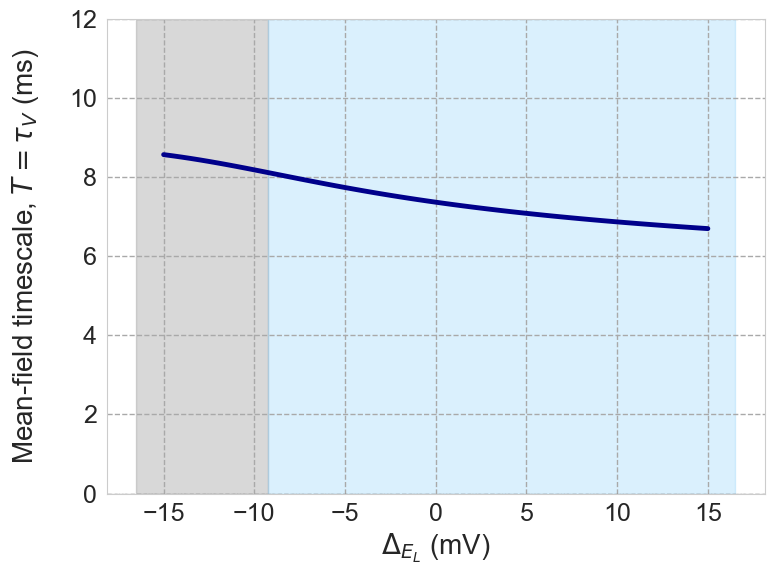

Mean-field timescale for changing $\Delta_{E_L}$ ($b=0$ pA, $\nu_{drive}=4$ Hz)


In [275]:
# Import eigen_df_r4b0_dense from pkl file
with open(f"../data/eigen_df_r4b0_dense.pkl", "rb") as f:
    eigen_df_r4b0_dense = pickle.load(f)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Colours=
color_real = "gray"             # overdamped
color_complex = "lightskyblue"  # underdamped

# tolerance for equality checks
EQ_TOL = 1e-6

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
})

# ---------------------------------------------------
# Determine overdamped / underdamped boundary
# ---------------------------------------------------
imag_vals = eigen_df_r4b0_dense["Im_lambda1"].values
delta_vals = eigen_df_r4b0_dense["delta_EL"].values

idx_switch = next(
    i for i in range(len(imag_vals))
    if abs(imag_vals[i]) == 0
)

x_boundary = 0.5 * (delta_vals[idx_switch - 1] + delta_vals[idx_switch])

# ---------------------------------------------------
# Plot T_stationary vs delta_EL
# ---------------------------------------------------
ax.plot(
    eigen_df_r4b0_dense["delta_EL"],
    eigen_df_r4b0_dense["T_stationary"]*1000,
    color="darkblue",
    linewidth=3.5,
    zorder=3,
)

# Boundaries for shaded regions
xmin, xmax = ax.get_xlim()

# Background shading
ax.axvspan(xmin, x_boundary, color=color_real, alpha=0.3, zorder=0)
ax.axvspan(x_boundary, xmax, color=color_complex, alpha=0.3, zorder=0)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel(r'$\Delta_{E_L}$ (mV)', fontsize=20)
ax.set_ylabel(
    r"Mean-field timescale, $T=\tau_V$ (ms)",
    fontsize=20,
    labelpad=20,
)

ax.grid(which="both", linestyle="--", color='darkgray', linewidth=1)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(0, 12)
plt.tight_layout()
plt.show()


print(r"Mean-field timescale for changing $\Delta_{E_L}$ ($b=0$ pA, $\nu_{drive}=4$ Hz)")

$\nu_\text{drive}=4 \text{ Hz, } b=60 \text{ pA}$

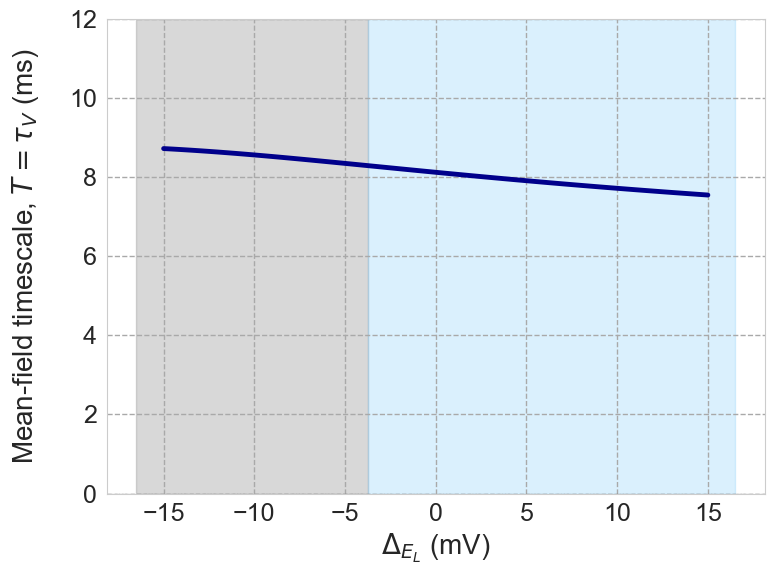

Mean-field timescale for changing $\Delta_{E_L}$ ($b=60$ pA, $\nu_{drive}=4$ Hz)


In [276]:
# Import eigen_df_r4b60_dense from pkl file
with open(f"../data/eigen_df_r4b60_dense.pkl", "rb") as f:
    eigen_df_r4b60_dense = pickle.load(f)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Colours
color_real = "gray"             # overdamped
color_complex = "lightskyblue"  # underdamped

# tolerance for equality checks
EQ_TOL = 1e-6

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
})

# ---------------------------------------------------
# Determine overdamped / underdamped boundary
# ---------------------------------------------------
imag_vals = eigen_df_r4b60_dense["Im_lambda1"].values
delta_vals = eigen_df_r4b60_dense["delta_EL"].values

idx_switch = next(
    i for i in range(len(imag_vals))
    if abs(imag_vals[i]) == 0
)

x_boundary = 0.5 * (delta_vals[idx_switch - 1] + delta_vals[idx_switch])

# ---------------------------------------------------
# Plot T_stationary vs delta_EL
# ---------------------------------------------------
ax.plot(
    eigen_df_r4b60_dense["delta_EL"],
    eigen_df_r4b60_dense["T_stationary"]*1000,
    color="darkblue",
    linewidth=3.5,
    zorder=3,
)

# Boundaries for shaded regions
xmin, xmax = ax.get_xlim()

# Background shading
ax.axvspan(xmin, x_boundary, color=color_real, alpha=0.3, zorder=0)
ax.axvspan(x_boundary, xmax, color=color_complex, alpha=0.3, zorder=0)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel(r'$\Delta_{E_L}$ (mV)', fontsize=20)
ax.set_ylabel(
    r"Mean-field timescale, $T=\tau_V$ (ms)",
    fontsize=20,
    labelpad=20,
)

ax.grid(which="both", linestyle="--", color='darkgray', linewidth=1)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(0, 12)
plt.tight_layout()
plt.show()


print(r"Mean-field timescale for changing $\Delta_{E_L}$ ($b=60$ pA, $\nu_{drive}=4$ Hz)")

## Fig. 11

In [286]:
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path().resolve().parents[1]

# Add the hh_single_cell_models directory to the Python path
hh_single_cell_models_path = PROJECT_ROOT / "async_responsiveness" / "scripts" / "hh_single_cell_models"
sys.path.append(str(hh_single_cell_models_path))

# Import the get_membrane_equation function from "cell_construct.py" in the "hh_single_cell_models" directory
from hh_single_cell_models.cell_construct import get_membrane_equation


In [287]:
# Functions to plot sample Vm traces for AdEx and HH networks

def plot_adex_trace_network_input(EL, DeltaT, b_val,
                                   nu_e, nu_i,
                                   tstop=3000, transient=500, show_ms=1000,
                                   DT=0.1,
                                   Qe=1.5, Qi=5.0, Tsyn_e=5.0, Tsyn_i=5.0,
                                   Ee=0., Ei=-80.,
                                   color='green', cell_name='AdEx',
                                   seed_val=12):

    start_scope()
    defaultclock.dt = DT * ms
    seed(seed_val)
    np.random.seed(seed_val)

    C = 200*pF; gL = 10*nS; tauw = 500*ms; a = 0*nS
    Vr = -65*mV

    eqs = f"""
    dvm/dt = (gL*(EL_var - vm) + gL*DeltaT_var*exp((vm - VT_var)/DeltaT_var)
              - GsynE*(vm - {Ee}*mV) - GsynI*(vm - {Ei}*mV)
              - w) / C : volt (unless refractory)
    dw/dt = (a*(vm - EL_var) - w) / tauw : amp
    dGsynE/dt = -GsynE / ({Tsyn_e}*ms) : siemens
    dGsynI/dt = -GsynI / ({Tsyn_i}*ms) : siemens
    EL_var     : volt
    VT_var     : volt
    DeltaT_var : volt
    """

    G = NeuronGroup(1, eqs,
                    threshold='vm > VT_var + 5*DeltaT_var',
                    reset='vm = Vr; w += b_val*pA',
                    refractory=5*ms,
                    method='heun')

    G.vm         = EL
    G.w          = 0 * pA
    G.GsynE      = 0 * nS
    G.GsynI      = 0 * nS
    G.EL_var     = EL
    G.VT_var     = -50 * mV
    G.DeltaT_var = DeltaT

    P_exc = PoissonGroup(1, rates=nu_e * Hz)
    P_inh = PoissonGroup(1, rates=nu_i * Hz)

    S_exc = Synapses(P_exc, G, on_pre='GsynE_post += Qe*nS')
    S_exc.connect()
    S_inh = Synapses(P_inh, G, on_pre='GsynI_post += Qi*nS')
    S_inh.connect()

    VM = StateMonitor(G, 'vm', record=True)
    SM = SpikeMonitor(G)

    run(tstop * ms)

    t  = VM.t / ms
    vm = VM.vm[0] / mV

    # Diagnostic
    spike_times = SM.t / ms
    spike_times_post = spike_times[spike_times > transient]
    rate_measured = len(spike_times_post) / ((tstop - transient) / 1000.)
    print(f"\n--- Diagnostic: {cell_name} ---")
    print(f"  nu_e = {nu_e:.1f} Hz, nu_i = {nu_i:.1f} Hz")
    print(f"  Qe = {Qe} nS, Qi = {Qi} nS")
    print(f"  EL  = {EL/mV:.1f} mV")
    print(f"  VT  = -50.0 mV (fixed)")
    print(f"  DeltaT = {DeltaT/mV:.1f} mV")
    print(f"  Measured rate (post-transient): {rate_measured:.2f} Hz")

    # Restrict to plot window
    mask = (t >= transient) & (t < transient + show_ms)
    t_plot  = t[mask] - transient
    vm_plot = vm[mask]

    spike_times_plot = spike_times[
        (spike_times >= transient) &
        (spike_times < transient + show_ms)
    ] - transient

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(t_plot, vm_plot, color=color, lw=1.5)

    for st in spike_times_plot:
        ax.axvline(st, color=color, lw=2, linestyle=':', alpha=0.6)

    ax.set_xlim(0, show_ms)
    ax.set_ylim(-85, 55)
    ax.set_xlabel('Time (ms)', fontsize=20)
    ax.set_ylabel('Vm (mV)', fontsize=20, labelpad=15)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', color='darkgray', linewidth=1)
    plt.tight_layout()

    plt.show()

    return t_plot, vm_plot


def plot_hh_trace_network_input(GNa_density, GK_density, VT,
                                 nu_e, nu_i,
                                 tstop=3000, transient=500, show_ms=500,
                                 DT=0.1,
                                 Qe=1.5, Qi=5.0, Tsyn_e=5.0, Tsyn_i=5.0,
                                 Ee=0., Ei=-80., membrane_size=200e-6,
                                 color='green', cell_name='HH',
                                 seed_val=12,
                                 figsize=(6, 2.5)):

    start_scope()
    defaultclock.dt = DT * ms
    seed(seed_val)
    np.random.seed(seed_val)

    params = {
        'name': cell_name,
        'N': 1,
        'Cm': 1.0e6 * membrane_size,
        'Gl': 0.05e6 * membrane_size,
        'GNa': GNa_density * 1e-3 * 1e9 * membrane_size,
        'GK':  GK_density  * 1e-3 * 1e9 * membrane_size,
        'GM':  0.,
        'El': -70.,
        'EK': -90.,
        'ENa': 50.,
        'VT': VT,
        'tau_max': 4000.,
    }

    synaptic_array = [
        {'name': 'e', 'Erev': Ee,  'Tsyn': Tsyn_e},
        {'name': 'i', 'Erev': Ei,  'Tsyn': Tsyn_i},
    ]

    neuron = get_membrane_equation(params, synaptic_array)
    neuron.VT = VT * mV
    neuron.El = -70 * mV
    neuron.V  = -65 * mV
    neuron.m  = 0.05
    neuron.h  = 0.60
    neuron.n  = 0.30
    neuron.p  = 0.0
    neuron.I0 = 0 * pA

    P_exc = PoissonGroup(1, rates=nu_e * Hz)
    P_inh = PoissonGroup(1, rates=nu_i * Hz)

    S_exc = Synapses(P_exc, neuron, on_pre='Ge_post += Qe*nS')
    S_exc.connect()
    S_inh = Synapses(P_inh, neuron, on_pre='Gi_post += Qi*nS')
    S_inh.connect()

    VM = StateMonitor(neuron, 'V', record=True)
    SM = SpikeMonitor(neuron)

    run(tstop * ms)

    t  = VM.t / ms
    vm = VM.V[0] / mV

    # Remove transient and restrict to show_ms
    mask = (t >= transient) & (t < transient + show_ms)
    t_plot  = t[mask] - transient
    vm_plot = vm[mask]

    spike_times = SM.t / ms
    spike_times_plot = spike_times[(spike_times >= transient) & 
                                    (spike_times < transient + show_ms)] - transient

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(t_plot, vm_plot, color=color, lw=1.5)

    for st in spike_times_plot:
        ax.axvline(st, color=color, lw=2, linestyle=':', alpha=0.75)
        
    ax.set_xlim(0, show_ms)
    ax.set_ylim(-85, 55)
    ax.set_xlabel('Time (ms)', fontsize=20)
    ax.set_ylabel('Vm (mV)', fontsize=20, labelpad=15)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', color='darkgray', linewidth=1)
    plt.tight_layout()

    plt.show()

    return t_plot, vm_plot


--- Diagnostic: AdEx_RS ---
  nu_e = 4643.9 Hz, nu_i = 2453.3 Hz
  Qe = 1.5 nS, Qi = 5.0 nS
  EL  = -70.0 mV
  VT  = -50.0 mV (fixed)
  DeltaT = 2.0 mV
  Measured rate (post-transient): 4.00 Hz


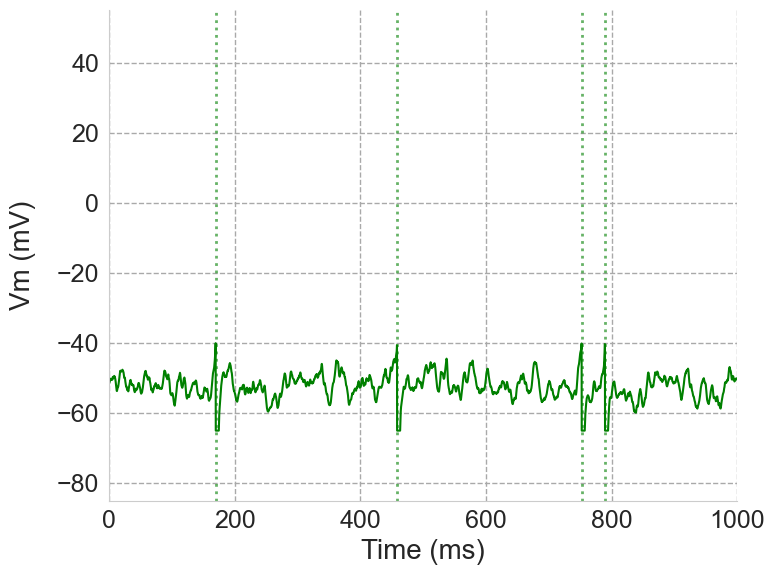

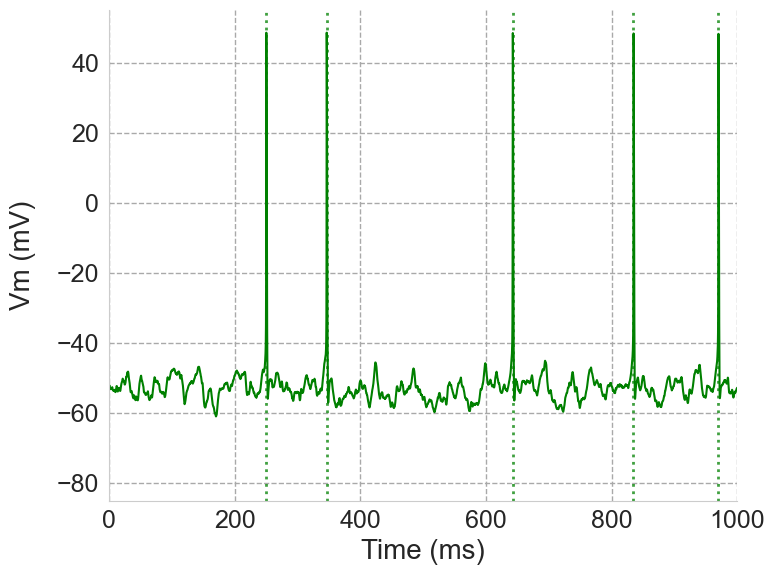


--- Diagnostic: AdEx_FS ---
  nu_e = 4643.9 Hz, nu_i = 2453.3 Hz
  Qe = 1.5 nS, Qi = 5.0 nS
  EL  = -70.0 mV
  VT  = -50.0 mV (fixed)
  DeltaT = 0.5 mV
  Measured rate (post-transient): 24.00 Hz


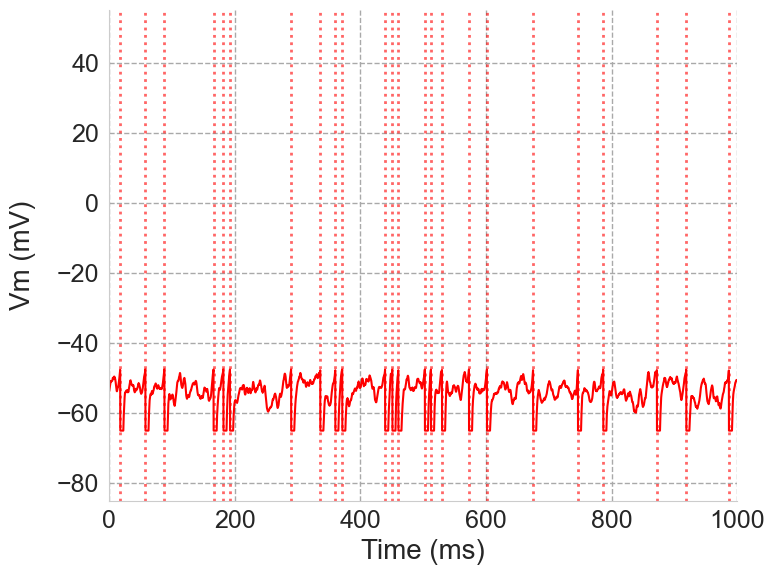

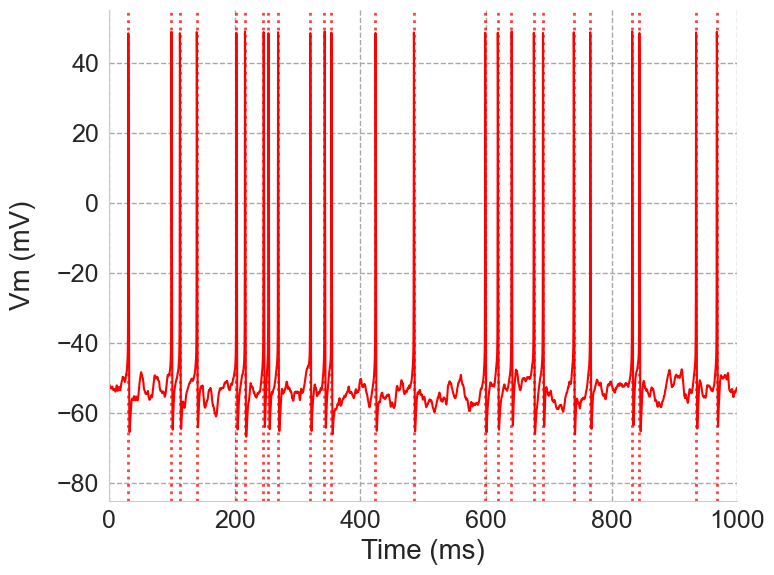

(array([0.000e+00, 1.000e-01, 2.000e-01, ..., 9.997e+02, 9.998e+02,
        9.999e+02], shape=(10000,)),
 array([-52.31229474, -52.17849408, -52.05402181, ..., -52.80062782,
        -52.77052007, -52.74411235], shape=(10000,)))

In [293]:
# -----------------------------------------------------------------------
# Run single-cell simulations for AdEx and HH under predicted synaptic bombardment at operating point (delta_EL = 0 mV, b=0 pA, nu_drive=4 Hz)
# -----------------------------------------------------------------------
average_exc_rate = 7.6097969966629595
average_inh_rate = 24.53349276974416
drive_rate = 4.0
seed_val = 10

nu_e = 400 * (average_exc_rate + drive_rate)
nu_i = 100 * average_inh_rate

# RS AdEx
plot_adex_trace_network_input(
    EL=-70*mV, DeltaT=2*mV, b_val=0,
    nu_e=nu_e, nu_i=nu_i,
    color='green', cell_name='AdEx_RS',
    tstop=2000, transient=1000,
    show_ms=1000, seed_val=seed_val
)

# RS HH
plot_hh_trace_network_input(
    GNa_density=90., GK_density=3., VT=-53.,
    nu_e=nu_e, nu_i=nu_i,
    color='green', cell_name='HH_RS',
    tstop=2000, transient=1000,
    show_ms=1000, seed_val=seed_val
)

# FS AdEx
plot_adex_trace_network_input(
    EL=-70*mV, DeltaT=0.5*mV, b_val=0,
    nu_e=nu_e, nu_i=nu_i,
    color='red', cell_name='AdEx_FS',
    tstop=2000, transient=1000,
    show_ms=1000, seed_val=seed_val
)

# FS HH
plot_hh_trace_network_input(
    GNa_density=110., GK_density=5., VT=-55.,
    nu_e=nu_e, nu_i=nu_i,
    color='red', cell_name='HH_FS',
    tstop=2000, transient=1000,
    show_ms=1000, seed_val=seed_val
)